[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GrEarl/microgpt-lesson/blob/main/Learn_the_Basics_of_Large_Language_Models_with_Karpathy%27s_MicroGPT_LLM%28%E5%A4%A7%E8%A6%8F%E6%A8%A1%E8%A8%80%E8%AA%9E%E3%83%A2%E3%83%87%E3%83%AB%29%E3%81%AE%E5%9F%BA%E6%9C%AC%E3%82%92%E4%BD%9C%E3%81%A3%E3%81%A6%E5%AD%A6%E3%81%BC%E3%81%86.ipynb)

# 0. はじめに - Introduction
このNotebookは，私たちが普段よく使うChatGPTやGoogle Gemini，Anthropic ClaudeなどのLLMの仕組みを，基礎となる数学知識を身につけながら学べる教材です。
> This Notebook is learning material designed to help you understand the mechanics of LLMs we use every day, such as ChatGPT, Google Gemini, and Anthropic Claude, while acquiring the foundational mathematical knowledge behind them.

[Karpathy氏のMicroGPT](https://gist.github.com/karpathy/8627fe009c40f57531cb18360106ce95)をベースに，基礎となる数学知識を含めたうえで数学1Aを履修した程度の高校生向けに再構成しています。
> Based on [Karpathy's MicroGPT](https://gist.github.com/karpathy/8627fe009c40f57531cb18360106ce95), this content has been restructured for high school students, incorporating the necessary foundational math.

指数・対数や微分，ベクトルのように数学II以降で習う内容も，必要な分だけこのNotebookの中でゼロから説明するので，事前に知らなくても大丈夫です。
> Topics you usually learn later, such as exponents, logarithms, derivatives, and vectors, are explained from scratch in this notebook, so you do not need to know them in advance.

また，専門用語以外は可能な限り，同じ意味の平易な英文を併記しています。
> In addition, except for technical terms, simple English equivalents with the same meaning are provided alongside the text wherever possible.

特にAI分野では，英語が中心となる言語です。
興味を持ってくれた皆さんが，自らの探求のなかで英語表現や専門用語に躓かないよう，予習も兼ねて付記していますので，ぜひ英語教材としても活用してください。
> Especially in the field of AI, English is the primary language.
To ensure that those of you who are interested do not stumble over English expressions and technical terms in your own explorations, these are included as a form of preparation, so please also make use of this as learning material for English.

ただし，Pythonの基本的な記法については記載していません。
> However, this document does not cover the basics of Python syntax.


---


## 0.1 GPTをまず動かしてみよう - Let's run a GPT first.

これから，このNotebookで学んで作成するGPTを実際にまず動かしてみましょう。
> Now, let's actually run the GPT that you will learn to build in this notebook first.

次のセルにあるコードは，これから皆さんが最終的に作成する架空の名前を作るGPTモデルを訓練して，推論させるコードです。
> The code in the next cell trains and runs inference on the GPT model for generating made-up names, which is what you will end up building.

まず，実行してみましょう。カップ麺が作れるくらいには時間がかかるよ。
> Right, let's give it a go. It'll take roughly the time it takes to kettle a Pot Noodle.

(Pot Noodleはイギリスの定番カップ麺，"kettle"は「やかんでお湯を沸かす」という意味のイギリスの口語だよ)



---

### [注釈]
 - LLM : 大規模言語モデル(Large Language Model)・それまでの文脈をもとに次に来るToken(文字や単語のかけら)を生成するためのモデル
 - GPT : 生成的事前学習済みトランスフォーマー(Generative Pre-trained Transformer)・Transformerという仕組みを使って，前のTokenから次のTokenを予測する言語モデルの一種
 - 訓練(Training) : あるAIモデルに対し，データセットに基づいて正しい出力を出せるように調整すること。事前学習(Pre-training)と事後学習(Post-Training)がある。
 - 推論(Inference) : AIモデルが入力に基づいて次の出力を予想すること。
 - 学習データ : [japanese-personal-name-dataset](https://github.com/shuheilocale/japanese-personal-name-dataset)(shuheilocale氏作成，MITライセンス)の女性名を使っています。

 > このNotebookで取り扱うMicroGPTは数千くらいしかパラメーターの無い小さなモデルだから"**Large**" Language Modelじゃないよ。ただ，ChatGPTなどと共通するGPTを搭載しているよ

In [1]:
"""
The most atomic way to train and run inference for a GPT in pure, dependency-free Python.
This file is the complete algorithm.
Everything else is just efficiency.

@karpathy

Translated & Adapted for Japanese Learners by GrEarl(X:@Iamwonderingif)
"""

import os       # os.path.exists: ファイルの有無判定に使う
import math     # math.log, math.exp: 対数(log)とeの累乗を計算するのに使う
import random   # random.seed, random.choices, random.gauss, random.shuffle: いずれもランダムに選ぶための疑似乱数(乱数のように見える数列を計算する関数)モジュール
random.seed(42) # Let there be order among chaos: 疑似乱数のシード値(最初の入力。以後は出力を次の入力に)を決めるよ。なぜ42かというと，"生命、宇宙、そして万物についての究極の疑問の答え"だから。詳しくは小説「銀河ヒッチハイクガイド」を読んでね

# 適当な文章のリストを学習データとして用意します。今回は日本人の女性名を用いるよ
if not os.path.exists('first_name_woman_org.csv'):
    import urllib.request
    names_url = 'https://raw.githubusercontent.com/shuheilocale/japanese-personal-name-dataset/main/japanese_personal_name_dataset/dataset/first_name_woman_org.csv'
    urllib.request.urlretrieve(names_url, 'first_name_woman_org.csv')
import csv
with open('first_name_woman_org.csv', encoding='utf-8') as f:
    docs = [row[0] for row in csv.reader(f) if row]  # 1列目(ひらがな)のみ使用するよ。これは，漢字を入れてしまうと使う文字数が爆発的に増えてしまうからだよ
random.shuffle(docs)
print(f"学習データの個数: {len(docs)}")

# Tokenizer: 文字列をコンピューターの扱える数字(Token)に変換できるように，文字列と数字の対応を割り当てる部分だよ
uchars = sorted(set(''.join(docs))) # データセット内に登場する文字に，0～総個数-1の数字(Token)を割り当てるよ
BOS = len(uchars) # Beginning of Sequence (BOS) token: 生成の開始箇所をLLMに伝えるための特殊なTokenも割り当てるよ。普通はEnd of Sequence (EOS)も使うけど，今回は全部BOSでやるよ
vocab_size = len(uchars) + 1 # 割り当てたTokenの総数だよ。+1はBOSの分で，このtokenの大きさが語彙(Vocabulary)サイズとなるよ
print(f"語彙の大きさ: {vocab_size}")

# 計算グラフというものを使って，連鎖律(高校数学で出てくる合成関数の微分公式をベースにしてます)を再帰的に適用することで，面倒な微分を自動化するものを用意するおまじないだよ
# ここは難しいので実際に手を動かすフェーズでも飛ばしてもいいよ
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads') # メモリの使用量を最適化してくれるPythonの機能を使うよ

    def __init__(self, data, children=(), local_grads=()):
        self.data = data                # 順伝播(Forward Pass)の計算中に算出されるこのノードのスカラー値
        self.grad = 0                   # 逆伝播(Backward Pass)で算出される，このノードに関する損失(loss)の微分値
        self._children = children       # 計算グラフにおける，このノードの子ノード
        self._local_grads = local_grads # 子ノードに関する，このノードの局所的な微分

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad

# モデルの知識を入れるための，パラメーターを定義するよ
n_layer = 1     # Transformerのニューラルネットワークの深さ(レイヤー数)
n_embd = 16     # ニューラルネットワークの幅(埋め込み次元のこと)
block_size = max(len(doc) for doc in docs) + 1 # Attention Windowの最長コンテクスト長(要は扱える文章の長さ)。データセットで一番長い名前の文字数に，先頭に来るBOSの分の1文字を足した数にするよ(今回は5+1=6)
n_head = 4      # Attention Headの数。文字列のどの部分に着目するかを並列で計算させるよ。ただ，これは常に各ヘッドがどれに注目するかが決まってるわけじゃないよ
head_dim = n_embd // n_head # 各Attention Headが扱うベクトルの次元数
matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
state_dict = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd), 'lm_head': matrix(vocab_size, n_embd)}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)
params = [p for mat in state_dict.values() for row in mat for p in row] # パラメーターを1個のリストにまとめるだけ
print(f"パラメーター数: {len(params)}")

# モデルのアーキテクチャ(構造)を決めるよ。TokenとParameterから，次に来る文字のスコアを表すLogitsを計算するよ。これはSoftmax(複数のスコアを，すべて足すと1になる確率に変換する関数)の処理で次に来る確率に変換されるよ。
# GPT-2ベースだよ。ただいくつかの変更があるけど，些細なので気にしなくていいよ: layernorm -> rmsnorm, no biases, GeLU -> ReLU
def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]

def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

def gpt(token_id, pos_id, keys, values):
    tok_emb = state_dict['wte'][token_id] # Token埋め込み
    pos_emb = state_dict['wpe'][pos_id] # 位置埋め込み
    x = [t + p for t, p in zip(tok_emb, pos_emb)] # Token埋め込みと位置埋め込みを足し合わせるよ(横につなげるんじゃなくて，同じ位置の数どうしを足し算するよ)
    x = rmsnorm(x) # 値の大きさを整えるよ

    for li in range(n_layer):
        # 1) Multi-head Attention block
        x_residual = x # Residual Connection(残差接続)のために入力を取っておくよ。あとで出力に直接足すことで，元の情報を別の経路で残しながら変換できるよ
        x = rmsnorm(x)
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        keys[li].append(k)
        values[li].append(v)
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim
            q_h = q[hs:hs+head_dim]
            k_h = [ki[hs:hs+head_dim] for ki in keys[li]]
            v_h = [vi[hs:hs+head_dim] for vi in values[li]]
            attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5 for t in range(len(k_h))]
            attn_weights = softmax(attn_logits)
            head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h))) for j in range(head_dim)]
            x_attn.extend(head_out)
        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_residual)]
        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x]
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_residual)]

    logits = linear(x, state_dict['lm_head'])
    return logits

# Let there be Adam, the blessed optimizer and its buffers: 創世記ネタ。Adamは，勾配(どちらに動かせば損失が減るか)をもとに，パラメーターをどれだけ動かすかを決める方法だよ。ここでは1回に動かす大きさの基準(学習率)などを決めているよ
learning_rate, beta1, beta2, eps_adam = 0.01, 0.85, 0.99, 1e-8
m = [0.0] * len(params) # 勾配の移動平均を記録するバッファー(1次モーメント)
v = [0.0] * len(params) # 勾配の2乗の移動平均を記録するバッファー(2次モーメント)

# 順番に繰り返し学習する部分
num_steps = 1000 # 学習回数。1回につき1個の名前を使うので，シャッフルした3294個のうち最初の1000個を1回ずつ見ることになるよ
loss_history = [] # 毎回の損失を記録するよ。名前1個だけの損失はばらつきが大きいから，直近の平均も見るよ
for step in range(num_steps):

    # まず，データセットから1つデータを取り出して，Token化した後，前後にBOS Tokenをくっつけるよ
    doc = docs[step % len(docs)]
    tokens = [BOS] + [uchars.index(ch) for ch in doc] + [BOS]
    n = min(block_size, len(tokens) - 1)

    # モデルにToken列から一個づつTokenを入れて，モデルの予想からどれくらいずれたかみるよ。これを損失(loss)といって，これが出るまでの計算グラフを作るよ
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    losses = []
    for pos_id in range(n):
        token_id, target_id = tokens[pos_id], tokens[pos_id + 1]
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax(logits)
        loss_t = -probs[target_id].log()
        losses.append(loss_t)
    loss = (1 / n) * sum(losses) # 最終的にどれくらい損失が出たか平均するよ。低いと嬉しいな

    loss.backward() # 損失を逆伝播するよ。これで，全体のパラメータに対してどれくらい勾配を与えるかを計算するよ

    # さっき定義した，旧約聖書式Optimizerをアップデートするよ。対応する勾配に基づいて，モデルのパラメーターを更新することで，望ましい出力に近づけるんだ
    lr_t = learning_rate * (1 - step / num_steps) # 学習率を線形に減らすよ。なんでかっていうと，下げていかないと少しの誤差で大きく変え続けてしまって，いつまでたっても理想的な動きを飛び超えてしまうからだね
    for i, p in enumerate(params):
        m[i] = beta1 * m[i] + (1 - beta1) * p.grad
        v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2
        m_hat = m[i] / (1 - beta1 ** (step + 1))
        v_hat = v[i] / (1 - beta2 ** (step + 1))
        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
        p.grad = 0

    loss_history.append(loss.data)
    recent = loss_history[-50:]
    print(f"step {step+1:4d} / {num_steps:4d} | loss {loss.data:.4f} | 直近50回の平均 {sum(recent) / len(recent):.4f}", end='\r')

# 実際にモデルを動かして推論するよ。うまくいったら言葉を紡いでくれるはず
temperature = 0.5 # モデルがどれだけ自由に言葉を選ぶか決めれるよ。0に限りなく近いと必ず同じ選び方をして，1だと確率分布に忠実に選ぶよ。1を超えると無秩序になっていくよ。ただし0を入れると0の割り算をしちゃうから入れないでね
docs_set = set(docs) # 作った名前が学習データにあるかを調べるための集合だよ
print("\n--- 推論 (モデルが作った名前) ---")
for sample_idx in range(20):
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax([l / temperature for l in logits])
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
        if token_id == BOS:
            break
        sample.append(uchars[token_id])
    name = ''.join(sample)
    note = '学習データにある名前' if name in docs_set else '新しい名前！'
    print(f"sample {sample_idx+1:2d}: {name} ({note})")

学習データの個数: 3294
語彙の大きさ: 72
パラメーター数: 5472
step 1000 / 1000 | loss 3.3383 | 直近50回の平均 2.7348
--- 推論 (モデルが作った名前) ---
sample  1: あん (学習データにある名前)
sample  2: あいな (学習データにある名前)
sample  3: いとみ (学習データにある名前)
sample  4: あいさ (学習データにある名前)
sample  5: かづ (学習データにある名前)
sample  6: いょの (新しい名前！)
sample  7: かずの (学習データにある名前)
sample  8: たづき (新しい名前！)
sample  9: こゆな (新しい名前！)
sample 10: みさ (学習データにある名前)
sample 11: しえな (学習データにある名前)
sample 12: おの (新しい名前！)
sample 13: かほこ (学習データにある名前)
sample 14: あゆ (学習データにある名前)
sample 15: きな (学習データにある名前)
sample 16: きみは (新しい名前！)
sample 17: りい (学習データにある名前)
sample 18: るう (新しい名前！)
sample 19: あや (学習データにある名前)
sample 20: ふゆこ (学習データにある名前)


## 0.2 何が起きたのか？ - What just happened?

おめでとう。これで皆さんはML(Machine Learning: 機械学習)のアマチュア研究者の仲間入りですね。
> Congratulations. You are now officially part of the community of amateur machine learning researchers.

あなたは今自分のGPTモデルをゼロから訓練して，推論させました！
> You have just trained your very own GPT model from scratch and run inference with it.

出力をよく見ると，「学習データにある名前」と「新しい名前！」が混ざっていますね。
モデルは学習データをそのまま覚えて出すこともあれば，学んだパターンを組み合わせて，見たことのない名前を作ることもあります。
> If you look closely at the output, you will see a mix of "names in the training data" and "new names".
Sometimes the model simply repeats what it memorized, and sometimes it combines the patterns it learned to create names it has never seen.

また，最後の行の`loss`は名前1個だけの値なので，毎回大きくばらつきます。学習の進み具合は「直近50回の平均」のほうを見ましょう。
> Also, the `loss` on the last line is the value for just one name, so it changes a lot each time. To see how well the training is going, look at the "average of the last 50 steps" instead.

今回使ったモデルのパラメータ数はわずか数千個です。
ChatGPTなどの実際のLLMとは比べものにならないほど小さいため，このモデル自体はLarge Language Modelではありません。
> The model you used this time has only a few thousand parameters.
It is incomparable in size to actual LLMs like ChatGPT, so this model itself is not a large language model.

しかし，ここで使われている
> However, concepts used here such as:

- Tokenization
- Embedding
- Neural Network
- Attention
- Softmax
- Loss
- Backpropagation
- Optimization
- Inference

といった考え方は，現代のLLMにつながる基本的な仕組みです。
> are the fundamental mechanisms that lead to modern LLMs.

今は，上のコードを理解できなくてもまったく問題ありません。
> For now, it is completely fine if you do not understand the code above.

これからこの約200行のプログラムを少しずつ分解しながら，その裏側にあるLLM・GPTの仕組みと数学を学んでいきます。
> From here, we will break down this roughly 200-line program little by little, learning the mechanics and mathematics of LLMs and GPT that lie behind it.

そして最後には，
> And by the end,

「なぜこのコードから『こゆな』や『たづき』のような，学習データにない名前が生成されたのか」

「私たちが普段使うAIがどう動いていて，どう入力すべきなのか」

「なぜAIはもっともらしい間違い(ハルシネーション)を出力するのか」

を，自分の言葉で説明できるようになることを目指します。
> Our goal is for you to be able to explain these questions in your own words.

## 0.3 このNotebookの進め方 - How to use this Notebook

ここからは，0.1のプログラムを部品ごとに分解して，1章ずつ作っていきます。
各章は「なぜそれが必要か」→「必要な数学」→「実装」の順に進みます。
> From here, we will take the program from 0.1 apart and build it piece by piece, one chapter at a time.
Each chapter goes in this order: "why we need it" → "the math we need" → "implementation".

### 目次 - Contents

| 章 | 作るもの | 使う数学 |
|---|---|---|
| 第1章 | 文字を数字に: Tokenizer | 集合，対応 |
| 第2章 | 数えて名前を作る: bigramモデル | 確率，条件付き確率 |
| 第3章 | どれくらい外れた？: 損失とsoftmax | 指数・対数 |
| 第4章 | lossを小さくする: 勾配降下法 | 二次関数，微分 |
| 第5章 | 微分を自動で: 計算グラフと連鎖律 ★ | 合成関数 |
| 第6章 | 文字をベクトルに: 埋め込みと線形変換 | ベクトル，内積，三角比 |
| 第7章 | ニューラルネットワーク: MLPとReLU | 関数とグラフ |
| 第8章 | 前の文字に注目する: Attention | 内積，加重平均 |
| 第9章 | 学習を安定させる: RMSNormと残差接続 | 平均，分散，標準偏差 |
| 第10章 | 賢い下り方: Adam | 移動平均 |
| 第11章 | 全部組み立てる: MicroGPTの完成 | ここまでの全部 |
| 付録 | 用語集・公式まとめ・参考資料 | |

数学IIや数学Cで習う内容(指数・対数，微分，ベクトル)は，数学Iと数学Aの知識から出発して，必要な分だけ説明します。事前に知らなくても大丈夫です。
> Topics from Math II and Math C (exponents, logarithms, derivatives, vectors) are explained from what you know in Math I and Math A, only as much as we need, so you do not need to know them in advance.

### 記号の意味 - What the marks mean

- **[スライダー]**: 自分で値を動かして，結果がどう変わるかを確かめられるセルです。数式を見るだけでなく，ぜひ動かしてみてください。
- **[アニメーション]**: 動きで概念を説明する動画です。動画はあらかじめ保存されているので，実行しなくても見られます。
- **★**: 少し難しい節です。最初は飛ばして先に進んでも大丈夫です。
> - **[Slider]**: A cell where you can move values yourself and see how the result changes. Please try moving them, not just reading the formulas.
> - **[Animation]**: A video that explains an idea with movement. The videos are already saved, so you can watch them without running anything.
> - **★**: A harder section. It is fine to skip it at first.

### セルの実行について - About running cells

1. まず下の「共通準備」セルを実行してください。途中の章から始めるときも，このセルだけは必ず先に実行します。
2. あとは上から順番に実行していきましょう。学習(訓練)をするセルには，かかる時間の目安を書いてあります。
3. [アニメーション] のセルを実行すると，動画を作り直します。そのためには「アニメーションの準備」セルを先に実行しておく必要があります(準備なしで実行すると，保存されていた動画が消えてしまいます。そのときはNotebookを開き直してください)。
> 1. First, run the "common setup" cell below. Even when you start from a later chapter, always run this cell first.
> 2. Then run the cells in order from top to bottom. Cells that train a model show a rough estimate of how long they take.
> 3. Running an [Animation] cell re-creates the video. To do that, run the "animation setup" cell first. (If you run it without setup, the saved video disappears. In that case, reopen the Notebook.)

> グラフや動画を描くためのコードは，Colabでは折りたたんで隠してあります。中身が気になる人は，セルのタイトルをダブルクリックすると見られます。

In [2]:
#@title 共通準備(最初に必ず実行してね){ display-mode: "form" }
# このNotebookのどこから始めても必要になる道具を，まとめて用意するセルだよ
import os, math, random, csv, urllib.request
import matplotlib.pyplot as plt
from matplotlib import font_manager
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, Video

# --- 学習データ: 0.1と同じ手順で読み込んで，同じ順番にシャッフルするよ ---
if not os.path.exists('first_name_woman_org.csv'):
    urllib.request.urlretrieve('https://raw.githubusercontent.com/shuheilocale/japanese-personal-name-dataset/main/japanese_personal_name_dataset/dataset/first_name_woman_org.csv', 'first_name_woman_org.csv')
with open('first_name_woman_org.csv', encoding='utf-8') as f:
    docs = [row[0] for row in csv.reader(f) if row]
random.seed(42)
random.shuffle(docs)
uchars = sorted(set(''.join(docs)))
BOS = len(uchars)
vocab_size = len(uchars) + 1
def tok_str(i): return 'BOS' if i == BOS else uchars[i]  # Tokenの番号を表示用の文字に戻すよ

# --- グラフで日本語を表示するためのフォントと洗練されたスタイル ---
FONT_URL = 'https://github.com/google/fonts/raw/main/ofl/ibmplexsansjp/IBMPlexSansJP-Regular.ttf'
FONT_PATH = 'IBMPlexSansJP-Regular.ttf'
def font_file():
    if not os.path.exists(FONT_PATH):
        urllib.request.urlretrieve(FONT_URL, FONT_PATH)
    return os.path.abspath(FONT_PATH)
def _setup_font():
    try:
        font_manager.fontManager.addfont(font_file())   # 同梱フォントを使うよ(環境差で文字化けしないように)
        return font_manager.FontProperties(fname=font_file()).get_name()
    except Exception:
        pass
    have = {f.name for f in font_manager.fontManager.ttflist}
    for name in ['IBM Plex Sans JP', 'BIZ UDPGothic', 'Noto Sans CJK JP', 'Noto Sans JP', 'Yu Gothic', 'Meiryo', 'Hiragino Sans']:
        if name in have:
            return name
    return 'sans-serif'

# 読みやすく洗練されたプロット用テーマ設定
plt.rcParams.update({
    'font.family': _setup_font(),
    'axes.unicode_minus': False,
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#cbd5e1',
    'axes.linewidth': 1.0,
    'axes.grid': True,
    'grid.color': '#f1f5f9',
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.color': '#475569',
    'ytick.color': '#475569',
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlepad': 10,
})

# --- 0.1で使った道具(各章で1つずつ作り直していくよ) ---
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads')
    def __init__(self, data, children=(), local_grads=()):
        self.data = data
        self.grad = 0
        self._children = children
        self._local_grads = local_grads
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))
    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1
    def backward(self):
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad

def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]

def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

# --- [アニメーション] を作り直すための道具 ---
def show_anim(make_scene):
    try:
        import manim as mn, manimpango
    except ImportError:
        print('このアニメーションを作り直すには，0.3の「アニメーションの準備」セルを先に実行してね。')
        return
    manimpango.register_font(font_file())
    fonts = set(manimpango.list_fonts())
    font = next((f for f in ['IBM Plex Sans JP', 'BIZ UDPGothic', 'Noto Sans CJK JP', 'Noto Sans JP', 'Yu Gothic'] if f in fonts), '')
    T = lambda s, **k: mn.Text(s, font=font, **k)
    with mn.tempconfig({'quality': 'low_quality', 'verbosity': 'WARNING', 'disable_caching': True,
                        'progress_bar': 'none', 'media_dir': 'media'}):
        scene = make_scene(mn, T)()
        scene.render()
        path = str(scene.renderer.file_writer.movie_file_path)
    display(Video(path, embed=True, width=640, html_attributes='controls loop autoplay muted playsinline'))

print(f'準備完了！ 学習データ {len(docs)}個 / 語彙の大きさ {vocab_size}')

準備完了！ 学習データ 3294個 / 語彙の大きさ 72


In [3]:
#@title アニメーションの準備(アニメーションを自分で作り直したい人だけ・2〜3分かかるよ){ display-mode: "form" }
import sys, subprocess, importlib.util
if importlib.util.find_spec('manim') is None:
    if 'google.colab' in sys.modules:
        subprocess.run('apt-get -qq update && apt-get -qq install -y libpango1.0-dev libcairo2-dev ffmpeg > /dev/null', shell=True, check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'manim'], check=True)
import manim
print(f'manim {manim.__version__} の準備ができたよ')

manim 0.19.0 の準備ができたよ


---
# 第1章 文字を数字に: Tokenizer - Chapter 1: From characters to numbers

0.1のプログラムは，最初に「語彙の大きさ: 72」と表示しました。
この章では，この72という数が何なのか，そしてなぜ文字を数字に直す必要があるのかを学びます。
> The program in 0.1 first printed "vocabulary size: 72".
In this chapter, we will learn what this number 72 means and why we need to turn characters into numbers.

**この章で使う数学**: 集合(数学I「集合と命題」)，対応
> **Math in this chapter**: sets (Math I), correspondence (mapping)

## 1.1 コンピューターは数しか扱えない - Computers can only handle numbers

コンピューターの中では，文字も画像も音も，すべて数として扱われています。
実は文字には，世界共通の番号(Unicode)がすでに決められています。確かめてみましょう。
> Inside a computer, text, images and sound are all handled as numbers.
In fact, every character already has a worldwide number called Unicode. Let's check it.

In [4]:
for ch in 'さくら':
    print(ch, '→', ord(ch))  # ord(): 文字のUnicode番号(コードポイント)を調べる関数だよ

さ → 12373
く → 12367
ら → 12425


「さ」は12373番のようです。でも，Unicodeには約15万もの文字が登録されています。
私たちの学習データに出てくる文字はそのうちのごく一部なので，**実際に出てくる文字だけに0から順に番号を付け直す**ことにします。
この「文字 → 番号」の変換をする仕組みを **Tokenizer(トークナイザー)** と呼び，変換された番号を **Token(トークン)** と呼びます。
> "さ" is number 12373. But Unicode has about 150,000 characters.
Only a tiny part of them appear in our training data, so **we give new numbers, starting from 0, only to the characters that actually appear**.
The system that does this "character → number" conversion is called a **Tokenizer**, and the resulting numbers are called **Tokens**.

## 1.2 集合: 出てくる文字の集まり - Sets: the collection of characters that appear

数学Iで学ぶ **集合** とは，「ものの集まり」のことです。集合に入っている1つ1つのものを **要素** といいます。
集合には，次の2つの大事な性質があります。
> A **set** in Math I is "a collection of things". Each thing in a set is called an **element**.
Sets have two important properties:

1. 同じ要素は1回しか数えない(重複しない)
2. 要素の順番は関係ない
> 1. The same element is counted only once (no duplicates).
> 2. The order of elements does not matter.

集合 $A$ の要素の個数を $n(A)$ と書きます。Pythonにも `set` という集合があります。
> The number of elements of a set $A$ is written $n(A)$. Python also has sets, called `set`.

In [5]:
A = set('さくら')
B = set('さつき')
print('A =', A, ' n(A) =', len(A))
print('B =', B, ' n(B) =', len(B))
print('A ∪ B (和集合) =', A | B)   # どちらかに入っている文字だよ
print('A ∩ B (共通部分) =', A & B)  # 両方に入っている文字だよ
print("set('ももこ') =", set('ももこ'))  # 「も」は1回しか入らないよ

A = {'さ', 'ら', 'く'}  n(A) = 3
B = {'さ', 'き', 'つ'}  n(B) = 3
A ∪ B (和集合) = {'つ', 'き', 'ら', 'く', 'さ'}
A ∩ B (共通部分) = {'さ'}
set('ももこ') = {'も', 'こ'}


学習データのすべての名前をつなげて集合にすれば，「データに出てくる文字の集合」が作れます。
最後に `sorted()` で並べておくと，毎回同じ順番になって便利です(ひらがなはおおよそ五十音順に並びます)。
> If we join all the names in the training data and make a set, we get "the set of characters that appear in the data".
We sort it with `sorted()` so the order is always the same (hiragana comes out roughly in Japanese alphabetical order).

In [6]:
uchars = sorted(set(''.join(docs)))
print('出てくる文字の数 n(U) =', len(uchars))
print(''.join(uchars))

出てくる文字の数 n(U) = 71
あいうぇえおかがきぎくぐけげこごさざしじすずせぜそぞただちっつづてでとどなにぬねのはばひびふぶへべほぼぽまみむめもゃやゅゆょよらりるれろわをん


## 1.3 対応: 文字 ⇔ 番号 - Correspondence: character ⇔ number

次に，集合の要素1つ1つに番号を割り当てます。
「あ」→ 0，「い」→ 1，… のように，**1つの文字に1つの番号**，しかも **違う文字には違う番号** が対応するようにします。
このような対応を **1対1の対応** といいます。1対1なので，番号から文字へ逆向きに戻すこともできます。
> Next, we give a number to each element of the set.
Like "あ" → 0, "い" → 1, ..., **one character gets one number**, and **different characters get different numbers**.
This is called a **one-to-one correspondence**. Because it is one-to-one, we can also go back from numbers to characters.

- 文字 → 番号: **encode(エンコード)**
- 番号 → 文字: **decode(デコード)**
> - Character to number: **encode**
> - Number to character: **decode**

In [7]:
stoi = {ch: i for i, ch in enumerate(uchars)}  # string to integer: 文字 → 番号の辞書だよ
itos = {i: ch for i, ch in enumerate(uchars)}  # integer to string: 番号 → 文字の辞書だよ

def encode(s):
    return [stoi[ch] for ch in s]

def decode(ids):
    return ''.join(itos[i] for i in ids)

print('「さくら」をencode:', encode('さくら'))
print('元に戻すdecode:', decode(encode('さくら')))

「さくら」をencode: [16, 10, 63]
元に戻すdecode: さくら


### [アニメーション] 文字が番号に変わる - [Animation] Characters become numbers

In [8]:
#@title アニメーション: encode と decode { display-mode: "form" }
def make_scene(mn, T):
    class TokenMap(mn.Scene):
        def construct(self):
            title = T('Tokenizer: 文字 ⇔ 番号', font_size=36).to_edge(mn.UP)
            self.play(mn.Write(title))
            word = ['BOS'] + list('さくら') + ['BOS']
            ids = [BOS] + [uchars.index(c) for c in 'さくら'] + [BOS]
            top = mn.VGroup(*[mn.VGroup(mn.RoundedRectangle(width=1.3, height=1, corner_radius=0.15, color=mn.BLUE), T(w, font_size=30 if w == 'BOS' else 40)) for w in word]).arrange(mn.RIGHT, buff=0.4).shift(mn.UP * 1.2)
            for g in top: g[1].move_to(g[0])
            bottom = mn.VGroup(*[mn.VGroup(mn.RoundedRectangle(width=1.3, height=1, corner_radius=0.15, color=mn.YELLOW), T(str(i), font_size=36)) for i in ids]).arrange(mn.RIGHT, buff=0.4).shift(mn.DOWN * 1.4)
            for g in bottom: g[1].move_to(g[0])
            enc = T('encode', font_size=28, color=mn.BLUE).next_to(top, mn.LEFT).shift(mn.DOWN * 1.3)
            self.play(mn.LaggedStart(*[mn.FadeIn(g, shift=mn.DOWN * 0.3) for g in top], lag_ratio=0.2))
            self.play(mn.FadeIn(enc))
            arrows = []
            for a, b in zip(top, bottom):
                arr = mn.Arrow(a.get_bottom(), b.get_top(), buff=0.1, color=mn.GRAY)
                arrows.append(arr)
                self.play(mn.GrowArrow(arr), mn.FadeIn(b, shift=mn.DOWN * 0.3), run_time=0.5)
            note = T('BOS は「名前の始まり・終わり」の目印だよ', font_size=26).to_edge(mn.DOWN)
            self.play(mn.Indicate(top[0]), mn.Indicate(top[-1]), mn.Write(note))
            self.wait(0.5)
            dec = T('decode', font_size=28, color=mn.YELLOW).move_to(enc)
            self.play(*[mn.Rotate(a, angle=mn.PI) for a in arrows], mn.Transform(enc, dec))
            self.play(*[mn.Indicate(g) for g in top[1:-1]])
            self.wait(1)
    return TokenMap

show_anim(make_scene)

## 1.4 特別なToken「BOS」 - The special token "BOS"

モデルに名前を作らせるには，「ここから名前が始まるよ」「ここで名前が終わるよ」という目印も必要です。
そこで，どの文字とも違う特別なTokenを1つ追加します。これが **BOS(Beginning of Sequence)** です。
番号は，文字の番号の次(71番)を使います。だから語彙の大きさは $71 + 1 = 72$ になるのです。
> To let the model make names, we also need marks that say "a name starts here" and "a name ends here".
So we add one special token that is different from every character. This is **BOS (Beginning of Sequence)**.
It uses the number right after the characters (71). That is why the vocabulary size is $71 + 1 = 72$.

名前は，前後をBOSではさんだToken列にして使います。
> Each name is turned into a token sequence with BOS on both ends.

In [9]:
BOS = len(uchars)
vocab_size = len(uchars) + 1
print('BOS =', BOS, ' 語彙の大きさ =', vocab_size)

def tokenize(name):
    return [BOS] + encode(name) + [BOS]

print('さくら →', tokenize('さくら'))

BOS = 71  語彙の大きさ = 72
さくら → [71, 16, 10, 63, 71]


### [スライダー] 好きな名前をTokenにしてみよう - [Slider] Turn any name into tokens

下の入力欄にひらがなで名前を入れてみましょう。学習データに出てこない文字(カタカナや漢字など)は変換できないので，そのことも表示されます。
> Type a name in hiragana in the box below. Characters that do not appear in the training data (katakana, kanji, etc.) cannot be converted, and you will see that too.

In [10]:
#@title [スライダー] 名前 → Token列 { display-mode: "form" }
def show_tokens(name='はなこ'):
    missing = [ch for ch in name if ch not in stoi]
    if missing:
        print('語彙にない文字があるよ:', ' '.join(missing))
        return
    ids = tokenize(name)
    print(' '.join(f'{tok_str(i):>4}' for i in ids))
    print(' '.join(f'{i:>4}' for i in ids))
    print(f'Token数: {len(ids)} (文字数 {len(name)} + BOS 2個)')
    print('学習データに', 'ある名前だよ' if name in docs else 'ない名前だよ')

interact(show_tokens, name=widgets.Text(value='はなこ', description='名前:'));

## 1.5 0.1のコードとの対応 - Matching with the code in 0.1

0.1のプログラムでは，この章の内容はたった3行で書かれていました。
> In the program in 0.1, this chapter was written in just 3 lines:

```python
uchars = sorted(set(''.join(docs)))  # 1.2 集合で重複を排除してソートするよ
BOS = len(uchars)                    # 1.4 BOSの番号を決めるよ
vocab_size = len(uchars) + 1         # 1.4 語彙数を決めるよ
tokens = [BOS] + [uchars.index(ch) for ch in doc] + [BOS]  # 1.3 encode + BOS
```

`uchars.index(ch)` は「リストの中で `ch` が何番目にあるか」を調べる命令で，`stoi[ch]` と同じ結果になります。
> `uchars.index(ch)` finds "at which position `ch` is in the list", which gives the same result as `stoi[ch]`.

## 1.6 発展: 本物のLLMのTokenizer - Going further: tokenizers in real LLMs

ChatGPTなどの本物のLLMは，1文字ずつではなく「よく出てくる文字のかたまり」を1つのTokenにします(**BPE** という方法)。
例えば英語の "ing" や "the" は1つのTokenになることが多いです。語彙の大きさは数万〜数十万にもなります。
> Real LLMs like ChatGPT do not use one character per token. They turn "frequent chunks of characters" into one token (a method called **BPE**).
For example, "ing" or "the" in English are often a single token. The vocabulary size can be tens of thousands to hundreds of thousands.

日本語は英語に比べて1文字あたりのToken数が多くなりやすく，同じ内容でも日本語のほうがTokenを多く使うことがあります。
LLMの利用料金や「一度に読める文章の長さ」はToken数で決まるので，これはAIを使ううえで知っておくと役に立ちます。
> Japanese tends to need more tokens per character than English, so the same content can use more tokens in Japanese.
The price of using an LLM and "how much text it can read at once" are measured in tokens, so this is useful to know when using AI.

## 練習問題 - Exercises

1. `set('たまたま')` の要素の個数を予想してから，実行して確かめましょう。
2. `decode([BOS])` を実行するとどうなるでしょうか？ なぜそうなるか考えてみましょう。
3. 学習データに出てこないひらがなを探してみましょう(ヒント: 五十音表と `uchars` を見比べる)。

<details><summary>答え - Answers</summary>

1. 2個(「た」と「ま」)。同じ要素は1回しか数えないからです。
2. エラーになります。`itos` には文字の番号(0〜70)しか入っていなくて，BOS(71)は入っていないからです。
3. 例えば「ぱ」「ぴ」などの半濁音や，「ゐ」「ゑ」などです。実際に `[ch for ch in 'あいうえおかきくけこ...' if ch not in stoi]` のように調べてみましょう。
</details>

---
# 第2章 数えて名前を作る: bigramモデル - Chapter 2: Making names by counting

いきなりGPTを作る前に，**数えるだけ** で名前を作るモデルを作ってみましょう。
これは0.1のコードには直接出てきませんが，「次の文字を確率で選ぶ」というLLMの一番大事な考え方が，とてもシンプルな形で入っています。
> Before building a GPT, let's build a model that makes names **just by counting**.
It is not in the code in 0.1, but it contains the most important idea of LLMs, "choose the next character by probability", in a very simple form.

**この章で使う数学**: 度数と相対度数(数学I「データの分析」)，確率・条件付き確率(数学A「場合の数と確率」)
> **Math in this chapter**: frequency and relative frequency (Math I), probability and conditional probability (Math A)

## 2.1 次に来る文字を数える - Counting which character comes next

名前を作るときに一番知りたいのは，「ある文字の次に，どの文字が来やすいか」です。
例えば「さ」の次には「く」「ち」「と」などが来そうですね。それなら，学習データの中で実際に数えてしまえばいいのです。
> What we most want to know when making names is "which character is likely to come after a certain character".
For example, after "さ", characters like "く", "ち" and "と" seem likely. Then we can simply count them in the training data.

隣り合う2つのTokenの組を **bigram(バイグラム)** と呼びます。「さくら」なら，次の4組です。
> A pair of two neighboring tokens is called a **bigram**. For "さくら", there are these 4 pairs:

In [11]:
ids = tokenize('さくら')
for a, b in zip(ids, ids[1:]):  # zip(ids, ids[1:]) で「1つ目と2つ目」「2つ目と3つ目」…の組が作れるよ
    print(f'{tok_str(a):>3} → {tok_str(b)}')

BOS → さ
  さ → く
  く → ら
  ら → BOS


すべての名前について，すべての組を数えて，**72×72の表** に記録します。
`counts[a][b]` は「Token `a` の次にToken `b` が来た回数」です。
> For every name, we count every pair and record it in a **72×72 table**.
`counts[a][b]` is "the number of times token `b` came right after token `a`".

In [12]:
counts = [[0] * vocab_size for _ in range(vocab_size)]
for name in docs:
    ids = tokenize(name)
    for a, b in zip(ids, ids[1:]):
        counts[a][b] += 1

a = stoi['さ']
top = sorted(range(vocab_size), key=lambda b: -counts[a][b])[:8]
print('「さ」の次に来た文字ベスト8:')
for b in top:
    print(f'  {tok_str(b):>3}: {counts[a][b]}回')

「さ」の次に来た文字ベスト8:
  BOS: 80回
    き: 20回
    え: 19回
    と: 19回
    よ: 17回
    ち: 16回
    み: 15回
    こ: 13回


### [アニメーション] 数え上げの様子 - [Animation] How counting works

In [13]:
#@title アニメーション: bigramを数える { display-mode: "form" }
def make_scene(mn, T):
    class BigramCount(mn.Scene):
        def construct(self):
            title = T('bigram を数える', font_size=36).to_edge(mn.UP)
            self.play(mn.Write(title))
            table, rows = {}, {}
            start = mn.UP * 2 + mn.RIGHT * 1.5
            def row_mob(pair, n):
                return T(f'{pair[0]} → {pair[1]} : {n}回', font_size=28)
            for name in ['さくら', 'さき', 'ゆき']:
                word = ['BOS'] + list(name) + ['BOS']
                boxes = mn.VGroup(*[mn.VGroup(mn.Square(1.0, color=mn.BLUE), T(w, font_size=24 if w == 'BOS' else 36)) for w in word]).arrange(mn.RIGHT, buff=0.15).to_edge(mn.LEFT).shift(mn.RIGHT * 0.3)
                for g in boxes: g[1].move_to(g[0])
                self.play(mn.FadeIn(boxes))
                for i in range(len(word) - 1):
                    frame = mn.SurroundingRectangle(mn.VGroup(boxes[i], boxes[i + 1]), color=mn.YELLOW, buff=0.08)
                    pair = (word[i], word[i + 1])
                    self.play(mn.Create(frame), run_time=0.3)
                    table[pair] = table.get(pair, 0) + 1
                    new = row_mob(pair, table[pair])
                    if pair in rows:
                        new.move_to(rows[pair], aligned_edge=mn.LEFT).set_color(mn.YELLOW)
                        self.play(mn.Transform(rows[pair], new), run_time=0.5)
                    else:
                        new.move_to(start + mn.DOWN * 0.6 * len(rows), aligned_edge=mn.LEFT)
                        rows[pair] = new
                        self.play(mn.FadeIn(new, shift=mn.LEFT * 0.3), run_time=0.4)
                    self.play(mn.FadeOut(frame), run_time=0.2)
                self.play(mn.FadeOut(boxes))
            note = T('同じ組が出てきたら，回数が増えていくよ', font_size=26).to_edge(mn.DOWN)
            self.play(mn.Write(note))
            self.wait(1.5)
    return BigramCount

show_anim(make_scene)

表全体を色の濃さで見てみましょう(72×72だと細かすぎるので，よく出てくる25文字とBOSだけにしています)。
**行が「前の文字」，列が「次の文字」** です。色が明るいところほど，よく出てくる組です。
> Let's look at the whole table by color (72×72 is too detailed, so we show only the 25 most frequent characters and BOS).
**Rows are the "previous character" and columns are the "next character"**. Brighter cells are more frequent pairs.

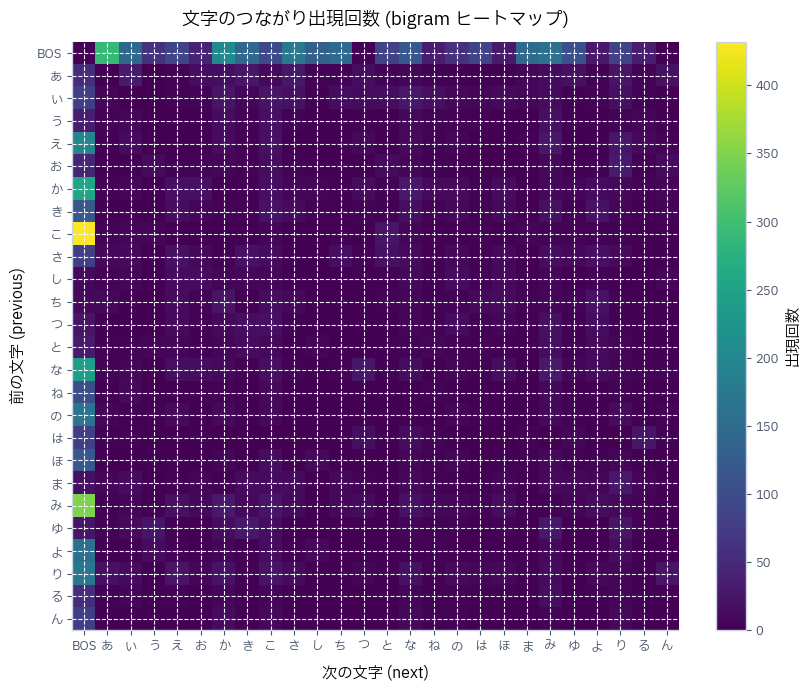

In [14]:
#@title 数え上げ表のヒートマップ { display-mode: "form" }
freq = sorted(range(len(uchars)), key=lambda i: -sum(counts[i]))[:25]
show = [BOS] + sorted(freq)
grid = [[counts[a][b] for b in show] for a in show]
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(grid, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(show)), [tok_str(i) for i in show], fontsize=9)
ax.set_yticks(range(len(show)), [tok_str(i) for i in show], fontsize=9)
ax.set_xlabel('次の文字 (next)', fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel('前の文字 (previous)', fontsize=11, fontweight='bold', labelpad=8)
ax.set_title('文字のつながり出現回数 (bigram ヒートマップ)', fontsize=13, fontweight='bold', pad=12)
cb = fig.colorbar(im, ax=ax, label='出現回数')
cb.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

BOSの行(一番上)は「名前の最初の文字」，BOSの列(一番左)は「名前の最後の文字」を表しています。
「こ」「み」「な」などで終わる名前が多いことが，一番左の列からわかりますね。
> The BOS row (top) shows "the first character of names", and the BOS column (left) shows "the last character of names".
From the leftmost column, you can see that many names end with "こ", "み", "な" and so on.

## 2.2 回数から確率へ - From counts to probabilities

数学Iの「データの分析」では，度数を全体の合計で割ったものを **相対度数** と呼びました。
相対度数は0以上1以下で，全部足すと1になります。これはそのまま **確率** として使えます。
> In Math I, a frequency divided by the total is called the **relative frequency**.
It is between 0 and 1, and all of them add up to 1. We can use it directly as a **probability**.

ただし，ここで知りたいのは「前の文字が『さ』だったときに，次が『く』である確率」です。
これは数学Aの **条件付き確率** です。
> But what we want is "the probability that the next character is 'く' when the previous one was 'さ'".
This is a **conditional probability** from Math A.

$$P(\text{次が「く」} \mid \text{前が「さ」}) = \frac{n(\text{「さ」→「く」})}{n(\text{「さ」→ 何か})}$$

数学Aの記号で書くと $P_A(B) = \dfrac{n(A \cap B)}{n(A)}$ です。$A$ は「前が『さ』」，$B$ は「次が『く』」という事象です。
> In Math A notation, this is $P_A(B) = \dfrac{n(A \cap B)}{n(A)}$, where $A$ is "the previous one is 'さ'" and $B$ is "the next one is 'く'".

In [15]:
def next_probs(a):
    total = sum(counts[a])
    return [c / total for c in counts[a]]

p = next_probs(stoi['さ'])
print('P(次が「く」| 前が「さ」) =', round(p[stoi['く']], 4))
print('全文字の確率の合計 =', round(sum(p), 6), '(きっちり 1.0 になるよ)')

P(次が「く」| 前が「さ」) = 0.0312
全文字の確率の合計 = 1.0 (きっちり 1.0 になるよ)


### [スライダー] 前の文字を選んで，次の文字の確率を見よう - [Slider] Choose the previous character and see the next-character probabilities

In [16]:
#@title [スライダー] 条件付き確率の棒グラフ { display-mode: "form" }
def plot_next(prev='さ'):
    a = BOS if prev == 'BOS' else stoi[prev]
    p = next_probs(a)
    top = sorted(range(vocab_size), key=lambda b: -p[b])[:15]
    fig, ax = plt.subplots(figsize=(8.5, 3.4))
    bars = ax.bar([tok_str(b) for b in top], [p[b] for b in top], color='#3b82f6', edgecolor='#1d4ed8', width=0.6)
    ax.set_ylim(0, max(0.2, max([p[b] for b in top]) * 1.15))
    ax.set_title(f'前の文字が「{prev}」のとき，次の文字の確率(上位15個)', fontsize=12, fontweight='bold')
    ax.set_ylabel('確率', fontsize=10)
    for bar in bars:
        h = bar.get_height()
        if h > 0.03:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8.5, color='#1e293b')
    plt.tight_layout()
    plt.show()

interact(plot_next, prev=widgets.Dropdown(options=['BOS'] + uchars, value='さ', description='前の文字:'));

## 2.3 確率にしたがってくじを引く - Drawing lots according to probabilities

確率がわかったら，その確率にしたがって次の文字を選びます。
これは「当たりやすさが違うくじ」を引くのと同じです。例えば「く」のくじが30枚，「ち」のくじが10枚入った箱から1枚引くようなものです。
Pythonでは `random.choices` がこれをやってくれます(`weights` に回数をそのまま渡しても大丈夫です)。
> Once we know the probabilities, we choose the next character according to them.
This is like drawing lots where each lot has a different chance. For example, drawing one ticket from a box with 30 "く" tickets and 10 "ち" tickets.
In Python, `random.choices` does this (you can pass the counts directly as `weights`).

### [スライダー] くじを引く回数を増やすと？ - [Slider] What happens when we draw more times?

引く回数を増やすほど，実際に出た割合(オレンジ)が確率(青)に近づいていく様子を確かめてみましょう。
> Check that the more times you draw, the closer the actual ratio (orange) gets to the probability (blue).

In [17]:
#@title [スライダー] くじ引きのシミュレーション { display-mode: "form" }
def simulate(prev='さ', draws=10):
    a = BOS if prev == 'BOS' else stoi[prev]
    p = next_probs(a)
    rng = random.Random(0)
    got = rng.choices(range(vocab_size), weights=counts[a], k=draws)
    top = sorted(range(vocab_size), key=lambda b: -p[b])[:10]
    x = range(len(top))
    fig, ax = plt.subplots(figsize=(8.5, 3.4))
    ax.bar([i - 0.2 for i in x], [p[b] for b in top], width=0.4, label='理論確率', color='#3b82f6', edgecolor='#1d4ed8')
    ax.bar([i + 0.2 for i in x], [got.count(b) / draws for b in top], width=0.4, label=f'実際の割合 ({draws}回引いた結果)', color='#f97316', edgecolor='#ea580c')
    ax.set_xticks(list(x), [tok_str(b) for b in top])
    ax.set_ylim(0, max(0.2, max([p[b] for b in top]) * 1.25))
    ax.set_title(f'「{prev}」の次の文字のくじ引き実験 (サンプル数: {draws})', fontsize=12, fontweight='bold')
    ax.set_ylabel('確率 / 割合', fontsize=10)
    ax.legend(frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

interact(simulate,
         prev=widgets.Dropdown(options=['BOS'] + uchars, value='さ', description='前の文字:'),
         draws=widgets.IntSlider(value=10, min=1, max=2000, step=10, description='引く回数:'));

## 2.4 実装: 数えるだけで名前を作る - Implementation: making names just by counting

BOSからスタートして，「次の文字を確率で選ぶ」をBOSが出るまで繰り返せば，名前ができあがります。
> Start from BOS and repeat "choose the next character by probability" until BOS comes out. Then you have a name.

In [18]:
def bigram_generate():
    token, out = BOS, []
    while True:
        token = random.choices(range(vocab_size), weights=counts[token])[0]
        if token == BOS:
            return ''.join(out)
        out.append(itos[token])

random.seed(1)
print('--- bigramモデルが作った名前 15選 ---')
for i in range(15):
    name = bigram_generate()
    note = '学習データにある名前' if name in docs else '新しい名前！'
    print(f'sample {i+1:2d}: {name:<6} ({note})')

--- bigramモデルが作った名前 15選 ---
sample  1: う      (新しい名前！)
sample  2: ぼうはる   (新しい名前！)
sample  3: まえい    (新しい名前！)
sample  4: しみあつみつ (新しい名前！)
sample  5: ゆいえ    (学習データにある名前)
sample  6: らんとねいさな (新しい名前！)
sample  7: かぜ     (学習データにある名前)
sample  8: すぐさ    (新しい名前！)
sample  9: ちふえ    (新しい名前！)
sample 10: むぎの    (新しい名前！)
sample 11: ひ      (新しい名前！)
sample 12: しゅんね   (新しい名前！)
sample 13: も      (新しい名前！)
sample 14: たはえは   (新しい名前！)
sample 15: しおり    (学習データにある名前)


微分もニューラルネットワークも使わずに，それらしい名前ができました！
これが **言語モデル** の一番シンプルな形です。LLMも本質的には「次のTokenの確率を求めて，くじを引く」ことを繰り返しています。
> Without any calculus or neural networks, we made plausible names!
This is the simplest form of a **language model**. In essence, LLMs also repeat "find the probabilities of the next token and draw a lot".

## 2.5 数えるだけのモデルの限界 - The limits of counting

でも，このモデルには大きな弱点があります。**直前の1文字しか見ていない** のです。
例えば「こ」の次にBOSが来る(=名前が終わる)確率はとても高いので，「こ」1文字だけの名前を作ってしまうことがあります。
学習データの名前の長さと，このモデルが作った名前の長さを比べてみましょう。
> But this model has a big weakness: **it only looks at the one previous character**.
For example, the probability that BOS comes after "こ" (the name ends) is very high, so it sometimes makes a one-character name "こ".
Let's compare the lengths of names in the training data with the lengths of names this model makes.

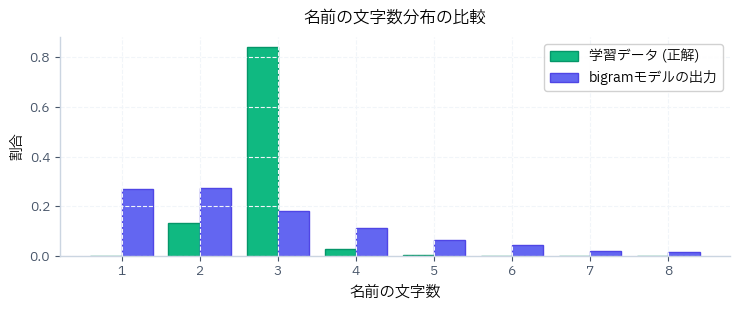

生成された1文字ネームの例: ['あ', 'い', 'う', 'え', 'お', 'か', 'き', 'ぎ', 'く', 'こ', 'さ', 'し', 'じ', 'す', 'せ', 'そ', 'た', 'だ', 'ち', 'つ', 'と', 'な', 'ね', 'の', 'は', 'ひ', 'ふ', 'べ', 'ほ', 'ま', 'み', 'む', 'め', 'も', 'や', 'ゆ', 'よ', 'ら', 'り', 'る', 'れ', 'ろ', 'わ']


In [19]:
#@title 名前の長さの比較 { display-mode: "form" }
random.seed(2)
made = [bigram_generate() for _ in range(3000)]
lengths = range(1, 9)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar([l - 0.2 for l in lengths], [sum(len(n) == l for n in docs) / len(docs) for l in lengths], width=0.4, label='学習データ (正解)', color='#10b981', edgecolor='#059669')
ax.bar([l + 0.2 for l in lengths], [sum(len(n) == l for n in made) / len(made) for l in lengths], width=0.4, label='bigramモデルの出力', color='#6366f1', edgecolor='#4f46e5')
ax.set_xlabel('名前の文字数', fontsize=11, fontweight='bold')
ax.set_ylabel('割合', fontsize=10)
ax.set_title('名前の文字数分布の比較', fontsize=12, fontweight='bold')
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()
print('生成された1文字ネームの例:', sorted({n for n in made if len(n) == 1}))

学習データには1文字の名前が1つもないのに，bigramモデルは1文字の名前や長すぎる名前を作ってしまいます。
「今は何文字目か」「前に何の文字があったか」を知らないからです。
> The training data has no one-character names at all, but the bigram model makes one-character names and names that are too long.
This is because it does not know "which position we are at" or "what characters came before".

もっと前の文字まで見たいなら，3文字の組(trigram)，4文字の組…と数えればいいように思えます。
でも，組の種類は $72^2 = 5184$，$72^3 = 373248$，… と爆発的に増えて，ほとんどの組は一度も出てこなくなってしまいます。
> If we want to look further back, it seems we could count 3-character groups (trigrams), 4-character groups, and so on.
But the number of possible groups explodes: $72^2 = 5184$, $72^3 = 373248$, ... and most groups never appear even once.

そこで，**数える代わりに「学習」で確率を求める** 方法が必要になります。これが次の章からのテーマです。
その第一歩として，次の章では「モデルの予想がどれくらい良いか」を測る方法を学びます。
> So we need a way to **find probabilities by "learning" instead of counting**. This is the theme from the next chapter.
As a first step, the next chapter shows how to measure "how good the model's predictions are".

## 練習問題 - Exercises

1. [スライダー] で前の文字を「BOS」にすると，何がわかるでしょうか？
2. 「っ」の次に来る文字には，どんな特徴があるでしょうか？ スライダーで確かめてみましょう。
3. $P(\text{次が「こ」} \mid \text{前が「み」})$ を，`counts` を使って計算してみましょう。

<details><summary>答え - Answers</summary>

1. 名前の最初の文字の確率がわかります(「あ」「ゆ」「ち」などが上位に来ます)。
2. 「か」「こ」「ぽ」の3つだけです。小さい「っ」の後には，か行やぱ行のように，つまる音の後に来られる音しか来ません。ただし「っ」はデータに4回しか出てこないので，この確率はあまり当てになりません。
3. `counts[stoi['み']][stoi['こ']] / sum(counts[stoi['み']])` で計算できます。
</details>

---
# 第3章 どれくらい外れた？: 損失とsoftmax - Chapter 3: How wrong was it? Loss and softmax

学習とは，「予想の外れ具合」を少しずつ小さくしていくことです。
そのためにはまず，外れ具合を **1つの数** で表す必要があります。それが0.1で表示されていた **loss(損失)** です。
この章では，lossの正体と，スコアを確率に変える **softmax** を学びます。
> Learning means making "how wrong the predictions are" smaller, little by little.
To do that, we first need to express how wrong they are as **one number**. That is the **loss** shown in 0.1.
In this chapter, we learn what the loss really is, and **softmax**, which turns scores into probabilities.

**この章で使う数学**: 指数・対数(数学IIの内容を，数学Iの知識からここで学びます)
> **Math in this chapter**: exponents and logarithms (Math II topics, learned here starting from Math I)

## 3.1 予想の良さを数で表したい - We want to measure how good a prediction is

第2章のbigramモデルが「さくら」という名前をどれくらい予想できるかを考えます。
モデルが「さくら」を作る確率は，4回のくじ引きがすべて当たる確率なので，それぞれの確率の **積** になります。
> Let's think about how well the bigram model from Chapter 2 predicts the name "さくら".
The probability that the model makes "さくら" is the probability of winning all 4 draws, so it is the **product** of each probability:

$$P(\text{さくら}) = P(\text{さ}\mid\text{BOS}) \times P(\text{く}\mid\text{さ}) \times P(\text{ら}\mid\text{く}) \times P(\text{BOS}\mid\text{ら})$$

この確率が大きいほど，良いモデルだといえます。計算してみましょう。
> The larger this probability, the better the model. Let's calculate it.

In [20]:
def bigram_prob(name):
    ids = tokenize(name)
    p = 1.0
    for a, b in zip(ids, ids[1:]):
        p *= next_probs(a)[b]
    return p

print('P(さくら) =', bigram_prob('さくら'))
print('P(はなこ) =', bigram_prob('はなこ'))

P(さくら) = 4.139996184562765e-05
P(はなこ) = 6.0458217696375124e-05


では，学習データ全部の名前を作る確率はどうでしょうか？ 全部の積を計算してみます。
> Then what about the probability of making all the names in the training data? Let's multiply them all.

In [21]:
total = 1.0
for name in docs:
    total *= bigram_prob(name)
print('全部の名前の確率の積 =', total)

全部の名前の確率の積 = 0.0


0.0になってしまいました！ 小さい数を3000回以上掛けると，コンピューターが表せる一番小さい数よりも小さくなってしまうのです。
**掛け算を足し算に変える道具** があれば，この問題を解決できます。それが **対数(log)** です。
対数を理解するために，まず指数から始めましょう。
> It became 0.0! Multiplying small numbers more than 3000 times gives a number smaller than the smallest number a computer can represent.
A **tool that turns multiplication into addition** would solve this problem. That tool is the **logarithm (log)**.
To understand logarithms, let's start with exponents.

## 3.2 指数: 累乗を広げる - Exponents: extending powers

中学で習った累乗 $2^3 = 2 \times 2 \times 2 = 8$ を思い出しましょう。右上の小さい数を **指数** といいます。
累乗には次の **指数法則** があります。
> Remember powers from junior high: $2^3 = 2 \times 2 \times 2 = 8$. The small number at the upper right is the **exponent**.
Powers follow the **laws of exponents**:

$$a^m \times a^n = a^{m+n}, \qquad (a^m)^n = a^{mn}$$

この法則が成り立つように考えると，指数は0や負の数，分数にも広げられます。
> If we want these laws to keep working, exponents can be extended to 0, negative numbers and fractions:

| 指数 | 考え方 | 例 |
|---|---|---|
| 0 | $2^3 \div 2 = 2^2$，$2^2 \div 2 = 2^1$，… と1つ減らすと2で割る。だから $2^0 = 2^1 \div 2 = 1$ | $2^0 = 1$ |
| 負の数 | さらに2で割っていく | $2^{-1} = \frac{1}{2}$，$2^{-2} = \frac{1}{4}$ |
| 分数 | $2^{\frac12} \times 2^{\frac12} = 2^1 = 2$ だから，2乗して2になる数 | $2^{\frac12} = \sqrt{2} \approx 1.414$ |

In [22]:
print(2**3, 2**0, 2**-1, 2**-2, 2**0.5)
print('指数法則の確認: 2**3 * 2**4 =', 2**3 * 2**4, ' 2**7 =', 2**7)

8 1 0.5 0.25 1.4142135623730951
指数法則の確認: 2**3 * 2**4 = 128  2**7 = 128


### [スライダー] 指数関数のグラフ - [Slider] The graph of an exponential function

$y = a^x$ のグラフを，$a$ を変えながら見てみましょう。
$a > 1$ なら右上がり，$0 < a < 1$ なら右下がりです。**どんな $x$ でも $y$ は必ず正** で，$x = 0$ のときはいつも $y = 1$ になります。
> Let's look at the graph of $y = a^x$ while changing $a$.
If $a > 1$ it goes up to the right; if $0 < a < 1$ it goes down. **For any $x$, $y$ is always positive**, and at $x = 0$, $y$ is always 1.

In [23]:
#@title [スライダー] 指数関数 y = a^x { display-mode: "form" }
def plot_exp(a=2.0):
    xs = [i / 20 for i in range(-60, 61)]
    ys = [a**x for x in xs]
    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    ax.plot(xs, ys, lw=2.5, color='#4f46e5', label=f'y = {a:.1f}^x')
    ax.axhline(0, color='#64748b', lw=1.0)
    ax.axvline(0, color='#64748b', lw=1.0)
    ax.plot([0], [1], 'o', color='#ef4444', ms=7)
    ax.annotate('(0, 1) を必ず通るよ', (0, 1), xytext=(15, 10), textcoords='offset points',
                fontsize=9.5, fontweight='bold', color='#ef4444',
                arrowprops=dict(arrowstyle='->', color='#ef4444', lw=1.2))
    ax.set_ylim(-0.5, 9)
    ax.set_xlim(-3, 3)
    ax.set_title(f'指数関数 y = {a:.1f}^x のグラフ', fontsize=12, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.legend(frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

interact(plot_exp, a=widgets.FloatSlider(value=2.0, min=0.2, max=4.0, step=0.1, description='底 a:'));

## 3.3 対数: 掛け算を足し算に変える - Logarithms: turning multiplication into addition

「2を何乗すると8になるか？」の答えは3です。これを
> "To what power must we raise 2 to get 8?" The answer is 3. We write this as

$$\log_2 8 = 3$$

と書き，**2を底とする8の対数** といいます。つまり $\log_a M = p$ と $a^p = M$ は同じ意味です。
> and call it **the logarithm of 8 to the base 2**. In other words, $\log_a M = p$ and $a^p = M$ mean the same thing.

指数法則 $a^m \times a^n = a^{m+n}$ を対数の言葉で言いかえると，次のとても大事な性質になります。
> If we rewrite the law of exponents $a^m \times a^n = a^{m+n}$ in terms of logarithms, we get this very important property:

$$\log_a (M \times N) = \log_a M + \log_a N$$

**掛け算の対数は，対数の足し算になる** のです。
> **The log of a product is the sum of the logs.**

In [24]:
print('log2(8)  =', math.log2(8))
print('log2(4 × 8) =', math.log2(4 * 8), ' log2(4) + log2(8) =', math.log2(4) + math.log2(8))

log2(8)  = 3.0
log2(4 × 8) = 5.0  log2(4) + log2(8) = 5.0


### [アニメーション] 掛け算が足し算になる - [Animation] Multiplication becomes addition

In [25]:
#@title アニメーション: 対数の性質 { display-mode: "form" }
def make_scene(mn, T):
    class LogScene(mn.Scene):
        def construct(self):
            title = T('log: 掛け算 → 足し算', font_size=36).to_edge(mn.UP)
            self.play(mn.Write(title))
            nums = [1, 2, 4, 8, 16, 32, 64]
            top = mn.VGroup(*[T(str(n), font_size=36) for n in nums]).arrange(mn.RIGHT, buff=0.9).shift(mn.UP * 1)
            bot = mn.VGroup(*[T(str(i), font_size=36, color=mn.YELLOW) for i in range(len(nums))]).arrange(mn.RIGHT, buff=0.9).shift(mn.DOWN * 1)
            for t, b in zip(top, bot): b.set_x(t.get_x())
            lt = T('2の累乗', font_size=26).next_to(top, mn.LEFT, buff=0.6)
            lb = T('底2の log', font_size=26, color=mn.YELLOW).next_to(bot, mn.LEFT, buff=0.6)
            self.play(mn.FadeIn(top), mn.FadeIn(lt))
            arrows = mn.VGroup(*[mn.Arrow(t.get_bottom(), b.get_top(), buff=0.15, color=mn.GRAY) for t, b in zip(top, bot)])
            self.play(mn.LaggedStart(*[mn.GrowArrow(a) for a in arrows], lag_ratio=0.1), mn.FadeIn(bot), mn.FadeIn(lb))
            m1 = T('4 × 8 = 32', font_size=34).to_edge(mn.DOWN).shift(mn.UP * 0.9 + mn.LEFT * 3)
            m2 = T('2 + 3 = 5', font_size=34, color=mn.YELLOW).to_edge(mn.DOWN).shift(mn.UP * 0.9 + mn.RIGHT * 3)
            self.play(mn.Indicate(top[2]), mn.Indicate(top[3]))
            self.play(mn.Write(m1), mn.Indicate(top[5]))
            self.play(mn.Indicate(bot[2]), mn.Indicate(bot[3]))
            self.play(mn.Write(m2), mn.Indicate(bot[5]))
            note = T('上で掛け算すると，下では足し算になるよ', font_size=28).to_edge(mn.DOWN)
            self.play(mn.Write(note))
            self.wait(1.5)
    return LogScene

show_anim(make_scene)

## 3.4 特別な数 e と自然対数 - The special number e and the natural logarithm

AIの世界では，底として $2$ や $10$ ではなく，**$e = 2.71828\ldots$** という特別な数がよく使われます。
$e$ は，例えば次のような「複利」の計算から出てきます。
> In AI, the special number **$e = 2.71828\ldots$** is often used as the base, instead of 2 or 10.
$e$ appears, for example, in this "compound interest" calculation:

1年で100%の利息がつく銀行に1円を預けると，1年後には2円になります。
では，半年ごとに50%ずつ利息がつくなら $(1 + \frac12)^2 = 2.25$ 円，毎月なら $(1 + \frac{1}{12})^{12} \approx 2.61$ 円…と，細かく分けるほど増えます。
でも無限に増えるわけではなく，ある数に近づいていきます。その数が $e$ です。
> If you put 1 yen in a bank that pays 100% interest per year, you have 2 yen after a year.
If it pays 50% every half year, you get $(1 + \frac12)^2 = 2.25$ yen; every month, $(1 + \frac{1}{12})^{12} \approx 2.61$ yen. The finer we split, the more we get.
But it does not grow forever. It gets closer to a certain number. That number is $e$.

### [スライダー] (1 + 1/n)^n が e に近づく - [Slider] (1 + 1/n)^n approaches e

In [26]:
#@title [スライダー] 複利とネイピア数 e { display-mode: "form" }
def plot_e(n=12):
    ks = list(range(1, n + 1))
    vals = [(1 + 1 / k)**k for k in ks]
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(ks, vals, 'o-', color='#0284c7', ms=3.5, lw=1.5, label='(1 + 1/n)^n')
    ax.axhline(math.e, color='#ef4444', ls='--', lw=1.5, label=f'e = {math.e:.5f}')
    ax.set_xlabel('分ける回数 n', fontsize=11)
    ax.set_ylabel('(1 + 1/n)^n の値', fontsize=11)
    ax.set_ylim(1.9, 2.85)
    ax.legend(frameon=True, facecolor='white', framealpha=0.9)
    ax.set_title(f'n = {n} のとき値は {(1 + 1 / n)**n:.5f}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(plot_e, n=widgets.IntSlider(value=12, min=1, max=500, step=5, description='分ける回数 n:'));

$e$ を底とする対数を **自然対数** といい，単に $\log x$ と書くことが多いです。Pythonでは `math.log(x)` が自然対数，`math.exp(x)` が $e^x$ です。
$e$ が特別な理由は第4章でわかります($e^x$ は微分しても形が変わらない，という不思議な性質を持っています)。
> The logarithm with base $e$ is called the **natural logarithm**, and is often written simply as $\log x$. In Python, `math.log(x)` is the natural log and `math.exp(x)` is $e^x$.
You will see why $e$ is special in Chapter 4 (it has the strange property that $e^x$ does not change its form when you differentiate it).

## 3.5 損失: -log p - Loss: -log p

いよいよlossです。モデルが正解のTokenにつけた確率を $p$ とすると，1回の予想のlossは
> Now for the loss. If $p$ is the probability the model gave to the correct token, the loss of one prediction is

$$\text{loss} = -\log p$$

です。なぜこの形なのでしょうか？ $p$ を動かして確かめてみましょう。
> Why this form? Let's move $p$ and see.

In [27]:
#@title [スライダー] 損失 loss = -log p { display-mode: "form" }
def plot_loss(p=0.3):
    xs = [i / 1000 for i in range(5, 1001)]
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    ax.plot(xs, [-math.log(x) for x in xs], lw=2.5, color='#e11d48', label='loss = -log(p)')
    ax.plot([p], [-math.log(p)], 'o', color='#1e293b', ms=8)
    ax.axvline(p, color='#94a3b8', ls=':', lw=1.2)
    ax.set_xlabel('正解文字に与えた確率 p', fontsize=11)
    ax.set_ylabel('loss = -log p', fontsize=11)
    ax.set_title(f'正解の確率 p = {p:.2f} のとき loss = {-math.log(p):.3f}', fontsize=12, fontweight='bold')
    ax.set_ylim(-0.2, 5.5)
    ax.set_xlim(0, 1.05)
    ax.legend(frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

interact(plot_loss, p=widgets.FloatSlider(value=0.3, min=0.01, max=1.0, step=0.01, description='正解確率 p:'));

- $p = 1$(自信満々で正解)なら loss $= 0$
- $p$ が小さい(正解をほとんど予想できていない)ほど，lossはどんどん大きくなる
> - If $p = 1$ (correct with full confidence), the loss is 0.
> - The smaller $p$ is (the model barely expected the correct answer), the larger the loss.

さらに，対数の性質のおかげで，**確率の積の -log は，1つ1つの -log の和** になります。
0.0になってしまった積の代わりに和を使えば，計算できるようになります。
比べやすいように，最後に予想の回数で割って **平均** にします。これが0.1で表示されていたlossです。
> Also, thanks to the property of logs, **the -log of a product of probabilities is the sum of each -log**.
If we use the sum instead of the product that became 0.0, we can calculate it.
To make it easy to compare, we divide by the number of predictions to get the **average**. This is the loss shown in 0.1.

$$\text{loss} = \frac{1}{n}\sum_{i=1}^{n} \left(-\log p_i\right)$$

($\sum$ は「全部足す」という記号です。$\sum_{i=1}^{n} a_i = a_1 + a_2 + \cdots + a_n$)
> ($\sum$ is a symbol meaning "add them all up". $\sum_{i=1}^{n} a_i = a_1 + a_2 + \cdots + a_n$)

In [28]:
def bigram_loss(names):
    total, n = 0.0, 0
    for name in names:
        ids = tokenize(name)
        for a, b in zip(ids, ids[1:]):
            total += -math.log(next_probs(a)[b])
            n += 1
    return total / n

print('bigramモデルの平均loss:', round(bigram_loss(docs), 4))
print('完全あてずっぽう(72文字ぜんぶ等確率 1/72)のloss:', round(-math.log(1 / vocab_size), 4))

bigramモデルの平均loss: 2.734
完全あてずっぽう(72文字ぜんぶ等確率 1/72)のloss: 4.2767


でたらめに予想すると loss は $-\log \frac{1}{72} = \log 72 \approx 4.28$ です。学習を始めたばかりのモデルはほぼでたらめなので，lossはこのあたりから始まります。
数えるだけのbigramモデルは約2.73です。0.1のGPTの最後のloss(直近50回の平均)と比べてみてください。ほとんど同じくらいですね。
実は今回のデータは2〜3文字の短い名前がほとんどなので，直前の1文字を見るだけでもかなり予想できてしまうのです。GPTの本当の強さは第8章で確かめます。
> A random guess gives a loss of $-\log \frac{1}{72} = \log 72 \approx 4.28$. A model that has just started learning is almost random, so its loss starts around here.
The counting bigram model gets about 2.73. Compare it with the last loss of the GPT in 0.1 (the average of the last 50 steps). They are about the same.
In fact, most names in this data are only 2 or 3 characters long, so just looking at the previous character already predicts quite well. We will check the real strength of GPT in Chapter 8.

## 3.6 softmax: スコアを確率に変える - Softmax: turning scores into probabilities

bigramモデルは回数を数えて確率を作りました。でも，これから作るニューラルネットワークは，次の文字ごとに **スコア(logit)** という数を出します。
スコアはマイナスにもなるし，全部足しても1になりません。これを確率に変える必要があります。確率に変えるための条件は3つです。
> The bigram model made probabilities by counting. But the neural networks we will build output a number called a **score (logit)** for each next character.
Scores can be negative, and they do not add up to 1. We need to turn them into probabilities. There are 3 conditions:

1. すべて0以上
2. 全部足すと1
3. スコアが大きいものほど確率も大きい(大小関係が変わらない)
> 1. All are 0 or more.
> 2. They add up to 1.
> 3. A larger score gives a larger probability (the order does not change).

「合計で割る」だけでは，マイナスがあると1.を満たせません。そこで，**先に $e^x$ で全部を正の数に変えてから，合計で割ります**。
$y = e^x$ は必ず正で，右上がりなので，1.と3.を満たします。これが **softmax** です。
> Just "dividing by the total" fails condition 1 when there are negative numbers. So **we first turn everything into positive numbers with $e^x$, and then divide by the total**.
$y = e^x$ is always positive and goes up to the right, so it satisfies 1 and 3. This is **softmax**:

$$p_i = \frac{e^{z_i}}{e^{z_1} + e^{z_2} + \cdots + e^{z_n}}$$

In [29]:
def softmax_numbers(scores, temperature=1.0):
    scores = [s / temperature for s in scores]  # temperature(温度)は次の節で説明するよ
    m = max(scores)
    exps = [math.exp(s - m) for s in scores]    # 最大値を引いておく理由は下で説明するよ
    total = sum(exps)
    return [e / total for e in exps]

scores = [2.0, 1.0, -0.5, 0.3]
probs = softmax_numbers(scores)
print('入力スコア:', scores)
print('変換後の確率:', [round(p, 3) for p in probs], '| 合計 =', round(sum(probs), 6))

入力スコア: [2.0, 1.0, -0.5, 0.3]
変換後の確率: [0.613, 0.225, 0.05, 0.112] | 合計 = 1.0


**最大値を引く理由**: $e^{1000}$ のような大きな数はコンピューターで表せず，エラーになってしまいます。
でも指数法則から $e^{z - m} = \dfrac{e^z}{e^m}$ なので，全部から同じ $m$ を引いても，分子と分母の両方が $e^m$ で割られるだけで，**確率は変わりません**。
> **Why subtract the maximum**: A huge number like $e^{1000}$ cannot be represented and causes an error.
But by the law of exponents, $e^{z - m} = \dfrac{e^z}{e^m}$, so subtracting the same $m$ from all scores just divides both the numerator and the denominator by $e^m$. **The probabilities do not change.**

In [30]:
try:
    math.exp(1000)
except OverflowError as err:
    print('math.exp(1000) はエラーだよ:', err)

print('最大値を引くので安全に計算できるよ:', softmax_numbers([1000, 999, 998]))

math.exp(1000) はエラーだよ: math range error
最大値を引くので安全に計算できるよ: [0.6652409557748218, 0.24472847105479764, 0.09003057317038046]


### [アニメーション] softmaxの流れ - [Animation] How softmax works

In [31]:
#@title アニメーション: softmax { display-mode: "form" }
def make_scene(mn, T):
    class SoftmaxScene(mn.Scene):
        def construct(self):
            scores = [2.0, 1.0, -0.5, 0.3]
            exps = [math.exp(s) for s in scores]
            probs = [e / sum(exps) for e in exps]
            labels = ['く', 'ち', 'な', 'と']
            title = T('softmax: スコア → 確率', font_size=36).to_edge(mn.UP)
            self.play(mn.Write(title))
            base = mn.DOWN * 1.5
            axis = mn.Line(mn.LEFT * 4 + base, mn.RIGHT * 4 + base, color=mn.GRAY)
            xs = [-2.7, -0.9, 0.9, 2.7]
            names = mn.VGroup(*[T(l, font_size=30).move_to([x, -2.0, 0]) for x, l in zip(xs, labels)])
            def bars(vals, scale, color):
                g = mn.VGroup()
                for x, v in zip(xs, vals):
                    h = max(abs(v) * scale, 0.02)
                    r = mn.Rectangle(width=1.0, height=h, fill_color=color, fill_opacity=0.8, stroke_width=0)
                    r.move_to([x, base[1] + (h / 2 if v >= 0 else -h / 2), 0])
                    g.add(r)
                return g
            def nums(vals, fmt):
                return mn.VGroup(*[T(fmt.format(v), font_size=24).move_to([x, 2.05, 0]) for x, v in zip(xs, vals)])
            step = T('① スコア (マイナスもあるよ)', font_size=26, color=mn.YELLOW).next_to(title, mn.DOWN, buff=0.2)
            b = bars(scores, 0.9, mn.BLUE); n = nums(scores, '{:.1f}')
            self.play(mn.Create(axis), mn.FadeIn(names), mn.FadeIn(step), mn.GrowFromEdge(b, mn.DOWN), mn.FadeIn(n))
            self.wait(1)
            step2 = T('② e^x で全部プラスに変換するよ', font_size=26, color=mn.YELLOW).next_to(title, mn.DOWN, buff=0.2)
            self.play(mn.Transform(step, step2), mn.Transform(b, bars(exps, 0.45, mn.GREEN)), mn.Transform(n, nums(exps, '{:.2f}')))
            self.wait(1)
            step3 = T('③ 合計で割る → 全部足すとキッカリ1になるよ', font_size=26, color=mn.YELLOW).next_to(title, mn.DOWN, buff=0.2)
            self.play(mn.Transform(step, step3), mn.Transform(b, bars(probs, 5.0, mn.ORANGE)), mn.Transform(n, nums(probs, '{:.2f}')))
            self.wait(2)
    return SoftmaxScene

show_anim(make_scene)

### [スライダー] スコアを動かして確率の変化を見よう - [Slider] Move the scores and watch the probabilities

In [32]:
#@title [スライダー] softmax { display-mode: "form" }
def plot_softmax(く=2.0, ち=1.0, な=-0.5, と=0.3):
    scores = [く, ち, な, と]
    probs = softmax_numbers(scores)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.4))
    ax1.bar(['く', 'ち', 'な', 'と'], scores, color='#3b82f6', edgecolor='#1d4ed8')
    ax1.axhline(0, color='#64748b', lw=1.0)
    ax1.set_ylim(-5.5, 5.5)
    ax1.set_title('スコア (logit)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('スコア値')

    bars2 = ax2.bar(['く', 'ち', 'な', 'と'], probs, color='#f97316', edgecolor='#ea580c')
    ax2.set_ylim(0, 1.1)
    ax2.set_title('softmax後の確率分布 (合計 = 1.0)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('確率')
    for bar in bars2:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f'{h:.2f}', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

sl = lambda v: widgets.FloatSlider(value=v, min=-5, max=5, step=0.1)
interact(plot_softmax, く=sl(2.0), ち=sl(1.0), な=sl(-0.5), と=sl(0.3));

スコアを全部同じだけ増やしても確率が変わらないことや，1つだけ大きくするとその確率が急に1に近づくことを確かめてみましょう。
> Check that adding the same amount to all scores does not change the probabilities, and that making one score large quickly pushes its probability toward 1.

## 3.7 temperature: 選び方の自由さ - Temperature: how freely to choose

0.1のコードには `temperature = 0.5` という設定がありました。softmaxの前に，スコアを **temperature $T$ で割る** のです。
> The code in 0.1 had the setting `temperature = 0.5`. Before softmax, we **divide the scores by the temperature $T$**:

$$p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

- $T$ が小さい → スコアの差が大きくなり，一番スコアが高いものばかり選ぶ(まじめ・同じ答えばかり)
- $T = 1$ → そのままの確率
- $T$ が大きい → スコアの差が小さくなり，どれも同じくらいの確率になる(自由・でたらめ)
> - Small $T$ → the differences between scores grow, so it almost always picks the top one (serious, always the same answer).
> - $T = 1$ → the original probabilities.
> - Large $T$ → the differences shrink, so everything gets similar probabilities (free, random).

bigramモデルでも試せます。確率 $p$ の対数 $\log p$ をスコアとして使えば，$T = 1$ のときに元の確率に戻ります。
> We can try it with the bigram model. If we use $\log p$ as the score, we get back the original probabilities when $T = 1$.

### [スライダー] temperatureを変えて名前を作ろう - [Slider] Make names while changing the temperature

In [33]:
#@title [スライダー] temperature (生成の温度感) { display-mode: "form" }
log_counts = [[math.log(c) if c > 0 else float('-inf') for c in row] for row in counts]

def bigram_generate_t(temperature, rng):
    token, out = BOS, []
    while len(out) < 10:
        token = rng.choices(range(vocab_size), weights=softmax_numbers(log_counts[token], temperature))[0]
        if token == BOS:
            break
        out.append(itos[token])
    return ''.join(out)

def show_temperature(temperature=1.0):
    p = softmax_numbers(log_counts[BOS], temperature)
    top = sorted(range(vocab_size), key=lambda b: -p[b])[:15]
    fig, ax = plt.subplots(figsize=(8.5, 3.0))
    ax.bar([tok_str(b) for b in top], [p[b] for b in top], color='#8b5cf6', edgecolor='#6d28d9')
    ax.set_ylim(0, max(0.2, max([p[b] for b in top]) * 1.15))
    ax.set_title(f'T = {temperature:.1f} のときの「最初の文字」の確率(上位15個)', fontsize=12, fontweight='bold')
    ax.set_ylabel('確率')
    plt.tight_layout()
    plt.show()
    rng = random.Random(0)
    print('作った名前:', ' '.join(bigram_generate_t(temperature, rng) for _ in range(12)))

interact(show_temperature, temperature=widgets.FloatSlider(value=1.0, min=0.1, max=3.0, step=0.1, description='温度 T:', continuous_update=False));

ChatGPTなどでも，同じ質問をしたのに毎回少し違う答えが返ってくるのは，このようにくじ引きで次のTokenを選んでいるからです。
> The reason ChatGPT gives slightly different answers to the same question is that it chooses the next token by drawing lots like this.

## 3.8 0.1のコードとの対応 - Matching with the code in 0.1

```python
def softmax(logits):                                  # 3.6 softmax関数だよ
    max_val = max(val.data for val in logits)         # 数値安定化のため最大値を引くよ
    exps = [(val - max_val).exp() for val in logits]  # e^x を計算するよ
    total = sum(exps)
    return [e / total for e in exps]                  # 合計で割って確率化するよ

loss_t = -probs[target_id].log()                      # 3.5 1文字の損失 loss = -log p だよ
loss = (1 / n) * sum(losses)                          # 3.5 全ステップの平均損失だよ
probs = softmax([l / temperature for l in logits])    # 3.7 temperatureで割ってからサンプリングするよ
```

0.1のコードの `softmax` は `val.data` や `.exp()` のように書かれていますが，やっていることは `softmax_numbers` と同じです(この書き方の理由は第5章でわかります)。
> The `softmax` in 0.1 is written with `val.data` and `.exp()`, but it does the same thing as `softmax_numbers` (you will see why it is written this way in Chapter 5).

## 練習問題 - Exercises

1. $\log_2 \frac{1}{8}$ の値を答えましょう。
2. 3つのスコアがすべて同じとき，softmaxの確率はどうなるでしょうか？
3. 正解の確率が $p = 0.5$ のとき，lossはいくつになるでしょうか？(`math.log` で計算してみましょう)

<details><summary>答え - Answers</summary>

1. $-3$($2^{-3} = \frac{1}{8}$ だから)
2. すべて $\frac{1}{3}$
3. $-\log 0.5 = \log 2 \approx 0.693$
</details>

---
# 第4章 lossを小さくする: 勾配降下法 - Chapter 4: Making the loss smaller: gradient descent

前の章で，予想の外れ具合をlossという1つの数で表せるようになりました。
学習とは，**lossが一番小さくなるようにパラメーター(モデルの中の数)を調整すること** です。
この章では，数学Iの二次関数から出発して，その調整の方法である **勾配降下法** を学びます。
> In the last chapter, we learned to express how wrong the predictions are as one number, the loss.
Learning means **adjusting the parameters (the numbers inside the model) so that the loss becomes as small as possible**.
In this chapter, starting from quadratic functions in Math I, we learn the method for this adjustment: **gradient descent**.

**この章で使う数学**: 二次関数(数学I)，変化の割合，微分(数学IIの内容をここで学びます)
> **Math in this chapter**: quadratic functions (Math I), rate of change, derivatives (a Math II topic, learned here)

## 4.1 復習: 二次関数の最小値 - Review: the minimum of a quadratic function

$f(x) = x^2 - 6x + 10$ の最小値を求めましょう。数学Iで習った **平方完成** を使うと
> Let's find the minimum of $f(x) = x^2 - 6x + 10$. Using **completing the square** from Math I:

$$f(x) = (x - 3)^2 + 1$$

となるので，$x = 3$ のとき最小値 $1$ をとります。グラフの頂点が $(3, 1)$ ですね。
> So the minimum value is $1$ at $x = 3$. The vertex of the graph is $(3, 1)$.

## 4.2 式がわからないときはどうする？ - What if we don't know the formula?

二次関数なら平方完成で一発ですが，GPTのlossは **5000個以上のパラメーターを持つ，とても複雑な関数** です。平方完成のような方法は使えません。
わかるのは，「今のパラメーターでlossを計算するといくつになるか」だけです。
> For a quadratic function, completing the square solves it at once. But the loss of a GPT is **a very complicated function with more than 5000 parameters**. We cannot use a method like completing the square.
All we know is "what the loss is for the current parameters".

これは，**霧の中で山を下りる** のに似ています。遠くは見えませんが，足元の地面が「どちらに傾いているか」はわかります。
それなら，**低くなる方向に少しずつ進めば**，いつか谷底にたどり着けるはずです。
そのために必要なのが，「傾き」を求める方法です。
> This is like **walking down a mountain in fog**. You cannot see far, but you can feel which way the ground at your feet is sloping.
Then, if you **keep taking small steps in the downhill direction**, you should eventually reach the bottom of the valley.
What we need for this is a way to find the "slope".

## 4.3 傾き: 変化の割合 - Slope: the rate of change

中学や数学Iで習った **変化の割合** を思い出しましょう。$x$ が $a$ から $b$ まで変わるとき
> Remember the **rate of change** from junior high and Math I. When $x$ changes from $a$ to $b$:

$$\text{変化の割合} = \frac{y\text{ の増加量}}{x\text{ の増加量}} = \frac{f(b) - f(a)}{b - a}$$

これはグラフ上の2点を結んだ直線の傾きです。
> This is the slope of the straight line connecting two points on the graph.

In [34]:
def f(x):
    return x**2 - 6*x + 10

def rate_of_change(f, a, b):
    return (f(b) - f(a)) / (b - a)

print('x: 0 → 1 の変化の割合:', rate_of_change(f, 0, 1))
print('x: 4 → 5 の変化の割合:', rate_of_change(f, 4, 5))

x: 0 → 1 の変化の割合: -5.0
x: 4 → 5 の変化の割合: 3.0


$x = 0$ 付近では傾きがマイナス(右下がり)，$x = 4$ 付近ではプラス(右上がり)です。
つまり，谷底 $x = 3$ は「傾きがマイナスからプラスに変わるところ」にあります。
> Near $x = 0$ the slope is negative (going down), and near $x = 4$ it is positive (going up).
So the bottom of the valley at $x = 3$ is "where the slope changes from negative to positive".

## 4.4 2点を近づける: 微分 - Bringing the two points closer: derivatives

でも，2点の間の変化の割合は「その区間の平均の傾き」にすぎません。知りたいのは **ちょうどその点での傾き** です。
そこで，2点目を $a + h$ として，$h$ をどんどん0に近づけてみます。
> But the rate of change between two points is only "the average slope over that interval". What we want is **the slope exactly at that point**.
So let the second point be $a + h$, and make $h$ closer and closer to 0.

### [アニメーション] 2点を近づけると接線になる - [Animation] Bringing two points together gives a tangent line

In [35]:
#@title アニメーション: 割線から接線へ { display-mode: "form" }
def make_scene(mn, T):
    class SecantToTangent(mn.Scene):
        def construct(self):
            ax = mn.Axes(x_range=[-0.5, 3, 1], y_range=[-0.5, 6, 1], x_length=7, y_length=5.5, tips=False).shift(mn.LEFT * 1.8 + mn.DOWN * 0.3)
            graph = ax.plot(lambda x: x**2, x_range=[-0.3, 2.45], color=mn.BLUE)
            lab = T('y = x²', font_size=28, color=mn.BLUE).next_to(ax.c2p(2.3, 5.3), mn.LEFT)
            self.play(mn.Create(ax), mn.Create(graph), mn.FadeIn(lab))
            a = 1.0
            h = mn.ValueTracker(1.3)
            p = mn.Dot(ax.c2p(a, a**2), color=mn.YELLOW)
            q = mn.always_redraw(lambda: mn.Dot(ax.c2p(a + h.get_value(), (a + h.get_value())**2), color=mn.RED))
            def secant():
                hv = h.get_value(); s = ((a + hv)**2 - a**2) / hv
                return ax.plot(lambda x: a**2 + s * (x - a), x_range=[-0.3, 2.8], color=mn.RED)
            line = mn.always_redraw(secant)
            def info_mob():
                hv = h.get_value()
                return mn.VGroup(T(f'幅 h = {hv:.3f}', font_size=28),
                                 T(f'傾き = {((a + hv)**2 - a**2) / hv:.3f}', font_size=28, color=mn.RED),
                                 ).arrange(mn.DOWN, aligned_edge=mn.LEFT).to_corner(mn.UR).shift(mn.DOWN * 0.8)
            info = info_mob()
            self.play(mn.FadeIn(p), mn.FadeIn(q), mn.Create(line), mn.FadeIn(info))
            for hv in [1.0, 0.7, 0.5, 0.3, 0.15, 0.05, 0.01, 0.001]:
                self.play(h.animate.set_value(hv), run_time=0.6)
                self.play(mn.Transform(info, info_mob()), run_time=0.3)
            ans = T('x = 1 での傾き(微分係数) = 2', font_size=28, color=mn.YELLOW).to_edge(mn.DOWN)
            self.play(mn.Write(ans))
            self.wait(1.5)
    return SecantToTangent

show_anim(make_scene)

$h$ を0に近づけていくと，2点を結ぶ直線は，その点でグラフに接する直線(**接線**)に近づきます。
この接線の傾きを **微分係数** といい，$f'(a)$ と書きます。
> As $h$ approaches 0, the line through the two points approaches the line that touches the graph at that point (the **tangent line**).
The slope of this tangent line is called the **derivative** at $a$, written $f'(a)$:

$$f'(a) = \lim_{h \to 0} \frac{f(a + h) - f(a)}{h}$$

($\lim_{h \to 0}$ は「$h$ を限りなく0に近づけたときに近づく値」という意味です)
> ($\lim_{h \to 0}$ means "the value it approaches as $h$ gets infinitely close to 0".)

$f(x) = x^2$ で計算してみましょう。展開すると
> Let's calculate it for $f(x) = x^2$. Expanding:

$$\frac{(a + h)^2 - a^2}{h} = \frac{2ah + h^2}{h} = 2a + h$$

$h$ を0に近づけると $2a$ に近づくので，$f'(a) = 2a$ です。$a = 1$ なら傾きは2で，アニメーションと一致しますね。
> As $h$ approaches 0, this approaches $2a$, so $f'(a) = 2a$. When $a = 1$ the slope is 2, matching the animation.

### [スライダー] 点と h を動かして傾きを見よう - [Slider] Move the point and h to see the slope

In [36]:
#@title [スライダー] 割線の傾きと接線の微分係数 { display-mode: "form" }
def plot_secant(a=1.0, h=1.0):
    g = lambda x: x**2
    xs = [i / 50 for i in range(-150, 151)]
    s = (g(a + h) - g(a)) / h
    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    ax.plot(xs, [g(x) for x in xs], lw=2.5, color='#4f46e5', label='y = x²')
    ax.plot(xs, [g(a) + s * (x - a) for x in xs], color='#ef4444', lw=1.8, label=f'2点を結ぶ直線 (傾き: {s:.3f})')
    ax.plot(xs, [g(a) + 2 * a * (x - a) for x in xs], color='#10b981', ls='--', lw=2.0, label=f'接線 2a (傾き: {2 * a:.3f})')
    ax.plot([a, a + h], [g(a), g(a + h)], 'o', color='#1e293b', ms=6)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-1.5, 7.5)
    ax.legend(loc='upper center', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)
    ax.set_title(f'x = {a:.1f} における割線と接線の比較 (h = {h:.2f})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(plot_secant,
         a=widgets.FloatSlider(value=1.0, min=-2.0, max=2.0, step=0.1, description='点 a:'),
         h=widgets.FloatSlider(value=1.0, min=0.01, max=2.0, step=0.01, description='幅 h:'));

$a$ を変えれば，その点での傾きもわかります。$a$ に対して傾き $f'(a)$ を対応させる関数を **導関数** といい，$f'(x)$ と書きます。「導関数を求めること」を **微分する** といいます。
同じように計算すると，次の公式が得られます。
> We can find the slope at any point $a$. The function that maps $a$ to its slope $f'(a)$ is called the **derivative function**, written $f'(x)$. Finding it is called **differentiating**.
Calculating in the same way, we get these formulas:

| 関数 | 導関数 | ひとこと |
|---|---|---|
| $c$ (定数) | $0$ | 平らなので傾き0 |
| $x^n$ | $n x^{n-1}$ | $x^2 \to 2x$，$x^3 \to 3x^2$ |
| $k f(x)$ | $k f'(x)$ | 定数倍はそのまま |
| $f(x) + g(x)$ | $f'(x) + g'(x)$ | 足し算は別々に微分 |
| $e^x$ | $e^x$ | 微分しても変わらない！ |
| $\log x$ | $\dfrac{1}{x}$ | |

最後の2つ($e^x$ と $\log x$)は数学IIIの内容なので，ここでは「そうなる」と受け入れて，コンピューターで確かめるだけにしましょう。$e$ が特別な数なのは，$e^x$ が微分しても形が変わらないからです。
> The last two ($e^x$ and $\log x$) are Math III topics, so let's just accept them here and check them with a computer. $e$ is special because $e^x$ keeps its form when differentiated.

In [37]:
def numerical_derivative(f, a, h=1e-6):
    return (f(a + h) - f(a)) / h

a = 1.5
print(f'f(x) = x^2 - 6x + 10: 数値で {numerical_derivative(f, a):.4f}  公式 2x - 6 = {2*a - 6:.4f}')
print(f'e^x:                 数値で {numerical_derivative(math.exp, a):.4f}  公式 e^x = {math.exp(a):.4f}')
print(f'log x:               数値で {numerical_derivative(math.log, a):.4f}  公式 1/x = {1/a:.4f}')

f(x) = x^2 - 6x + 10: 数値で -3.0000  公式 2x - 6 = -3.0000
e^x:                 数値で 4.4817  公式 e^x = 4.4817
log x:               数値で 0.6667  公式 1/x = 0.6667


## 4.5 勾配降下法: 傾きの逆向きに少しずつ進む - Gradient descent: small steps against the slope

傾きがわかれば，下る方向がわかります。
- 傾きがプラス(右上がり) → 左に進むと下がる
- 傾きがマイナス(右下がり) → 右に進むと下がる
> Once we know the slope, we know which way is down.
> - Positive slope (going up to the right) → moving left goes down.
> - Negative slope (going down to the right) → moving right goes down.

どちらの場合も「**傾きと逆の向きに進む**」と下がります。これを式にしたのが **勾配降下法** です。
> In both cases, **moving against the slope** goes down. Writing this as a formula gives **gradient descent**:

$$x \leftarrow x - \eta \, f'(x)$$

$\eta$(イータ)は **学習率** で，1回にどれくらい進むかを決めます。$\leftarrow$ は「右辺の値で $x$ を更新する」という意味です。
> $\eta$ (eta) is the **learning rate**, which decides how far to move each time. $\leftarrow$ means "update $x$ with the value on the right".

In [38]:
def df(x):
    return 2*x - 6  # f(x) = x^2 - 6x + 10 の導関数だよ

x = 0.0
learning_rate = 0.1
for step in range(31):
    if step % 5 == 0:
        print(f'step {step:2d}: x = {x:.4f}, f(x) = {f(x):.4f}')
    x = x - learning_rate * df(x)

step  0: x = 0.0000, f(x) = 10.0000
step  5: x = 2.0170, f(x) = 1.9664
step 10: x = 2.6779, f(x) = 1.1038
step 15: x = 2.8944, f(x) = 1.0111
step 20: x = 2.9654, f(x) = 1.0012
step 25: x = 2.9887, f(x) = 1.0001
step 30: x = 2.9963, f(x) = 1.0000


平方完成をしなくても，$x = 3$，最小値 $1$ にたどり着きました！
> Without completing the square, we reached $x = 3$ and the minimum value $1$!

### [アニメーション] 坂を下るボール - [Animation] A ball rolling down the slope

In [39]:
#@title アニメーション: 勾配降下法 { display-mode: "form" }
def make_scene(mn, T):
    class GradientDescent(mn.Scene):
        def construct(self):
            fx = lambda x: (x - 3)**2 + 1
            ax = mn.Axes(x_range=[-0.5, 6.5, 1], y_range=[0, 12, 2], x_length=8, y_length=4.8, tips=False).shift(mn.DOWN * 0.1)
            graph = ax.plot(fx, x_range=[-0.1, 6.1], color=mn.BLUE)
            title = T('勾配降下法: x ← x − η f′(x)', font_size=32).to_edge(mn.UP)
            self.play(mn.Write(title), mn.Create(ax), mn.Create(graph))
            x, lr = 0.1, 0.15
            ball = mn.Dot(ax.c2p(x, fx(x)), color=mn.YELLOW, radius=0.12)
            self.play(mn.FadeIn(ball))
            for i in range(10):
                s = 2 * (x - 3)
                lo, hi = x - 1, x + 1
                if s != 0:
                    t_top = x + (11.5 - fx(x)) / s
                    if s > 0: hi = min(hi, t_top)
                    else: lo = max(lo, t_top)
                tan = ax.plot(lambda t: fx(x) + s * (t - x), x_range=[lo, hi], color=mn.RED)
                lab = T(f'傾き {s:+.2f}', font_size=26, color=mn.RED).next_to(ax.c2p(x, fx(x)), mn.UR, buff=0.2)
                self.play(mn.Create(tan), mn.FadeIn(lab), run_time=0.35)
                x = x - lr * s
                self.play(ball.animate.move_to(ax.c2p(x, fx(x))), mn.FadeOut(tan), mn.FadeOut(lab), run_time=0.45)
            note = T('傾きが0に近づくと，歩幅も自然に小さくなるよ', font_size=26).to_edge(mn.DOWN)
            self.play(mn.Write(note))
            self.wait(1.5)
    return GradientDescent

show_anim(make_scene)

## 4.6 学習率の大きさ - How big should the learning rate be?

学習率が小さすぎると，なかなか谷底にたどり着きません。逆に大きすぎると，谷底を飛び越えてしまいます。
スライダーで確かめてみましょう。この関数では，学習率が1を超えると，谷底からどんどん遠ざかってしまいます(**発散**)。
> If the learning rate is too small, it takes a long time to reach the bottom. If it is too large, it jumps over the bottom.
Check it with the slider. For this function, when the learning rate is larger than 1, it moves farther and farther away from the bottom (**divergence**).

### [スライダー] 学習率とステップ数 - [Slider] Learning rate and number of steps

In [40]:
#@title [スライダー] 学習率を変えて坂を下る { display-mode: "form" }
def plot_descent(learning_rate=0.1, steps=10, start=0.0):
    x, path = start, [start]
    for _ in range(steps):
        x = x - learning_rate * df(x)
        path.append(x)
    xs = [i / 20 for i in range(-40, 161)]
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    ax.plot(xs, [f(t) for t in xs], lw=2.5, color='#3b82f6', label='f(x) = (x-3)² + 1')
    shown = [p for p in path if -2 <= p <= 8]
    ax.plot(shown, [f(p) for p in shown], 'o-', color='#ef4444', ms=5, lw=1.5, alpha=0.8, label='探索ルート')
    if -2 <= path[-1] <= 8:
        ax.plot([path[-1]], [f(path[-1])], 'o', color='#eab308', ms=11, mec='#a16207', mew=2, label='現在地')
    ax.set_xlim(-2, 8)
    ax.set_ylim(-1, 30)
    ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper right')
    if not (-2 <= path[-1] <= 8) or f(path[-1]) > 30:
        ax.text(0.5, 0.85, '発散！(画面の外に飛んでいる)', transform=ax.transAxes, ha='center',
                color='#dc2626', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='#fee2e2', edgecolor='#ef4444', boxstyle='round,pad=0.5'))
    ax.set_title(f'{steps}ステップ後: x = {path[-1]:.4g}, f(x) = {f(path[-1]):.4g}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(plot_descent,
         learning_rate=widgets.FloatSlider(value=0.1, min=0.01, max=1.1, step=0.01, description='学習率 η:'),
         steps=widgets.IntSlider(value=10, min=0, max=50, step=1, description='ステップ数:'),
         start=widgets.FloatSlider(value=0.0, min=-1, max=7, step=0.5, description='スタート:'));

学習率0.9くらいにすると，谷底をはさんで左右にジグザグしながら近づく様子が見られます。1を超えると発散します。
0.1のコードでは，学習率を **最初は大きく，だんだん小さく** していました(`lr_t = learning_rate * (1 - step / num_steps)`)。
最初は大きく進んで早く谷に近づき，最後は小さく進んで谷底を飛び越えないようにするためです。
> Around 0.9, you can see it zigzag left and right across the bottom while getting closer. Above 1, it diverges.
In 0.1, the learning rate was **large at first and gradually smaller** (`lr_t = learning_rate * (1 - step / num_steps)`).
This is to move fast toward the valley at first, and take small steps at the end so as not to jump over the bottom.

## 4.7 変数が2つ以上あるとき - When there are two or more variables

GPTのパラメーターは5000個以上あります。変数が2つの場合で考えてみましょう。
> A GPT has more than 5000 parameters. Let's think about the case with two variables:

$$f(x, y) = (x - 1)^2 + 2(y + 2)^2$$

変数が2つあっても，**「他の変数を定数だと思って，1つの変数だけで微分する」** ことができます。これを **偏微分** といいます。
> Even with two variables, we can **treat the other variables as constants and differentiate with respect to just one**. This is called **partial differentiation**.

- $y$ を定数とみて $x$ で微分: $2(x - 1)$
- $x$ を定数とみて $y$ で微分: $4(y + 2)$
> - Treat $y$ as a constant and differentiate by $x$: $2(x - 1)$
> - Treat $x$ as a constant and differentiate by $y$: $4(y + 2)$

この2つの傾きを並べたもの $\big(2(x-1),\ 4(y+2)\big)$ を **勾配(gradient)** といいます。勾配降下法は，$x$ と $y$ をそれぞれ自分の傾きの逆向きに動かします。
変数が5000個あっても，やることは同じです。
> The pair of these two slopes $\big(2(x-1),\ 4(y+2)\big)$ is called the **gradient**. Gradient descent moves $x$ and $y$ each against its own slope.
Even with 5000 variables, we do the same thing.

### [スライダー] 等高線の上を下る - [Slider] Going down on a contour map

下の図は，$f(x, y)$ の値を地図の **等高線** のように表したものです。中心(×印)が谷底です。
> The figure below shows the values of $f(x, y)$ like **contour lines** on a map. The center (×) is the bottom of the valley.

In [41]:
#@title [スライダー] 2変数の勾配降下法 { display-mode: "form" }
import numpy as np
def f2(x, y): return (x - 1)**2 + 2 * (y + 2)**2

def plot_descent2(learning_rate=0.1, steps=20):
    x, y = -3.0, 1.5
    path = [(x, y)]
    for _ in range(steps):
        gx, gy = 2 * (x - 1), 4 * (y + 2)
        x, y = x - learning_rate * gx, y - learning_rate * gy
        path.append((x, y))
    X, Y = np.meshgrid(np.linspace(-4, 4, 200), np.linspace(-5, 3, 200))
    fig, ax = plt.subplots(figsize=(6.5, 5))
    cs = ax.contour(X, Y, f2(X, Y), levels=20, cmap='viridis')
    px = [p[0] for p in path if abs(p[0]) < 10 and abs(p[1]) < 10]
    py = [p[1] for p in path if abs(p[0]) < 10 and abs(p[1]) < 10]
    ax.plot(px, py, 'o-', color='#ef4444', ms=4.5, lw=1.5, label='探索ルート')
    ax.plot([1], [-2], 'x', color='#0f172a', ms=12, mew=3, label='谷底 (目標地点)')
    ax.set_xlim(-4, 4); ax.set_ylim(-5, 3); ax.set_aspect('equal')
    ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper left')
    if not (-4 <= path[-1][0] <= 4 and -5 <= path[-1][1] <= 3):
        ax.text(0.5, 0.08, '発散！(画面の外に飛んでいる)', transform=ax.transAxes, ha='center',
                color='#dc2626', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='#fee2e2', edgecolor='#ef4444', boxstyle='round,pad=0.5'))
    ax.set_title(f'{steps}ステップ後: f = {f2(*path[-1]):.4g}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(plot_descent2,
         learning_rate=widgets.FloatSlider(value=0.1, min=0.01, max=0.55, step=0.01, description='学習率 η:'),
         steps=widgets.IntSlider(value=20, min=0, max=60, step=1, description='ステップ数:'));

学習率を0.25より大きくすると，$y$ の方向だけジグザグし始め，0.5を超えると発散します。$y$ の方向のほうが坂が急だからです。
方向によって坂の急さが違うと，1つの学習率ではうまくいかないことがあります。この問題は第10章のAdamで解決します。
> When the learning rate is larger than 0.25, it starts to zigzag only in the $y$ direction, and above 0.5 it diverges, because the slope is steeper in that direction.
When steepness differs by direction, a single learning rate may not work well. We will solve this with Adam in Chapter 10.

## 4.8 実装: 勾配降下法で確率を学習する - Implementation: learning probabilities with gradient descent

いよいよ勾配降下法で，名前について何かを学習させてみましょう。
まずは簡単な例として，「**名前の最初の文字** の確率」を学習させます。
72個のスコア $z_0, z_1, \ldots, z_{71}$ をパラメーターとし，softmaxで確率に変えて，lossを計算します。
> Now let's use gradient descent to learn something about names.
As a simple example, we learn "the probabilities of **the first character of a name**".
We use 72 scores $z_0, z_1, \ldots, z_{71}$ as parameters, turn them into probabilities with softmax, and calculate the loss.

微分の公式を使って傾きを求めるのは大変なので，4.4でやったように **数値微分**(ほんの少し $h$ だけ動かして変化の割合を計算する)で傾きを求めます。
> Finding the slopes with formulas would be hard, so we find them by **numerical differentiation** (move by a tiny $h$ and calculate the rate of change), as in 4.4.

In [42]:
first_counts = counts[BOS]   # 第2章の表から「BOSの次(=最初の文字)」の回数を取り出すよ
n_names = sum(first_counts)

def first_char_loss(z):
    p = softmax_numbers(z)
    return sum(c * -math.log(p[i]) for i, c in enumerate(first_counts) if c > 0) / n_names

def numerical_gradient(loss_fn, z, h=1e-5):
    base = loss_fn(z)
    grad = []
    for i in range(len(z)):           # パラメーターを1個ずつ少しだけ動かして…
        z_moved = z.copy()
        z_moved[i] += h
        grad.append((loss_fn(z_moved) - base) / h)  # …変化の割合を求めるよ
    return grad

z = [0.0] * vocab_size   # 最初はすべて同じスコア(=でたらめな予想)だよ
learning_rate = 10.0
n_evals = 0
for step in range(201):
    grad = numerical_gradient(first_char_loss, z)
    n_evals += len(z) + 1
    z = [zi - learning_rate * gi for zi, gi in zip(z, grad)]
    if step % 40 == 0:
        print(f'step {step:3d}: loss = {first_char_loss(z):.4f}')
print('lossを計算した回数:', n_evals)

step   0: loss = 4.0635
step  40: loss = 3.5497
step  80: loss = 3.5339
step 120: loss = 3.5286
step 160: loss = 3.5260
step 200: loss = 3.5245
lossを計算した回数: 14673


lossが下がりました。学習した確率を，第2章で数えて求めた相対度数と比べてみましょう。
> The loss went down. Let's compare the learned probabilities with the relative frequencies we counted in Chapter 2.

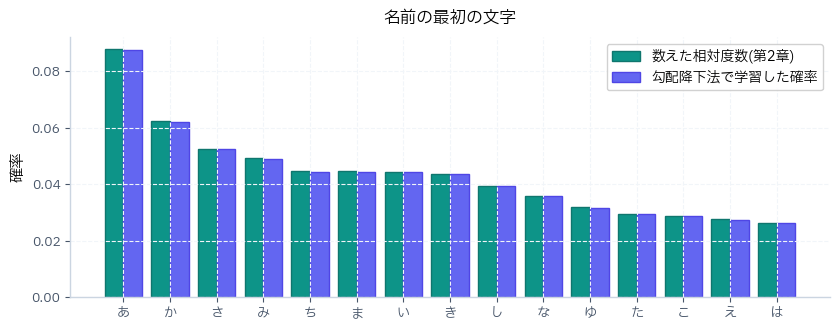

In [43]:
#@title 学習した確率と数えた確率の比較 { display-mode: "form" }
learned = softmax_numbers(z)
counted = [c / n_names for c in first_counts]
top = sorted(range(vocab_size), key=lambda i: -counted[i])[:15]
xs = range(len(top))
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.bar([i - 0.2 for i in xs], [counted[i] for i in top], width=0.4, label='数えた相対度数(第2章)', color='#0d9488', edgecolor='#0f766e')
ax.bar([i + 0.2 for i in xs], [learned[i] for i in top], width=0.4, label='勾配降下法で学習した確率', color='#6366f1', edgecolor='#4f46e5')
ax.set_xticks(list(xs), [tok_str(i) for i in top])
ax.set_ylabel('確率')
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
ax.set_title('名前の最初の文字')
plt.tight_layout()
plt.show()

ほぼ同じになりました！ 勾配降下法でlossを小さくすると，数えて求めた確率と同じ答えにたどり着くのです。
数えることができない複雑なモデルでも，lossさえ計算できれば，同じ方法で学習できます。これが機械学習の基本的な考え方です。
> They are almost the same! Making the loss smaller with gradient descent leads to the same answer as counting.
Even for complicated models where we cannot count, we can learn in the same way as long as we can calculate the loss. This is the basic idea of machine learning.

**でも問題があります。** 72個のパラメーターの傾きを求めるのに，1ステップごとにlossを73回計算しました。
0.1のGPTにはパラメーターが5000個以上あるので，1ステップごとにGPT全体の計算を5000回以上やり直すことになります。これではとても遅すぎます。
次の章では，**1回の計算で全部のパラメーターの傾きを一気に求める方法** を学びます。
> **But there is a problem.** To find the slopes of 72 parameters, we calculated the loss 73 times per step.
The GPT in 0.1 has more than 5000 parameters, so each step would need more than 5000 full GPT calculations. That is far too slow.
In the next chapter, we learn **a way to find the slopes of all the parameters at once, in one pass**.

## 4.9 0.1のコードとの対応 - Matching with the code in 0.1

```python
lr_t = learning_rate * (1 - step / num_steps)        # 4.6 学習率をだんだん小さくするよ
p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)   # 4.5 傾きの逆向きに進むよ(Adamという改良版。第10章)
```

## 練習問題 - Exercises

1. $f(x) = 3x^2 + 2x$ の導関数を求めてみましょう。
2. $f(x) = (x + 2)^2$ で，$x = 0$，学習率0.25から勾配降下法を1ステップ進めると，$x$ はいくつになるでしょうか？
3. [スライダー] (4.6)で，学習率をちょうど1にするとどうなるでしょうか？ なぜそうなるか考えてみましょう。

<details><summary>答え - Answers</summary>

1. $f'(x) = 6x + 2$ です。
2. $f'(x) = 2(x + 2)$ なので $f'(0) = 4$ です。$x = 0 - 0.25 \times 4 = -1$ になります。
3. 谷底をはさんで同じ2点($x = 0$ と $x = 6$)を行ったり来たりし続けます。$x - 1 \cdot 2(x - 3) = 6 - x$ なので，谷底 $3$ からの距離が変わらないからです。
</details>

---
# 第5章 微分を自動で: 計算グラフと連鎖律 ★ - Chapter 5: Automatic derivatives: computation graphs and the chain rule ★

前の章の最後で，数値微分では「パラメーターの数だけlossを計算し直す」必要があり，遅すぎることがわかりました。
この章では，**1回の計算で，すべてのパラメーターの傾きを一気に求める方法**(**誤差逆伝播法**，backpropagation)を学びます。
0.1のコードの `class Value` の部分です。
> At the end of the last chapter, we saw that numerical differentiation needs "as many loss calculations as there are parameters", which is too slow.
In this chapter, we learn **a way to find the slopes of all the parameters at once in one pass** (**backpropagation**).
This is the `class Value` part of the code in 0.1.

> ★ この章は少し難しいです。「lossから逆向きにたどると，全部の傾きが一気にわかる」ということだけつかめれば，先に進んでも大丈夫です。
> ★ This chapter is a bit hard. If you get the idea "going backward from the loss gives all the slopes at once", you can move on.

**この章で使う数学**: 微分(第4章)，合成関数の微分(連鎖律，数学IIIの内容を直感的に)
> **Math in this chapter**: derivatives (Chapter 4), the derivative of composite functions (the chain rule, a Math III topic, explained intuitively)

## 5.1 計算を図にする: 計算グラフ - Drawing a calculation: computation graphs

次の計算を考えます。
> Consider this calculation:

$$L = (a \times b + c)^2$$

これを，1回の計算(掛け算，足し算，2乗)ごとに分けて，矢印でつなぐと次のようになります。このような図を **計算グラフ** といいます。
> If we split it into single operations (multiply, add, square) and connect them with arrows, we get the figure below. Such a figure is called a **computation graph**.

```
a ──┐
    ×── d = a×b ──┐
b ──┘             +── e = d + c ── ^2 ── L = e²
c ────────────────┘
```

$a = 2,\ b = -3,\ c = 10$ なら，$d = -6$，$e = 4$，$L = 16$ です。左から右に計算していくことを **順伝播**(forward pass)といいます。
> If $a = 2,\ b = -3,\ c = 10$, then $d = -6$, $e = 4$, $L = 16$. Calculating from left to right is called the **forward pass**.

知りたいのは，「$a$ を少し増やすと $L$ はどれくらい変わるか」，つまり $L$ を $a$ で微分した傾きです($b$，$c$ についても同じです)。
> What we want to know is "how much $L$ changes when we increase $a$ a little", that is, the slope of $L$ with respect to $a$ (and the same for $b$ and $c$).

## 5.2 1つ1つの計算の傾き - The slope of each single operation

まず，1回の計算だけに注目したときの傾き(**局所的な傾き**)を考えます。
> First, think about the slope of just one operation (the **local slope**).

| 計算 | $x$ を少し増やすと… | 局所的な傾き |
|---|---|---|
| $x + y$ | 増やした分だけ増える | **$1$** |
| $x \times y$ | 増やした分の $y$ 倍だけ増える | **$y$** |
| $x^n$ | 第4章の公式 | **$n x^{n-1}$** |
| $e^x$ | 第4章の公式 | **$e^x$** |
| $\log x$ | 第4章の公式 | **$\dfrac{1}{x}$** |

例えば $x \times y$ で $x$ を $h$ だけ増やすと $(x + h) \times y = xy + h y$ なので，$h$ の $y$ 倍だけ増えます。だから傾きは $y$ です。
> For example, if we increase $x$ by $h$ in $x \times y$, we get $(x + h) \times y = xy + hy$, so it grows by $y$ times $h$. That is why the slope is $y$.

## 5.3 連鎖律: 傾きは掛け算でつながる - The chain rule: slopes connect by multiplication

計算がつながっているとき，全体の傾きはどうなるでしょうか？ 歯車で考えてみます。
> When operations are connected, what is the overall slope? Let's think with gears.

- 歯車Aを1回転させると，歯車Bは3回転する
- 歯車Bを1回転させると，歯車Cは2回転する
> - Turning gear A once turns gear B 3 times.
> - Turning gear B once turns gear C 2 times.

すると，歯車Aを1回転させると，歯車Cは $3 \times 2 = 6$ 回転しますね。
傾きも同じで，**つながった計算の傾きは，それぞれの傾きの掛け算** になります。これを **連鎖律** といいます。
> Then turning gear A once turns gear C $3 \times 2 = 6$ times.
Slopes work the same way: **the slope of connected operations is the product of each slope**. This is called the **chain rule**.

確かめてみましょう。$y = (2x + 1)^2$ を展開すると $4x^2 + 4x + 1$ なので，第4章の公式から $y' = 8x + 4$ です。
連鎖律で考えると，$u = 2x + 1$ とおいて
> Let's check. Expanding $y = (2x + 1)^2$ gives $4x^2 + 4x + 1$, so by the formulas in Chapter 4, $y' = 8x + 4$.
With the chain rule, let $u = 2x + 1$:

- $u$ を $x$ で微分: $2$
- $y = u^2$ を $u$ で微分: $2u = 2(2x + 1)$
- 掛け算: $2(2x + 1) \times 2 = 8x + 4$

同じ答えになりました！
> The same answer!

## 5.4 逆向きにたどる - Going backward

連鎖律を使うと，$L$ から出発して **右から左へ** 局所的な傾きを掛けていけば，すべての変数の傾きがわかります。
これを **逆伝播**(backward pass)といいます。
> With the chain rule, if we start from $L$ and multiply local slopes **from right to left**, we get the slopes of all the variables.
This is called the **backward pass**.

1. $L$ の $L$ に対する傾きは $1$(自分自身なので)
2. $L = e^2$ なので，$e$ の傾き $= 2e \times 1 = 8$
3. $e = d + c$ なので，$d$ の傾き $= 1 \times 8 = 8$，$c$ の傾き $= 1 \times 8 = 8$
4. $d = a \times b$ なので，$a$ の傾き $= b \times 8 = -24$，$b$ の傾き $= a \times 8 = 16$
> 1. The slope of $L$ with respect to itself is $1$.
> 2. Since $L = e^2$, the slope for $e$ is $2e \times 1 = 8$.
> 3. Since $e = d + c$, the slope for $d$ is $1 \times 8 = 8$, and for $c$ it is $1 \times 8 = 8$.
> 4. Since $d = a \times b$, the slope for $a$ is $b \times 8 = -24$, and for $b$ it is $a \times 8 = 16$.

**1回たどるだけで，すべての傾きがわかりました。** パラメーターが5000個あっても，逆向きに1回たどるだけで済みます。
> **One pass gave us all the slopes.** Even with 5000 parameters, one backward pass is enough.

### [アニメーション] 順伝播と逆伝播 - [Animation] Forward pass and backward pass

In [44]:
#@title アニメーション: 計算グラフの順伝播と逆伝播 { display-mode: "form" }
def make_scene(mn, T):
    class BackpropGraph(mn.Scene):
        def construct(self):
            title = T('L = (a × b + c)²', font_size=34).to_edge(mn.UP)
            self.play(mn.Write(title))
            pos = {'a': [-5, 2.1, 0], 'b': [-5, 0, 0], 'c': [-5, -2.1, 0], 'd': [-2, 1.05, 0], 'e': [1, 0, 0], 'L': [4.5, 0, 0]}
            ops = {'d': '×', 'e': '+', 'L': '²'}
            val = {'a': 2, 'b': -3, 'c': 10, 'd': -6, 'e': 4, 'L': 16}
            grad = {'L': 1, 'e': 8, 'd': 8, 'c': 8, 'a': -24, 'b': 16}
            nodes = {}
            for k, p in pos.items():
                circ = mn.Circle(0.45, color=mn.BLUE if k in 'abc' else mn.TEAL).move_to(p)
                nodes[k] = mn.VGroup(circ, T(k, font_size=30).move_to(p))
            edges = [('a', 'd'), ('b', 'd'), ('d', 'e'), ('c', 'e'), ('e', 'L')]
            arrows = {e: mn.Arrow(nodes[e[0]].get_center(), nodes[e[1]].get_center(), buff=0.5, color=mn.GRAY) for e in edges}
            oplabels = [T(ops[k], font_size=26, color=mn.TEAL).next_to(nodes[k], mn.UP, buff=0.1) for k in ops]
            self.play(*[mn.FadeIn(n) for n in nodes.values()], *[mn.GrowArrow(a) for a in arrows.values()], *[mn.FadeIn(o) for o in oplabels])
            fw = T('順伝播: 左から右へ値を計算するよ', font_size=28, color=mn.YELLOW).to_edge(mn.DOWN)
            self.play(mn.FadeIn(fw))
            vlabels = {}
            for k in ['a', 'b', 'c', 'd', 'e', 'L']:
                v = T(f'{val[k]}', font_size=26, color=mn.YELLOW).next_to(nodes[k], mn.DOWN, buff=0.12)
                vlabels[k] = v
                self.play(mn.FadeIn(v, shift=mn.UP * 0.2), mn.Indicate(nodes[k], color=mn.YELLOW), run_time=0.45)
            bw = T('逆伝播: 右から左へ傾きを掛けていくよ', font_size=28, color=mn.RED).to_edge(mn.DOWN)
            self.play(mn.Transform(fw, bw))
            for k in ['L', 'e', 'd', 'c', 'a', 'b']:
                g = T(f'傾き {grad[k]}', font_size=24, color=mn.RED).next_to(vlabels[k], mn.DOWN, buff=0.1)
                incoming = [arrows[e] for e in edges if e[0] == k]
                anims = [mn.FadeIn(g, shift=mn.LEFT * 0.2), mn.Indicate(nodes[k], color=mn.RED)]
                anims += [mn.ShowPassingFlash(a.copy().set_color(mn.RED).rotate(mn.PI), time_width=0.6) for a in incoming]
                self.play(*anims, run_time=0.6)
            self.wait(2)
    return BackpropGraph

show_anim(make_scene)

### 1つの変数が2回以上使われるとき - When one variable is used more than once

$L = a \times a$ のように，同じ変数が2か所で使われることもあります。このときは，**それぞれの道から来た傾きを足し合わせます**。
$a \times a$ の1つ目の $a$ から来る傾きは $a$，2つ目から来る傾きも $a$ なので，合計 $2a$ です。$a^2$ を微分した $2a$ と一致しますね。
> The same variable can be used in two places, like $L = a \times a$. Then we **add up the slopes coming from each path**.
The slope from the first $a$ is $a$, and from the second is also $a$, so the total is $2a$. This matches $2a$, the derivative of $a^2$.

## 5.5 実装: Valueクラス - Implementation: the Value class

これをプログラムにしたのが，0.1のコードの `Value` クラスです。
`Value` は1つの数を包む「箱」で，次の4つを覚えています。
> The `Value` class in 0.1 is this idea as a program.
A `Value` is a "box" that wraps one number and remembers these 4 things:

| 名前 | 意味 |
|---|---|
| `data` | 順伝播で計算した値 |
| `grad` | 逆伝播で求めた，lossに対する傾き |
| `_children` | この値を作るのに使った値(矢印の元) |
| `_local_grads` | それぞれの `_children` に対する局所的な傾き(5.2の表) |

`+` や `*` で計算するたびに，新しい `Value` が「自分を何から作ったか」と「局所的な傾き」を覚えていくので，計算が終わると自動的に計算グラフができあがっています。
> Every time we calculate with `+` or `*`, a new `Value` remembers "what it was made from" and "the local slopes", so the computation graph is built automatically by the time the calculation is done.

In [45]:
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads')

    def __init__(self, data, children=(), local_grads=()):
        self.data = data                # 順伝播で計算した値だよ
        self.grad = 0                   # 逆伝播で求める傾きだよ
        self._children = children       # 自分を作るのに使った値だよ
        self._local_grads = local_grads # それぞれに対する局所的な傾きだよ

    def __add__(self, other):  # x + y の局所的な傾きは (1, 1) だよ
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))

    def __mul__(self, other):  # x × y の局所的な傾きは (y, x) だよ
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))  # n x^(n-1)
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))                           # 1/x
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))                   # e^x
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))                   # 第7章で使うよ

    # 以下は，引き算や割り算などを上の計算の組み合わせで表すためのものだよ
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    def backward(self):
        # 1) 計算グラフを「子が必ず親より前に来る」順番に並べるよ(トポロジカルソート)
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # 2) 自分自身の傾きは1。そこから逆順にたどって，連鎖律で傾きを掛けて足し込むよ
        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad   # 5.4の「足し合わせる」は += でやっているよ

`backward` の中の「並べ替え」は，「ある値の傾きを使う前に，その値を使ったすべての計算からの傾きが足し込まれている」ようにするためのものです。
5.1の例で確かめてみましょう。
> The "sorting" inside `backward` makes sure that "before we use the slope of a value, the slopes from all the operations that used it have been added in".
Let's check with the example from 5.1.

In [46]:
a, b, c = Value(2.0), Value(-3.0), Value(10.0)
L = (a * b + c) ** 2
L.backward()
print('L =', L.data)
print('傾き: a =', a.grad, ' b =', b.grad, ' c =', c.grad)

# 数値微分(第4章)でも確かめてみるよ
h = 1e-6
Lf = lambda a, b, c: (a * b + c) ** 2
print('数値微分: a =', round((Lf(2 + h, -3, 10) - Lf(2, -3, 10)) / h, 3),
      ' b =', round((Lf(2, -3 + h, 10) - Lf(2, -3, 10)) / h, 3),
      ' c =', round((Lf(2, -3, 10 + h) - Lf(2, -3, 10)) / h, 3))

L = 16.0
傾き: a = -24.0  b = 16.0  c = 8.0
数値微分: a = -24.0  b = 16.0  c = 8.0


### [スライダー] 値を変えて傾きの変化を見よう - [Slider] Change the values and watch the slopes

$a, b, c$ を動かすと，計算グラフの各ノードの値(黒)と傾き(赤)が変わります。
例えば $b = 0$ にすると $a$ の傾きが0になります。「$b$ が0なら，$a$ をいくら変えても $a \times b$ は0のまま」だからです。
> Moving $a, b, c$ changes the value (black) and slope (red) of each node in the computation graph.
For example, when $b = 0$, the slope for $a$ becomes 0, because "if $b$ is 0, $a \times b$ stays 0 no matter how you change $a$".

In [47]:
#@title [スライダー] 計算グラフの値と傾き { display-mode: "form" }
def plot_graph(a=2.0, b=-3.0, c=10.0):
    A, B, C = Value(a), Value(b), Value(c)
    D = A * B; E = D + C; L = E ** 2
    L.backward()
    nodes = {'a': (0, 2, A), 'b': (0, 1, B), 'c': (0, 0, C), 'd = a×b': (1.6, 1.5, D), 'e = d+c': (3.2, 1, E), 'L = e²': (4.8, 1, L)}
    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    for (s, t) in [('a', 'd = a×b'), ('b', 'd = a×b'), ('d = a×b', 'e = d+c'), ('c', 'e = d+c'), ('e = d+c', 'L = e²')]:
        ax.annotate('', xy=nodes[t][:2], xytext=nodes[s][:2],
                    arrowprops=dict(arrowstyle='->', color='#94a3b8', lw=1.8, shrinkA=30, shrinkB=30))
    for name, (x, y, v) in nodes.items():
        is_leaf = name in 'abc'
        bg = '#eff6ff' if is_leaf else '#f0fdf4'
        edge = '#3b82f6' if is_leaf else '#10b981'
        ax.text(x, y + 0.05, f'{name}\n値: {v.data:.2f}', ha='center', va='center', fontsize=9.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=bg, edgecolor=edge, lw=1.5))
        ax.text(x, y - 0.22, f'傾き: {v.grad:.2f}', ha='center', va='center', color='#dc2626', fontsize=10, fontweight='bold')
    ax.set_xlim(-0.7, 5.5); ax.set_ylim(-0.6, 2.6); ax.axis('off')
    ax.set_title('計算グラフの値と傾きの可視化', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

sl = lambda v: widgets.FloatSlider(value=v, min=-5.0, max=12.0, step=0.5)
interact(plot_graph, a=sl(2.0), b=sl(-3.0), c=sl(10.0));

## 5.6 数値微分と比べてみよう - Compare with numerical differentiation

第4章の「最初の文字の確率」の学習を，`Value` を使ってやり直してみます。
今度はlossを1回計算して `backward()` を1回呼ぶだけで，72個すべての傾きが求まります。
> Let's redo "learning the probabilities of the first character" from Chapter 4, this time with `Value`.
Now we only calculate the loss once and call `backward()` once to get all 72 slopes.

In [48]:
import time

def first_char_loss_value(z):
    p = softmax(z)  # 0.1と同じ，Value用のsoftmaxだよ
    return sum(c * -p[i].log() for i, c in enumerate(first_counts) if c > 0) * (1 / n_names)

z_v = [Value(0.0) for _ in range(vocab_size)]
t0 = time.time()
for step in range(201):
    loss = first_char_loss_value(z_v)
    loss.backward()                    # 1回の逆伝播で全部の傾きが求まるよ
    for p in z_v:
        p.data -= 10.0 * p.grad
        p.grad = 0                     # 次のステップのために傾きを0に戻すよ
    if step % 40 == 0:
        print(f'step {step:3d}: loss = {loss.data:.4f}')
print(f'かかった時間: {time.time() - t0:.2f}秒')

t0 = time.time()
numerical_gradient(first_char_loss, [0.0] * vocab_size)
t_num = time.time() - t0
t0 = time.time()
first_char_loss_value([Value(0.0) for _ in range(vocab_size)]).backward()
t_back = time.time() - t0
print(f'1ステップの傾きを求める時間  数値微分: {t_num*1000:.1f}ミリ秒 / 逆伝播: {t_back*1000:.1f}ミリ秒')
print(f'数値微分は lossを{vocab_size + 1}回計算 / 逆伝播は 順伝播1回 + 逆伝播1回')

step   0: loss = 4.2767
step  40: loss = 3.5505
step  80: loss = 3.5341
step 120: loss = 3.5287
step 160: loss = 3.5261
step 200: loss = 3.5245
かかった時間: 0.40秒
1ステップの傾きを求める時間  数値微分: 4.0ミリ秒 / 逆伝播: 3.3ミリ秒
数値微分は lossを73回計算 / 逆伝播は 順伝播1回 + 逆伝播1回


今回はパラメーターが72個しかないので，時間の差はそれほど大きくないかもしれません(`Value` は1つ1つの計算を記録するぶん，1回あたりは遅いのです)。
でも，数値微分はパラメーターの数に比例して遅くなるのに対し，逆伝播はパラメーターが増えても「順伝播1回 + 逆伝播1回」のままです。
パラメーターが5000個，本物のLLMのように数千億個になると，この差は決定的になります。
> Since there are only 72 parameters here, the time difference may not be very big (`Value` records every single operation, so each step is slower).
But numerical differentiation gets slower in proportion to the number of parameters, while backpropagation stays at "one forward pass + one backward pass" even as parameters increase.
With 5000 parameters, or hundreds of billions as in real LLMs, this difference is decisive.

> PyTorchなどの本物の機械学習ライブラリも，やっていることはこの `Value` と同じです。ただし，1つ1つの数ではなく，たくさんの数をまとめて(行列として)一気に計算するので，ずっと速いのです。
> Real machine learning libraries like PyTorch do the same thing as this `Value`. But they calculate many numbers together at once (as matrices), not one number at a time, so they are much faster.

## 練習問題 - Exercises

1. $L = (a + b) \times b$ で $a = 1,\ b = 2$ のとき，$a$ と $b$ の傾きを手で計算してみましょう。そのあと `Value` で確かめてみましょう。
2. `p.grad = 0` を消すとどうなるでしょうか？

<details><summary>答え - Answers</summary>

1. $L = ab + b^2$ なので，$a$ の傾き $= b = 2$，$b$ の傾き $= a + 2b = 5$ です。
   計算グラフでは，$b$ は「$a + b$」と「$\times b$」の2か所で使われるので，$1 \times b$(=2)と $(a + b)$(=3)を足して5になります。
2. 前のステップの傾きがどんどん足し込まれて，正しい傾きにならなくなります(`+=` で足しているからです)。
</details>

---
# 第6章 文字をベクトルに: 埋め込みと線形変換 - Chapter 6: Characters as vectors: embeddings and linear transformations

第1章では文字に番号を付けました。でも番号には「あ(0)と い(1)は近い」のような意味はありません。
この章では，1つの文字を **いくつかの数の組(ベクトル)** で表す方法(**埋め込み**)と，ベクトルを変換する **線形変換** を学びます。
そして，いよいよ `Value` と勾配降下法を使って，初めてのニューラルネットワークを学習させます。
> In Chapter 1, we gave numbers to characters. But the numbers have no meaning like "あ (0) and い (1) are close".
In this chapter, we learn how to represent one character as **a group of several numbers (a vector)** (**embedding**), and **linear transformations**, which transform vectors.
Then, using `Value` and gradient descent, we train our first neural network.

**この章で使う数学**: ベクトル(数学Cの内容をここで学びます)，三角比(数学I「図形と計量」)，三平方の定理(中学)
> **Math in this chapter**: vectors (a Math C topic, learned here), trigonometric ratios (Math I), the Pythagorean theorem (junior high)

## 6.1 番号だけでは「似ている」を表せない - Numbers alone cannot express "similar"

「こ」と「み」は，どちらも名前の最後によく来る文字です。だから，モデルにとっては「似た性質」を持っています。
でも番号で見ると「こ」は14番，「み」は53番で遠く，逆に「さ」は16番で「こ」のすぐ近くです。番号の近さと性質の近さは関係ありません。
> "こ" and "み" both often come at the end of names, so for the model they have "similar properties".
But as numbers, "こ" is 14 and "み" is 53, far apart, while "さ" is 16, right next to "こ". How close the numbers are has nothing to do with how similar the properties are.

そこで，1つの文字をいくつかの数の組で表すことにします。例えば
> So we represent each character by a group of numbers. For example:

- 「こ」→ $(0.9,\ -0.2)$
- 「み」→ $(0.8,\ -0.1)$
- 「さ」→ $(-0.7,\ 0.5)$

のように表せば，「こ」と「み」は近く，「さ」は遠い，ということを表せます。
しかも，**この数の組そのものを学習で決める** のです。
> This way we can express that "こ" and "み" are close and "さ" is far.
Moreover, **these groups of numbers themselves are decided by learning**.

## 6.2 ベクトル: 数の組 - Vectors: groups of numbers

$(3,\ 1)$ のような数の組を **ベクトル** といいます。平面上の **矢印** だと考えることもできます(原点から点 $(3, 1)$ へ向かう矢印)。
ベクトルの足し算と実数倍は，成分ごとに計算します。
> A group of numbers like $(3,\ 1)$ is called a **vector**. You can also think of it as an **arrow** on a plane (from the origin to the point $(3, 1)$).
Adding vectors and multiplying them by a number are done component by component:

$$(a_1,\ a_2) + (b_1,\ b_2) = (a_1 + b_1,\ a_2 + b_2), \qquad k(a_1,\ a_2) = (k a_1,\ k a_2)$$

ベクトルの長さ $|\vec{a}|$ は，三平方の定理から $|\vec{a}| = \sqrt{a_1^2 + a_2^2}$ です。
> The length of a vector $|\vec{a}|$ is $\sqrt{a_1^2 + a_2^2}$, by the Pythagorean theorem.

Pythonでは，ベクトルはリストで表します。成分が2つでも16個でも，考え方は同じです。
> In Python, we represent vectors as lists. Whether there are 2 components or 16, the idea is the same.

### [スライダー] ベクトルの足し算 - [Slider] Adding vectors

In [49]:
#@title [スライダー] ベクトルの和と実数倍 { display-mode: "form" }
def plot_vectors(a1=3.0, a2=1.0, b1=1.0, b2=2.0, k=1.0):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    def arrow(x0, y0, x, y, c, l, lw=2.2, alpha=1.0):
        ax.annotate('', xy=(x0 + x, y0 + y), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color=c, lw=lw, alpha=alpha))
        if l: ax.plot([], [], color=c, lw=lw, label=l)
    arrow(0, 0, k * a1, k * a2, '#10b981', f'{k:.2f}a = ({k * a1:.1f}, {k * a2:.1f})', lw=5, alpha=0.3)
    arrow(0, 0, a1, a2, '#3b82f6', f'a = ({a1:.1f}, {a2:.1f})')
    arrow(0, 0, b1, b2, '#f97316', f'b = ({b1:.1f}, {b2:.1f})')
    arrow(a1, a2, b1, b2, '#f97316', None, alpha=0.5)
    arrow(0, 0, a1 + b1, a2 + b2, '#ef4444', f'a + b = ({a1 + b1:.1f}, {a2 + b2:.1f})', lw=2.8)
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6); ax.set_aspect('equal')
    ax.axhline(0, color='#64748b', lw=0.8); ax.axvline(0, color='#64748b', lw=0.8)
    ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)
    ax.set_title('ベクトルの足し算 (平行四辺形の対角線)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

sl = lambda v, d: widgets.FloatSlider(value=v, min=-4, max=4, step=0.5, description=d)
interact(plot_vectors, a1=sl(3, 'a の x:'), a2=sl(1, 'a の y:'), b1=sl(1, 'b の x:'), b2=sl(2, 'b の y:'),
         k=widgets.FloatSlider(value=1.0, min=-2, max=2, step=0.25, description='倍率 k:'));

## 6.3 内積: 2つのベクトルの「似ている度合い」 - The dot product: how similar two vectors are

2つのベクトルについて，**成分どうしを掛けて足したもの** を **内積** といいます。
> For two vectors, **multiplying matching components and adding them up** gives the **dot product**:

$$\vec{a} \cdot \vec{b} = a_1 b_1 + a_2 b_2$$

実は，内積は2つのベクトルのなす角 $\theta$ を使って，次のようにも表せます(数学Iで習う $\cos$ です)。
> In fact, the dot product can also be written with the angle $\theta$ between the two vectors (the $\cos$ from Math I):

$$\vec{a} \cdot \vec{b} = |\vec{a}|\,|\vec{b}| \cos\theta$$

$\cos\theta$ は，$\theta = 0°$ で $1$，$90°$ で $0$，$180°$ で $-1$ でしたね。だから内積は
> $\cos\theta$ is $1$ at $0°$, $0$ at $90°$, and $-1$ at $180°$. So the dot product is:

- 同じ向き → 大きいプラス
- 直角 → 0
- 反対向き → マイナス
> - Same direction → large positive
> - Perpendicular → 0
> - Opposite directions → negative

となり，**2つのベクトルがどれくらい同じ向きを向いているか(似ているか)** を表す数になります。これは第8章のAttentionで大活躍します。
> So it is a number that shows **how much two vectors point in the same direction (how similar they are)**. This plays a big role in Attention in Chapter 8.

### [アニメーション] 向きが変わると内積が変わる - [Animation] The dot product changes with direction

In [50]:
#@title アニメーション: 内積と角度 { display-mode: "form" }
def make_scene(mn, T):
    class DotProduct(mn.Scene):
        def construct(self):
            plane = mn.NumberPlane(x_range=[-4, 4], y_range=[-3, 3], x_length=7, y_length=5.25, background_line_style={'stroke_opacity': 0.3}).shift(mn.LEFT * 2.5)
            title = T('内積: 同じ向きほど値が大きくなる！', font_size=32).to_edge(mn.UP)
            self.play(mn.Create(plane), mn.Write(title))
            a = [2.5, 0.0]
            va = mn.Arrow(plane.c2p(0, 0), plane.c2p(*a), buff=0, color=mn.BLUE)
            la = T('a', font_size=30, color=mn.BLUE).next_to(va.get_end(), mn.DOWN)
            ang = mn.ValueTracker(20)
            bvec = lambda: [2 * math.cos(math.radians(ang.get_value())), 2 * math.sin(math.radians(ang.get_value()))]
            vb = mn.always_redraw(lambda: mn.Arrow(plane.c2p(0, 0), plane.c2p(*bvec()), buff=0, color=mn.ORANGE))
            def info():
                b = bvec(); d = a[0] * b[0] + a[1] * b[1]
                col = mn.GREEN if d > 0.05 else (mn.RED if d < -0.05 else mn.WHITE)
                return mn.VGroup(T(f'角度 θ = {ang.get_value():.0f}°', font_size=28),
                                 T(f'cos θ = {math.cos(math.radians(ang.get_value())):+.2f}', font_size=28),
                                 T(f'内積 = {d:+.2f}', font_size=34, color=col)).arrange(mn.DOWN, aligned_edge=mn.LEFT).to_edge(mn.RIGHT).shift(mn.LEFT * 0.3)
            txt = info()
            self.play(mn.GrowArrow(va), mn.FadeIn(la), mn.FadeIn(vb), mn.FadeIn(txt))
            for target in [60, 90, 120, 180, 135, 45, 20]:
                self.play(ang.animate.set_value(target), run_time=0.8)
                self.play(mn.Transform(txt, info()), run_time=0.3)
                self.wait(0.4 if target in (90, 180) else 0.1)
            self.wait(1)
    return DotProduct

show_anim(make_scene)

### [スライダー] 角度と長さを変えて内積を見よう - [Slider] Change the angle and length and see the dot product

In [51]:
#@title [スライダー] 内積 { display-mode: "form" }
def plot_dot(angle=45, length_b=2.0):
    a = (2.5, 0.0)
    b = (length_b * math.cos(math.radians(angle)), length_b * math.sin(math.radians(angle)))
    dot = a[0] * b[0] + a[1] * b[1]
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    for v, c, l in [(a, '#3b82f6', 'a'), (b, '#f97316', 'b')]:
        ax.annotate('', xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle='->', color=c, lw=3))
        ax.text(v[0] * 1.12, v[1] * 1.12, l, color=c, fontsize=14, fontweight='bold')
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5); ax.set_aspect('equal')
    ax.set_title(f'成分計算: a·b = {a[0]}×{b[0]:.2f} + {a[1]}×{b[1]:.2f} = {dot:.2f}\n幾何定義: |a||b|cosθ = {2.5 * length_b * math.cos(math.radians(angle)):.2f}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(plot_dot, angle=widgets.IntSlider(value=45, min=0, max=360, step=5, description='角度 θ:'),
         length_b=widgets.FloatSlider(value=2.0, min=0, max=3, step=0.1, description='b の長さ:'));

2つの式で計算した値が一致することを確かめてください。
> Check that the values calculated by the two formulas match.

## 6.4 埋め込み: 文字をベクトルにする表 - Embeddings: a table that turns characters into vectors

**埋め込み(embedding)** は，とてもシンプルです。語彙の大きさ × ベクトルの成分の数(`n_embd`)の **表** を用意して，Token番号の行をそのまま取り出すだけです。
0.1のコードでは `state_dict['wte']` がこの表で，大きさは $72 \times 16$ でした(wteは word token embedding の略です)。
> An **embedding** is very simple. We prepare a **table** of size vocabulary × number of vector components (`n_embd`) and just take out the row for the token number.
In 0.1, `state_dict['wte']` is this table, of size $72 \times 16$ (wte stands for word token embedding).

```python
tok_emb = state_dict['wte'][token_id]   # token_id 行目を取り出すだけで，その文字のベクトルになるよ
```

最初は表の中身はでたらめな数ですが，学習によって「似た使われ方をする文字は似たベクトル」になるように調整されていきます。
同じように，「何文字目か」を表すベクトルの表 `wpe`(word position embedding)もあります。これは第8章で使います。
> At first the table is filled with random numbers, but learning adjusts it so that "characters used in similar ways get similar vectors".
Similarly, there is a table `wpe` (word position embedding) with vectors for "which position". We will use it in Chapter 8.

## 6.5 行列と線形変換 - Matrices and linear transformations

数を長方形に並べたものを **行列** といいます。行列は「ベクトルを何本か重ねたもの」と考えることができます。
0.1のコードの `linear(x, w)` は，**行列 `w` の各行と，ベクトル `x` の内積を並べたもの** を計算しています。これを **線形変換** といいます。
> Numbers arranged in a rectangle are called a **matrix**. You can think of a matrix as "several vectors stacked together".
`linear(x, w)` in 0.1 calculates **the dot product of each row of the matrix `w` with the vector `x`, and lines them up**. This is called a **linear transformation**.

$$\begin{pmatrix} 1 & 2 \\ 0 & -1 \\ 3 & 1 \end{pmatrix} \text{ で } \begin{pmatrix} 2 \\ 1 \end{pmatrix} \text{ を変換} \;\to\; \begin{pmatrix} 1 \cdot 2 + 2 \cdot 1 \\ 0 \cdot 2 + (-1) \cdot 1 \\ 3 \cdot 2 + 1 \cdot 1 \end{pmatrix} = \begin{pmatrix} 4 \\ -1 \\ 7 \end{pmatrix}$$

各行は「ある特徴を調べるための物差し」のようなもので，内積が大きいほど「その特徴に近い」ことを表します。
行の数を変えれば，**2成分のベクトルを3成分に** のように，ベクトルの成分の数も変えられます。
> Each row is like "a ruler that checks for a certain feature", and a larger dot product means "closer to that feature".
By changing the number of rows, we can also change the number of components, like **from 2 components to 3**.

In [52]:
def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]  # 各行 wo と入力 x の内積を計算してリストにするよ

W = [[1, 2], [0, -1], [3, 1]]
print('線形変換の計算結果:', linear([2, 1], W))

線形変換の計算結果: [4, -1, 7]


### [アニメーション] 線形変換の計算 - [Animation] How a linear transformation is calculated

In [53]:
#@title アニメーション: 線形変換 = 各行との内積 { display-mode: "form" }
def make_scene(mn, T):
    class LinearScene(mn.Scene):
        def construct(self):
            W = [[1, 2], [0, -1], [3, 1]]; x = [2, 1]
            title = T('linear(x, W): 行列の各行と x の内積を並べる', font_size=32).to_edge(mn.UP)
            self.play(mn.Write(title))
            def mat(rows_, color=mn.WHITE):
                rows_g = mn.VGroup(*[mn.VGroup(*[T(str(e), font_size=36, color=color) for e in r]).arrange(mn.RIGHT, buff=0.6) for r in rows_]).arrange(mn.DOWN, buff=0.4)
                for r in rows_g:
                    for j, e in enumerate(r): e.set_x(rows_g[0][j].get_x())
                h = rows_g.height + 0.3
                lb = mn.VGroup(mn.Line(mn.UP * h / 2, mn.DOWN * h / 2), mn.Line(mn.UP * h / 2, mn.UP * h / 2 + mn.RIGHT * 0.15), mn.Line(mn.DOWN * h / 2, mn.DOWN * h / 2 + mn.RIGHT * 0.15)).next_to(rows_g, mn.LEFT, buff=0.15)
                rb = lb.copy().flip(mn.UP).next_to(rows_g, mn.RIGHT, buff=0.15)
                return mn.VGroup(rows_g, lb, rb)
            m = mat(W).shift(mn.LEFT * 3.5)
            v = mat([[e] for e in x]).next_to(m, mn.RIGHT)
            eq = T('=', font_size=40).next_to(v, mn.RIGHT)
            out = [sum(a * b for a, b in zip(row, x)) for row in W]
            res = mat([[o] for o in out], color=mn.YELLOW).next_to(eq, mn.RIGHT)
            for e in res[0]: e.set_opacity(0)
            self.play(mn.FadeIn(m), mn.FadeIn(v), mn.FadeIn(eq), mn.FadeIn(res[1]), mn.FadeIn(res[2]))
            rows = m[0]
            for i, row in enumerate(W):
                box = mn.SurroundingRectangle(rows[i], color=mn.YELLOW)
                vbox = mn.SurroundingRectangle(v[0], color=mn.YELLOW)
                calc = T(f'{row[0]}×{x[0]} + {row[1]}×{x[1]} = {out[i]}', font_size=30, color=mn.YELLOW).to_edge(mn.DOWN).shift(mn.UP * 0.5)
                self.play(mn.Create(box), mn.Create(vbox), mn.Write(calc), run_time=0.7)
                self.play(res[0][i].animate.set_opacity(1), run_time=0.5)
                self.play(mn.FadeOut(box), mn.FadeOut(vbox), mn.FadeOut(calc), run_time=0.4)
            note = T('3行の行列 → 2成分のベクトルが3成分に変わるよ', font_size=26).to_edge(mn.DOWN)
            self.play(mn.Write(note))
            self.wait(1.5)
    return LinearScene

show_anim(make_scene)

## 6.6 実装: 埋め込みを使った初めてのニューラルネットワーク - Implementation: our first neural network with embeddings

いよいよ，埋め込みと線形変換を使ったモデルを学習させます。仕組みは次のとおりです。
> Now let's train a model using embeddings and a linear transformation. It works like this:

1. 前の文字のTokenから，埋め込みの表 `wte` でベクトルを取り出す
2. そのベクトルを線形変換 `lm_head`(72行)で，72個のスコアに変える
3. softmaxで確率にして，lossを計算する(第3章)
4. `backward()` で傾きを求めて(第5章)，勾配降下法でパラメーターを少し動かす(第4章)
> 1. From the token of the previous character, take out a vector from the embedding table `wte`.
> 2. Turn that vector into 72 scores with the linear transformation `lm_head` (72 rows).
> 3. Turn them into probabilities with softmax and calculate the loss (Chapter 3).
> 4. Find the slopes with `backward()` (Chapter 5) and move the parameters a little with gradient descent (Chapter 4).

図にできるように，まずはベクトルの成分を **2つ** にしてみます(`n_embd = 2`)。
まず，この先の章でも使う道具をまとめて用意しておきます。
> So that we can draw it, we first use **2** components (`n_embd = 2`).
First, let's prepare tools that we will also use in later chapters.

In [54]:
# パラメーターの表を作る: 平均0，標準偏差stdの正規分布(第9章)に従う乱数で埋めるよ
matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
def all_params(state): return [p for mat in state.values() for row in mat for p in row]
block_size = max(len(doc) for doc in docs) + 1

def name_loss(model, name):
    """1つの名前についての平均loss。model(tokens) は各位置の「次のTokenのスコア」のリストを返す関数だよ"""
    tokens = tokenize(name)
    logits_list = model(tokens[:-1])
    losses = [-softmax(logits)[target].log() for logits, target in zip(logits_list, tokens[1:])]
    return sum(losses) * (1 / len(losses))

def train_sgd(model, params, num_steps=1000, learning_rate=0.5):
    """1ステップに1つの名前を使って，勾配降下法で学習するよ"""
    history = []
    for step in range(num_steps):
        loss = name_loss(model, docs[step % len(docs)])
        loss.backward()
        lr_t = learning_rate * (1 - step / num_steps)   # 学習率をだんだん小さくするよ(第4章)
        for p in params:
            p.data -= lr_t * p.grad
            p.grad = 0
        history.append(loss.data)
        if (step + 1) % 100 == 0:
            print(f'step {step + 1:4d} / {num_steps} | 直近100回の平均loss: {sum(history[-100:]) / 100:.4f}', end='\r')
    print()
    return history

TEST_NAMES = docs[-300:]  # 学習には使わない，テスト用の300個の名前だよ
def test_loss(model):
    return sum(name_loss(model, name).data for name in TEST_NAMES) / len(TEST_NAMES)

def generate(model, n=10, temperature=0.5, seed=0):
    rng, names = random.Random(seed), []
    for _ in range(n):
        tokens = [BOS]
        while len(tokens) < block_size:
            logits = model(tokens)[-1]
            probs = softmax([l / temperature for l in logits])
            token = rng.choices(range(vocab_size), weights=[p.data for p in probs])[0]
            if token == BOS:
                break
            tokens.append(token)
        names.append(''.join(itos[t] for t in tokens[1:]))
    return names

def plot_history(histories, window=50):
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    for label, h in histories.items():
        avg = [sum(h[max(0, i - window + 1):i + 1]) / len(h[max(0, i - window + 1):i + 1]) for i in range(len(h))]
        ax.plot(avg, label=label, lw=1.8)
    ax.axhline(BIGRAM_TEST_LOSS, color='#64748b', ls='--', lw=1.5, label='数えるbigram(テスト)')
    ax.set_xlabel('ステップ', fontsize=11)
    ax.set_ylabel(f'loss(直近{window}回の平均)', fontsize=11)
    ax.set_ylim(2.2, 4.5)
    ax.legend(frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

**テスト用の名前について**: 学習に使った名前でlossを測ると，「答えを丸暗記しただけ」でもlossが下がってしまいます。
そこで，学習には使わない300個の名前を取っておいて，それでlossを測ります(`test_loss`)。
比べる基準として，第2章の「数えるbigramモデル」のテストlossも計算しておきます。
(テスト用の名前を除いた残りで数え直し，一度も出てこなかった組の確率が0にならないように，全部の組に0.1回ずつ足しておきます)
> **About the test names**: If we measure the loss on names used for training, the loss can go down even by "just memorizing the answers".
So we keep 300 names that are not used for training and measure the loss with them (`test_loss`).
As a baseline, we also calculate the test loss of the "counting bigram model" from Chapter 2.
(We count again without the test names, and add 0.1 to every pair so that pairs that never appeared do not get probability 0.)

In [55]:
train_counts = [[0.1] * vocab_size for _ in range(vocab_size)]
for name in docs[:-300]:
    ids = tokenize(name)
    for a, b in zip(ids, ids[1:]):
        train_counts[a][b] += 1
total, n = 0.0, 0
for name in TEST_NAMES:
    ids = tokenize(name)
    for a, b in zip(ids, ids[1:]):
        total += -math.log(train_counts[a][b] / sum(train_counts[a]))
        n += 1
BIGRAM_TEST_LOSS = total / n
print(f'数えるbigramモデルのテストloss: {BIGRAM_TEST_LOSS:.4f}')

数えるbigramモデルのテストloss: 2.9535


それでは，埋め込みモデルを作って学習させましょう(数秒で終わります)。
> Now let's build the embedding model and train it (it takes a few seconds).

パラメーター数: 288
step 1000 / 1000 | 直近100回の平均loss: 3.1131
テストloss: 3.1012
作った名前: み き さ み こ も か とみ れ み ほ の


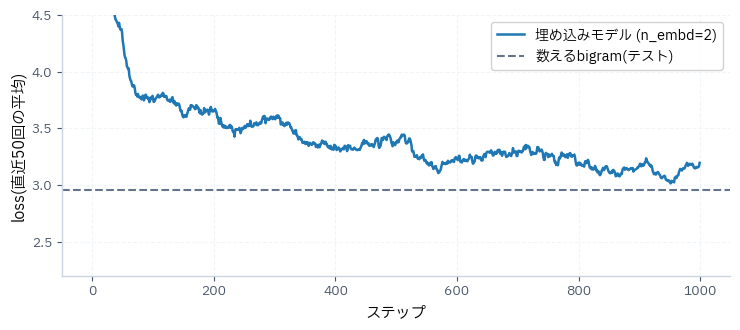

In [56]:
random.seed(0)
n_embd = 2
emb_state = {'wte': matrix(vocab_size, n_embd, std=1.0),   # 2成分と小さいので，最初の値を少し大きめにしているよ
             'lm_head': matrix(vocab_size, n_embd, std=1.0)}
emb_params = all_params(emb_state)
print('パラメーター数:', len(emb_params))

def emb_model(tokens):
    logits_list = []
    for token in tokens:
        x = emb_state['wte'][token]                           # 1. 埋め込み
        logits_list.append(linear(x, emb_state['lm_head']))   # 2. 線形変換でスコアに
    return logits_list

emb_history = train_sgd(emb_model, emb_params, num_steps=1000, learning_rate=2.0)
print(f'テストloss: {test_loss(emb_model):.4f}')
print('作った名前:', ' '.join(generate(emb_model, 12)))
plot_history({'埋め込みモデル (n_embd=2)': emb_history})

lossは下がりましたが，作った名前は1文字のものが多く，まだあまり名前らしくありません。成分が2つだけでは，文字の違いを表すのに足りないのです。
それでも，学習した埋め込みベクトルを平面上に描いてみると面白いことがわかります。各文字が，学習で決まった2成分のベクトルの位置に置かれます。
> The loss went down, but many of the names it makes are only one character long, so they do not look much like names yet. Just 2 components are not enough to express the differences between characters.
Still, drawing the learned embedding vectors on a plane shows something interesting. Each character is placed at the position of its learned 2-component vector.

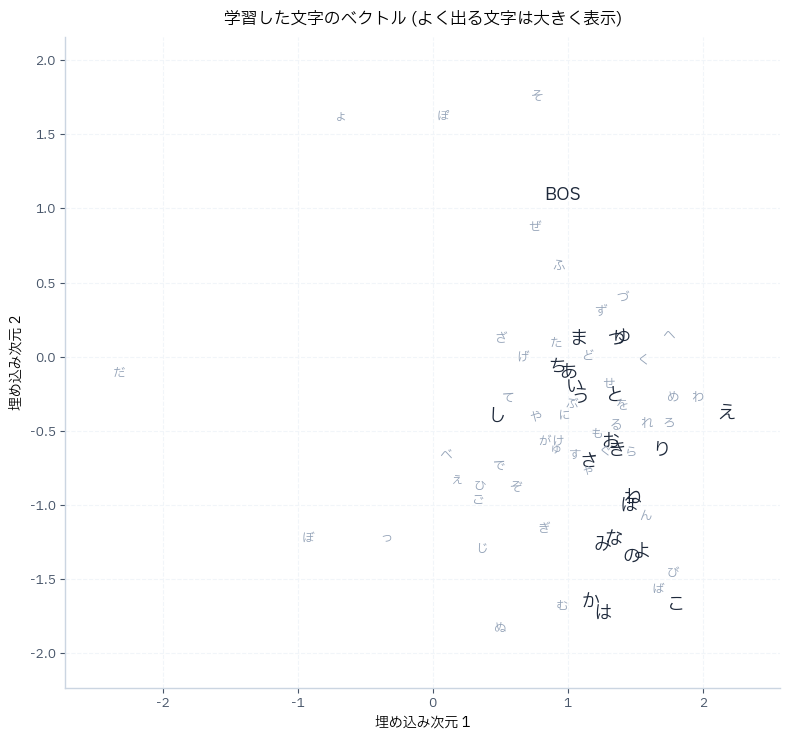

In [57]:
#@title 学習した埋め込みベクトル { display-mode: "form" }
fig, ax = plt.subplots(figsize=(8, 7.5))
for i in range(vocab_size):
    x, y = emb_state['wte'][i][0].data, emb_state['wte'][i][1].data
    big = sum(counts[i]) > 150
    ax.text(x, y, tok_str(i), fontsize=13 if big else 9, ha='center', va='center',
            color='#1e293b' if big else '#94a3b8', fontweight='bold' if big else 'normal')
xs = [r[0].data for r in emb_state['wte']]; ys = [r[1].data for r in emb_state['wte']]
ax.set_xlim(min(xs) - 0.4, max(xs) + 0.4); ax.set_ylim(min(ys) - 0.4, max(ys) + 0.4)
ax.set_title('学習した文字のベクトル (よく出る文字は大きく表示)', fontsize=12, fontweight='bold')
ax.set_xlabel('埋め込み次元 1', fontsize=10)
ax.set_ylabel('埋め込み次元 2', fontsize=10)
plt.tight_layout()
plt.show()

よく出てくる文字どうしで，近くに集まっているものがあるか探してみましょう。
このモデルでは，近くにある文字は「次に来る文字の傾向」が似ています。どの文字が近くに来るかは，学習をやり直すと変わります。
> Look for frequent characters that are gathered close together.
In this model, characters that are close have similar "tendencies for the next character". Which characters end up close changes if you train again.

**でも，このモデルもまだ直前の1文字しか見ていません。** テストlossは数えるbigramモデルと同じくらいか，それより悪いはずです。
しかも成分が2つだけでは，72種類の文字の違いを十分に表せません。0.1のGPTのように `n_embd = 16` にして，さらに次の章で「ニューラルネットワーク」らしい仕組みを加えていきます。
> **But this model still only looks at the one previous character.** Its test loss should be about the same as the counting bigram model, or worse.
Also, just 2 components are not enough to express the differences among 72 characters. In the next chapter, we use `n_embd = 16` like the GPT in 0.1, and add a mechanism that is more like a real "neural network".

## 6.7 0.1のコードとの対応 - Matching with the code in 0.1

```python
matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
state_dict = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd), 'lm_head': matrix(vocab_size, n_embd)}
def linear(x, w): ...                      # 6.5 線形変換だよ
tok_emb = state_dict['wte'][token_id]      # 6.4 埋め込みだよ
logits = linear(x, state_dict['lm_head'])  # 6.6 スコアに変換するよ
```

## 練習問題 - Exercises

1. $\vec{a} = (1, 2)$，$\vec{b} = (4, -2)$ の内積を求めましょう。2つのベクトルのなす角は何度でしょうか？
2. $\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$ でベクトル $(x, y)$ を変換すると，どうなるでしょうか？
3. `emb_model` のパラメーター数が288個になる理由を説明してみましょう。

<details><summary>答え - Answers</summary>

1. $1 \times 4 + 2 \times (-2) = 0$ です。内積が0なので，なす角は90°(直角)です。
2. $(1 \cdot x + 0 \cdot y,\ 0 \cdot x + 1 \cdot y) = (x, y)$ で，何も変わりません(このような行列を単位行列といいます)。
3. `wte` が $72 \times 2 = 144$ 個，`lm_head` が $72 \times 2 = 144$ 個で，合計288個です。
</details>

---
# 第7章 ニューラルネットワーク: MLPとReLU - Chapter 7: Neural networks: MLP and ReLU

第6章のモデルは「埋め込み → 線形変換」だけでした。
この章では，線形変換と **ReLU** という簡単な関数を組み合わせて，もっと複雑な関係を表せる **MLP(多層パーセプトロン)** を作ります。
0.1のコードの `# 2) MLP block` の部分です。
> The model in Chapter 6 was just "embedding → linear transformation".
In this chapter, we combine linear transformations with a simple function called **ReLU** to build an **MLP (multi-layer perceptron)**, which can express more complex relationships.
This is the `# 2) MLP block` part of the code in 0.1.

**この章で使う数学**: 一次関数，関数の合成，グラフ(数学I)
> **Math in this chapter**: linear functions, composition of functions, graphs (Math I)

## 7.1 線形変換を重ねても線形変換 - Stacking linear transformations gives a linear transformation

線形変換を2回重ねれば，もっと複雑なことができそうです。でも，実はそうはなりません。
1つの数で考えると，一次関数 $y = 2x + 1$ に，さらに一次関数 $z = 3y - 4$ を重ねても
> Stacking two linear transformations seems like it could do more complex things. But in fact it does not.
Think with single numbers: if we apply $z = 3y - 4$ after $y = 2x + 1$,

$$z = 3(2x + 1) - 4 = 6x - 1$$

となり，結局ただの一次関数です。**直線をいくつ重ねても直線** なのです。ベクトルと行列でも同じことが言えます。
> it is still just a linear function. **No matter how many straight lines you stack, you get a straight line.** The same is true for vectors and matrices.

曲がったグラフを表すには，**直線ではない関数** を間にはさむ必要があります。
> To express curved graphs, we need to insert **a function that is not a straight line** in between.

## 7.2 ReLU: 折れ線の関数 - ReLU: a bent-line function

**ReLU(Rectified Linear Unit)** は，一番シンプルな「直線ではない関数」です。
> **ReLU (Rectified Linear Unit)** is the simplest "function that is not a straight line":

$$\text{ReLU}(x) = \max(0, x) = \begin{cases} x & (x > 0) \\ 0 & (x \le 0) \end{cases}$$

マイナスは0にして，プラスはそのまま通す，というだけです。グラフは原点で折れ曲がった折れ線になります。
傾きは，$x > 0$ なら1，$x < 0$ なら0です(第5章の `Value.relu` の局所的な傾き `float(self.data > 0)` はこれです)。
> It just turns negatives into 0 and lets positives through. The graph is a line bent at the origin.
The slope is 1 when $x > 0$ and 0 when $x < 0$ (this is the local slope `float(self.data > 0)` in `Value.relu` from Chapter 5).

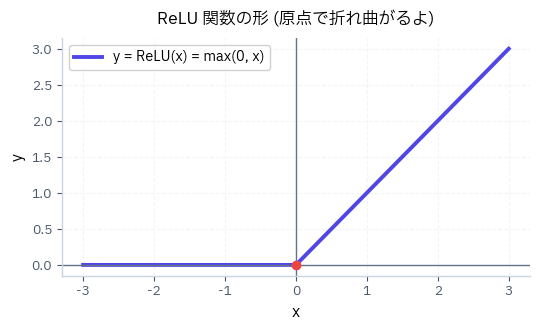

In [58]:
#@title ReLU関数のグラフ { display-mode: "form" }
xs = [i / 10 for i in range(-30, 31)]
ys = [max(0, x) for x in xs]
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.plot(xs, ys, lw=2.8, color='#4f46e5', label='y = ReLU(x) = max(0, x)')
ax.axhline(0, color='#64748b', lw=1.0)
ax.axvline(0, color='#64748b', lw=1.0)
ax.plot([0], [0], 'o', color='#ef4444', ms=6)
ax.set_title('ReLU 関数の形 (原点で折れ曲がるよ)', fontsize=12, fontweight='bold')
ax.set_xlabel('x', fontsize=11); ax.set_ylabel('y', fontsize=11)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

## 7.3 折れ線を足し合わせると，どんな形でも作れる - Adding bent lines can make any shape

ReLUをずらしたり，傾きを変えたりしたものをいくつも足し合わせると，**いろいろな形の折れ線** が作れます。
折れ曲がる点を増やしていけば，曲線にもどんどん近づけられます。
> By shifting ReLUs, changing their slopes and adding many of them together, we can make **bent lines of many shapes**.
With more bending points, we can get closer and closer to any curve.

### [アニメーション] ReLUを足して放物線を作る - [Animation] Making a parabola by adding ReLUs

In [59]:
#@title アニメーション: ReLUの足し合わせ { display-mode: "form" }
def make_scene(mn, T):
    class ReluSum(mn.Scene):
        def construct(self):
            relu = lambda x: max(0.0, x)
            ax = mn.Axes(x_range=[-2.5, 2.5, 1], y_range=[-0.5, 5, 1], x_length=7, y_length=5, tips=False).shift(mn.LEFT * 2 + mn.DOWN * 0.3)
            target = ax.plot(lambda x: x**2, x_range=[-2.2, 2.2], color=mn.GRAY, stroke_width=3).set_stroke(opacity=0.6)
            title = T('ReLU を足し合わせて y = x² に近づける', font_size=32).to_edge(mn.UP)
            self.play(mn.Write(title), mn.Create(ax), mn.Create(target))
            terms = [('4 − 3(x+2)', lambda x: 4 - 3 * (x + 2)),
                     ('+ 2·ReLU(x+1)', lambda x: 2 * relu(x + 1)),
                     ('+ 2·ReLU(x)', lambda x: 2 * relu(x)),
                     ('+ 2·ReLU(x−1)', lambda x: 2 * relu(x - 1))]
            fs, labels = [], mn.VGroup()
            graph = None
            for i, (text, fn) in enumerate(terms):
                fs.append(fn)
                cur = list(fs)
                g = ax.plot(lambda x: sum(f(x) for f in cur), x_range=[-2.2, 2.2], color=mn.YELLOW, stroke_width=5)
                lab = T(text, font_size=28, color=mn.YELLOW if i == 0 else mn.BLUE)
                labels.add(lab); labels.arrange(mn.DOWN, aligned_edge=mn.LEFT).to_edge(mn.RIGHT).shift(mn.LEFT * 0.3)
                if graph is None:
                    graph = g
                    self.play(mn.Create(graph), mn.FadeIn(lab))
                else:
                    self.play(mn.Transform(graph, g), mn.FadeIn(lab), run_time=1.2)
                self.wait(0.4)
            note = T('折れ曲がる点を増やすほど，曲線に近づくよ', font_size=26).to_edge(mn.DOWN)
            self.play(mn.Write(note))
            self.wait(1.5)
    return ReluSum

show_anim(make_scene)

### [スライダー] ReLUを組み合わせて，グレーの曲線に合わせよう - [Slider] Combine ReLUs to match the gray curve

3つのReLUの **傾き $w$** と **折れ曲がる位置 $k$**，全体の **高さ $b$** を動かして，黄色の折れ線をグレーの曲線にできるだけ近づけてみましょう。
右上の「ずれ」(平均二乗誤差: ずれの2乗の平均)が小さいほど上手です。0.02を切れたら上級者！
> Move the **slope $w$** and **bending position $k$** of the three ReLUs and the overall **height $b$** to make the yellow line as close as possible to the gray curve.
The smaller the "error" (mean squared error: the average of the squared differences) at the top right, the better. Below 0.02 and you are an expert!

$$y = b + w_1\,\text{ReLU}(x - k_1) + w_2\,\text{ReLU}(x - k_2) + w_3\,\text{ReLU}(x - k_3)$$

> 実は，この「ずれを小さくするように $w$，$k$，$b$ を調整する」作業こそ，コンピューターが勾配降下法で自動でやっていることです。
> In fact, this task of "adjusting $w$, $k$ and $b$ to make the error small" is exactly what the computer does automatically with gradient descent.

In [60]:
#@title [スライダー] ReLUフィッティングゲーム { display-mode: "form" }
def relu_game(b=0.0, w1=0.5, k1=-1.0, w2=0.5, k2=0.0, w3=0.5, k3=1.0):
    target = lambda x: max(0.0, x) ** 2 / 2
    xs = [i / 20 for i in range(-60, 61)]
    ys = [b + w1 * max(0, x - k1) + w2 * max(0, x - k2) + w3 * max(0, x - k3) for x in xs]
    err = sum((y - target(x)) ** 2 for x, y in zip(xs, ys)) / len(xs)
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    ax.plot(xs, [target(x) for x in xs], color='#94a3b8', lw=7, alpha=0.5, label='目標の曲線')
    ax.plot(xs, ys, color='#f59e0b', lw=2.5, label='3つのReLUの合成')
    for k in (k1, k2, k3): ax.axvline(k, color='#3b82f6', ls=':', alpha=0.6)
    ax.set_xlim(-3, 3); ax.set_ylim(-1, 5)
    ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    badge = '  (素晴らしい！クリア！)' if err < 0.02 else ''
    ax.set_title(f'目標とのずれ(平均二乗誤差) = {err:.4f}{badge}', fontsize=12, fontweight='bold',
                 color='#15803d' if err < 0.02 else '#1e293b')
    plt.tight_layout()
    plt.show()

w = lambda v, d: widgets.FloatSlider(value=v, min=-3, max=3, step=0.05, description=d)
interact(relu_game, b=w(0.0, '底上げ b:'), w1=w(0.5, '傾き w1:'), k1=w(-1.0, '位置 k1:'),
         w2=w(0.5, '傾き w2:'), k2=w(0.0, '位置 k2:'), w3=w(0.5, '傾き w3:'), k3=w(1.0, '位置 k3:'));

<details><summary>ヒント - Hint</summary>

目標の曲線は，$x < 0$ では0，$x > 0$ ではだんだん急になっていきます。
$k_1 = 0$ から始めて，右に行くほど傾きが増えるように，$k_2$，$k_3$ で傾きを足していきましょう。
例えば $b = 0,\ w_1 = 0.5,\ k_1 = 0.1,\ w_2 = 1,\ k_2 = 1,\ w_3 = 1,\ k_3 = 2$ あたりから調整してみてください。
> The target is 0 for $x < 0$ and gets steeper for $x > 0$.
Start from $k_1 = 0$ and add slope with $k_2$ and $k_3$ so the slope increases to the right.
</details>

## 7.4 MLP: 広げて，ReLU，縮める - MLP: expand, ReLU, shrink

0.1のコードのMLPは，次の3ステップです。
> The MLP in 0.1 has these 3 steps:

1. 線形変換 `mlp_fc1` で，16成分のベクトルを **64成分に広げる**(64行の行列)
2. 64個それぞれに **ReLU** をかける
3. 線形変換 `mlp_fc2` で，**16成分に縮める**
> 1. The linear transformation `mlp_fc1` **expands** the 16-component vector **to 64 components** (a 64-row matrix).
> 2. Apply **ReLU** to each of the 64.
> 3. The linear transformation `mlp_fc2` **shrinks it back to 16 components**.

`mlp_fc1` の64個の行は，それぞれが「ある特徴を調べる物差し」です(第6章)。
内積がプラスなら(その特徴が当てはまるなら)ReLUを通り，マイナスなら0になります。
つまり64個の「特徴を見つけたら反応するセンサー」のようなもので，その反応を組み合わせて次の計算に渡すのです。
> Each of the 64 rows of `mlp_fc1` is "a ruler that checks for a certain feature" (Chapter 6).
If the dot product is positive (the feature applies), it passes through ReLU; if negative, it becomes 0.
So it is like 64 "sensors that react when they find a feature", and their reactions are combined and passed to the next step.

## 7.5 実装: MLPを加えたモデル - Implementation: a model with an MLP

第6章のモデルにMLPを加えて，`n_embd = 16` で学習させてみます。**1〜2分かかります。**
> Let's add an MLP to the model from Chapter 6 and train it with `n_embd = 16`. **It takes 1–2 minutes.**

パラメーター数: 4352
step 1000 / 1000 | 直近100回の平均loss: 3.0949
テストloss: 3.0959  (数えるbigram: 2.9535)
作った名前: み き さ まみ じ こ ふぽさ り み は な あも


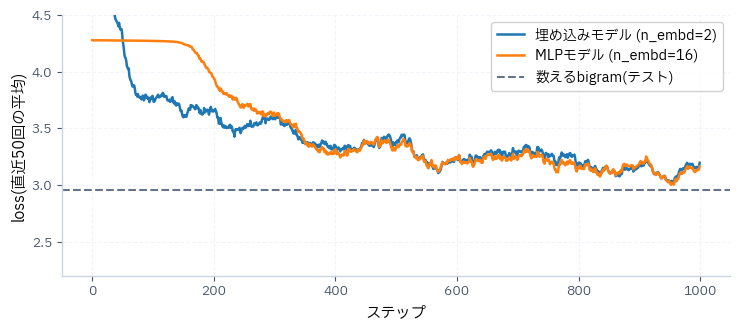

In [61]:
random.seed(0)
n_embd = 16
mlp_state = {'wte': matrix(vocab_size, n_embd),
             'mlp_fc1': matrix(4 * n_embd, n_embd),   # 16次元 → 64次元に広げるよ
             'mlp_fc2': matrix(n_embd, 4 * n_embd),   # 64次元 → 16次元に縮めるよ
             'lm_head': matrix(vocab_size, n_embd)}
mlp_params = all_params(mlp_state)
print('パラメーター数:', len(mlp_params))

def mlp_model(tokens):
    logits_list = []
    for token in tokens:
        x = mlp_state['wte'][token]
        x = linear(x, mlp_state['mlp_fc1'])   # 1. 広げる
        x = [xi.relu() for xi in x]           # 2. ReLU
        x = linear(x, mlp_state['mlp_fc2'])   # 3. 縮める
        logits_list.append(linear(x, mlp_state['lm_head']))
    return logits_list

mlp_history = train_sgd(mlp_model, mlp_params, num_steps=1000, learning_rate=0.5)
print(f'テストloss: {test_loss(mlp_model):.4f}  (数えるbigram: {BIGRAM_TEST_LOSS:.4f})')
print('作った名前:', ' '.join(generate(mlp_model, 12)))
plot_history({'埋め込みモデル (n_embd=2)': emb_history, 'MLPモデル (n_embd=16)': mlp_history})

作った名前はまだ1文字のものが多く，テストlossも数えるbigramモデルに届いていません。
どんなに複雑な計算をしても，**入力が直前の1文字だけ** なら，第2章の「数える」方法以上のことはほとんどできないのです。
> Many of the names it makes are still one character long, and the test loss has not reached the counting bigram model.
No matter how complex the calculation, if **the only input is the one previous character**, it can hardly do better than the "counting" method in Chapter 2.

> **学習率について**: この学習では学習率を0.5にしています。試しに2や3にすると，途中でlossが爆発して `math domain error` というエラーで止まってしまいます(確率が0になって $\log 0$ を計算しようとするため)。
> この「学習が不安定になる」問題は，第9章と第10章で解決します。
> **About the learning rate**: We use a learning rate of 0.5 here. If you try 2 or 3, the loss explodes partway and training stops with a `math domain error` (the probability becomes 0 and it tries to calculate $\log 0$).
> We will solve this "unstable training" problem in Chapters 9 and 10.

いよいよ次の章で，**前の文字をすべて見る** 仕組み，Attentionを作ります。
> In the next chapter, we finally build Attention, the mechanism that **looks at all the previous characters**.

## 7.6 0.1のコードとの対応 - Matching with the code in 0.1

```python
# 2) MLP block
x_residual = x                                  # 第9章で解説するよ
x = rmsnorm(x)                                  # 第9章で解説するよ
x = linear(x, state_dict[f'layer{li}.mlp_fc1'])  # 7.4 広げるよ
x = [xi.relu() for xi in x]                     # 7.2 ReLUだよ
x = linear(x, state_dict[f'layer{li}.mlp_fc2'])  # 7.4 縮めるよ
x = [a + b for a, b in zip(x, x_residual)]      # 第9章で解説するよ
```

## 練習問題 - Exercises

1. $\text{ReLU}(3)$，$\text{ReLU}(-2)$，$\text{ReLU}(0)$ の値はいくつでしょうか？
2. $y = \text{ReLU}(x) - \text{ReLU}(x - 1)$ のグラフを描いてみましょう(スライダーで $w_1 = 1, k_1 = 0, w_2 = -1, k_2 = 1, w_3 = 0$ にすると確かめられます)。
3. `mlp_model` のパラメーター数が4352個になることを確かめてみましょう。

<details><summary>答え - Answers</summary>

1. 3，0，0 です。
2. $x \le 0$ で0，$0 \le x \le 1$ で $y = x$，$x \ge 1$ で1になる「階段のような」折れ線です。
3. `wte` $72 \times 16 = 1152$，`mlp_fc1` $64 \times 16 = 1024$，`mlp_fc2` $16 \times 64 = 1024$，`lm_head` $72 \times 16 = 1152$ です。合計4352個になります。
</details>

---
# 第8章 前の文字に注目する: Attention - Chapter 8: Paying attention to previous characters

ここまでのモデルは，どれも **直前の1文字しか見ていません** でした。
この章では，**それまでのすべての文字の中から，今どれに注目すべきかを自分で決める** 仕組み，**Attention(アテンション，注意機構)** を作ります。
AttentionはGPTの心臓部であり，ChatGPTなどが長い文章を理解できるのもこの仕組みのおかげです。
> All our models so far **only looked at the one previous character**.
In this chapter, we build **Attention**, a mechanism that **decides by itself which of all the previous characters to focus on**.
Attention is the heart of GPT, and it is thanks to this mechanism that ChatGPT and others can understand long texts.

**この章で使う数学**: 内積(第6章)，softmax(第3章)，加重平均(数学I「データの分析」の平均の発展)
> **Math in this chapter**: dot product (Chapter 6), softmax (Chapter 3), weighted average (an extension of the average in Math I)

## 8.1 前の文字をすべて使いたい - We want to use all the previous characters

「ゆ」の次に来る文字を予想するとき，それが名前の1文字目の「ゆ」なのか(「ゆき」「ゆみ」…)，「まゆ」「あゆ」のように2文字目の「ゆ」なのかで，答えは変わるはずです(2文字目なら，そこで名前が終わることも多いでしょう)。
前の文字を全部使いたいのですが，名前によって文字数が違います。文字数が変わっても使える方法が必要です。
> When predicting the character after "ゆ", the answer should depend on whether it is the first character of the name ("ゆき", "ゆみ", ...) or the second, as in "まゆ" or "あゆ" (then the name often ends there).
We want to use all the previous characters, but names have different lengths. We need a method that works for any length.

アイデアは，**前の文字のベクトルの「平均」をとる** ことです。平均なら，何個あっても1つのベクトルにまとめられます。
ただし，ただの平均ではなく，**大事な文字ほど重くした平均** にします。
> The idea is to **take the "average" of the vectors of the previous characters**. An average can combine any number of vectors into one.
But instead of a plain average, we use **an average where more important characters count more**.

## 8.2 加重平均 - Weighted average

小テストを3回受けて，60点，80点，90点だったとします。普通の平均は $\frac{60 + 80 + 90}{3} \approx 76.7$ 点です。
これは，3回それぞれに $\frac13$ ずつの **重み** をつけて足したものと同じです。
> Suppose you took 3 quizzes and scored 60, 80 and 90. The plain average is $\frac{60 + 80 + 90}{3} \approx 76.7$.
This is the same as giving each quiz a **weight** of $\frac13$ and adding them up.

もし「最近のテストほど大事」として，重みを $0.2,\ 0.3,\ 0.5$ にすると
> If "more recent quizzes are more important" and we use weights $0.2,\ 0.3,\ 0.5$:

$$0.2 \times 60 + 0.3 \times 80 + 0.5 \times 90 = 81 \text{ 点}$$

これを **加重平均** といいます。**重みはすべて0以上で，合計が1** になるようにします。
…この条件，どこかで見ましたね？ そう，**softmaxの出力** です(第3章)。
> This is called a **weighted average**. **All weights are 0 or more, and they add up to 1.**
...Have you seen these conditions before? Yes, they are **the output of softmax** (Chapter 3).

## 8.3 Query・Key・Value: 図書館で本を探す - Query, Key, Value: finding books in a library

では，重み(どの文字にどれくらい注目するか)はどうやって決めるのでしょう？ Attentionは，図書館で本を探すのに似た方法を使います。
> Then how do we decide the weights (how much to focus on each character)? Attention uses a method similar to finding books in a library.

| 名前 | 図書館でいうと | 役割 |
|---|---|---|
| **Query(クエリ)** $q$ | 探している本の条件(検索ワード) | 今の文字が「どんな情報を探しているか」 |
| **Key(キー)** $k$ | 本の背表紙のラベル | それぞれの文字が「どんな情報を持っているか」の見出し |
| **Value(バリュー)** $v$ | 本の中身 | それぞれの文字が実際に渡す情報 |

手順は次のとおりです。
> The steps are:

1. 各文字のベクトル $x$ から，線形変換(第6章)で $q$，$k$，$v$ の3つのベクトルを作る
2. 今の文字の $q$ と，前の各文字の $k$ の **内積** を計算する。内積は「似ている度合い」なので(第6章)，探している条件に合う文字ほどスコアが大きくなる
3. スコアを **softmax** で重みに変える(合計1)
4. 各文字の $v$ を，その重みで **加重平均** する
> 1. From each character's vector $x$, make three vectors $q$, $k$ and $v$ with linear transformations (Chapter 6).
> 2. Calculate the **dot product** of the current character's $q$ with each previous character's $k$. Since the dot product means "how similar" (Chapter 6), characters that match what we are looking for get larger scores.
> 3. Turn the scores into weights with **softmax** (they add up to 1).
> 4. Take the **weighted average** of each character's $v$ with those weights.

$$\text{出力} = \sum_{t} (\text{重み})_t \, v_t, \qquad (\text{重み})_t = \text{softmax}\!\left(\frac{q \cdot k_t}{\sqrt{d}}\right)$$

$\sqrt{d}$ で割る理由は8.5で説明します。
> We explain why we divide by $\sqrt{d}$ in 8.5.

### [アニメーション] Attentionの流れ - [Animation] How Attention works

In [62]:
#@title アニメーション: Attention { display-mode: "form" }
def make_scene(mn, T):
    class AttentionScene(mn.Scene):
        def construct(self):
            title = T('Attention: どの文字に注目する？', font_size=34).to_edge(mn.UP)
            self.play(mn.Write(title))
            words = ['BOS', 'は', 'な']
            weights = [0.1, 0.65, 0.25]
            vals = [[0.2, -0.5, 0.1], [0.9, 0.4, -0.3], [-0.2, 0.7, 0.5]]
            boxes = mn.VGroup(*[mn.VGroup(mn.RoundedRectangle(width=1.4, height=0.9, corner_radius=0.15, color=mn.BLUE), T(w, font_size=26 if w == 'BOS' else 36)) for w in words]).arrange(mn.RIGHT, buff=1.2).shift(mn.UP * 1.6 + mn.LEFT * 2.8)
            for g in boxes: g[1].move_to(g[0])
            self.play(mn.FadeIn(boxes))
            q = mn.VGroup(T('Query: 「な」の次に', font_size=24, color=mn.YELLOW), T('来る文字を知りたい', font_size=24, color=mn.YELLOW)).arrange(mn.DOWN, aligned_edge=mn.LEFT).next_to(boxes[-1], mn.RIGHT, buff=0.4)
            self.play(mn.Indicate(boxes[-1], color=mn.YELLOW), mn.FadeIn(q))
            arcs = []
            for b, w in zip(boxes, weights):
                if b is boxes[-1]:
                    arc = mn.Circle(0.25, color=mn.YELLOW, stroke_width=2 + 12 * w).next_to(b, mn.DOWN, buff=0.1)
                else:
                    arc = mn.CurvedArrow(boxes[-1].get_bottom() + mn.DOWN * 0.1, b.get_bottom() + mn.DOWN * 0.1, angle=-mn.PI / 2, color=mn.YELLOW, stroke_width=2 + 12 * w)
                arcs.append(arc)
            lab = T('q と各 k の内積 → softmax → 重み', font_size=24).to_edge(mn.DOWN)
            self.play(*[mn.Create(a) for a in arcs], mn.FadeIn(lab))
            wl = mn.VGroup(*[T(f'{w:.2f}', font_size=28, color=mn.YELLOW).next_to(b, mn.UP, buff=0.15) for b, w in zip(boxes, weights)])
            self.play(mn.FadeIn(wl))
            def bars(v, color, scale=1.0):
                g = mn.VGroup()
                for i, e in enumerate(v):
                    h = abs(e) * scale + 0.02
                    r = mn.Rectangle(width=0.25, height=h, fill_color=color, fill_opacity=0.9, stroke_width=0)
                    r.move_to([i * 0.32, (h / 2 if e >= 0 else -h / 2), 0])
                    g.add(r)
                return g
            vb = [bars(v, mn.GREEN).move_to(b.get_center() + mn.DOWN * 3.0) for v, b in zip(vals, boxes)]
            vlabs = mn.VGroup(*[T(f'Value({w})', font_size=20, color=mn.GREEN).next_to(v, mn.DOWN, buff=0.15) for v, w in zip(vb, words)])
            self.play(*[mn.FadeIn(v) for v in vb], mn.FadeIn(vlabs))
            out = [sum(w * v[j] for w, v in zip(weights, vals)) for j in range(3)]
            ob = bars(out, mn.ORANGE).move_to(mn.RIGHT * 4.3 + mn.DOWN * 1.4)
            olab = T('出力 = 重みつき平均', font_size=24, color=mn.ORANGE).next_to(ob, mn.UP, buff=0.4)
            calc = T('0.10×BOS + 0.65×は + 0.25×な', font_size=20, color=mn.ORANGE).next_to(ob, mn.DOWN, buff=0.4)
            copies = [v.copy() for v in vb]
            self.play(*[c.animate.move_to(ob).set_opacity(0.4) for c in copies], mn.FadeIn(olab), run_time=1.5)
            self.play(*[mn.FadeOut(c) for c in copies], mn.FadeIn(ob), mn.FadeIn(calc))
            self.wait(2)
    return AttentionScene

show_anim(make_scene)

### 小さな例で計算してみよう - Let's calculate a small example

ベクトルが2成分の小さな例で，Attentionの計算を1ステップずつやってみます。
> Let's do the Attention calculation step by step with a small example where vectors have 2 components.

In [63]:
q = [1.0, 0.5]                                # 今の文字のQueryだよ
keys_toy = [[0.2, -1.0], [1.0, 0.8], [-0.5, 0.3]]  # 3つの文字のKeyだよ
values_toy = [[1.0, 0.0], [0.0, 1.0], [0.5, 0.5]]  # 3つの文字のValueだよ
d = len(q)

scores = [sum(qi * ki for qi, ki in zip(q, k)) / d**0.5 for k in keys_toy]  # 2. 内積(÷√d)
weights = softmax_numbers(scores)                                            # 3. softmax
output = [sum(w * v[j] for w, v in zip(weights, values_toy)) for j in range(d)]  # 4. 加重平均
print('スコア:', [round(s, 3) for s in scores])
print('重み  :', [round(w, 3) for w in weights], ' 合計', round(sum(weights), 3))
print('出力  :', [round(o, 3) for o in output])

スコア: [-0.212, 0.99, -0.247]
重み  : [0.189, 0.629, 0.182]  合計 1.0
出力  : [0.28, 0.72]


$q$ と一番似ている(同じ向きの)2つ目のKeyに，一番大きな重みがつきました。出力も2つ目のValue $(0, 1)$ に近くなっています。
> The second key, which is the most similar to $q$ (points in the same direction), got the largest weight. The output is also close to the second value $(0, 1)$.

### [スライダー] Queryの向きを変えて，注目先が変わる様子を見よう - [Slider] Change the query's direction and watch the focus change

Queryの向きを回すと，一番似ているKeyが変わり，重みが移っていきます。Queryを長くすると内積が大きくなり，softmaxの結果がはっきり(1つに集中)します。
> As you rotate the query, the most similar key changes and the weights shift. Making the query longer makes the dot products larger, so the softmax result becomes sharper (focused on one).

In [64]:
#@title [スライダー] QueryとKeyの内積 → 重み { display-mode: "form" }
def plot_query(angle=30, length=1.5):
    qv = [length * math.cos(math.radians(angle)), length * math.sin(math.radians(angle))]
    ks = [[1.5, 0.3], [-0.4, 1.4], [-1.2, -0.9]]
    names, colors = ['Key 1', 'Key 2', 'Key 3'], ['#3b82f6', '#10b981', '#8b5cf6']
    sc = [sum(a * b for a, b in zip(qv, k)) / math.sqrt(2) for k in ks]
    w = softmax_numbers(sc)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.0))
    for k, n, c in zip(ks, names, colors):
        ax1.annotate('', xy=k, xytext=(0, 0), arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
        ax1.text(k[0] * 1.15, k[1] * 1.15, n, color=c, fontweight='bold')
    ax1.annotate('', xy=qv, xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='#ef4444', lw=3.2))
    ax1.set_xlim(-4, 4); ax1.set_ylim(-4, 4); ax1.set_aspect('equal')
    ax1.set_title('Query と Key のベクトル配置', fontsize=12, fontweight='bold')

    bars = ax2.bar(names, w, color=colors, edgecolor='#1e293b', width=0.55)
    ax2.set_ylim(0, 1.15)
    ax2.set_title('各Keyへの注目度 (softmax後の重み)', fontsize=12, fontweight='bold')
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.03, f'{h:.2f}', ha='center', fontsize=9.5, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(plot_query, angle=widgets.IntSlider(value=30, min=0, max=360, step=5, description='向き:'),
         length=widgets.FloatSlider(value=1.5, min=0.1, max=4, step=0.1, description='長さ:'));

## 8.4 何文字目かを教える: 位置埋め込み - Telling the position: position embeddings

Attentionは加重平均なので，**文字の順番を区別できません**。「はな」と「なは」で，同じ文字の集まりなら同じ結果になってしまいます。
そこで，第6章で紹介した **位置埋め込み `wpe`** を使います。「0文字目」「1文字目」…にもそれぞれベクトルを用意して，文字のベクトルに **足し算** します。
こうすれば，同じ「な」でも，1文字目の「な」と2文字目の「な」は違うベクトルになります。
> Because Attention is a weighted average, **it cannot tell the order of characters**. "はな" and "なは" would give the same result, since they have the same characters.
So we use the **position embedding `wpe`** introduced in Chapter 6. We prepare a vector for "position 0", "position 1", ..., and **add** it to the character's vector.
This way, the same "な" gets a different vector at position 1 and at position 2.

```python
tok_emb = state_dict['wte'][token_id]  # 文字のベクトルだよ
pos_emb = state_dict['wpe'][pos_id]    # 位置のベクトルだよ
x = [t + p for t, p in zip(tok_emb, pos_emb)]  # 足し算するよ
```

## 8.5 √d で割る理由 - Why divide by √d

ベクトルの成分が多いほど，内積は多くの数の足し算になるので，値が大きくなりがちです。
スコアが大きすぎるとsoftmaxの結果が1つに集中しすぎてしまいます(スライダーでQueryを長くしたときと同じです)。
そこで，成分の数 $d$ の平方根 $\sqrt{d}$ で割って，スコアの大きさをそろえます。
これは第3章の **temperature を $T = \sqrt{d}$ にしている** のと同じことです。
> The more components a vector has, the more numbers are added in the dot product, so the value tends to be larger.
If the scores are too large, the softmax result concentrates too much on one (the same as making the query longer with the slider).
So we divide by $\sqrt{d}$, the square root of the number of components $d$, to keep the scores at a similar size.
This is the same as **setting the temperature from Chapter 3 to $T = \sqrt{d}$**.

## 8.6 未来の文字は見ない - Do not look at future characters

学習のとき，モデルは「次の文字」を予想します。もし次の文字そのものを見られたら，カンニングになってしまいます。
0.1のコードでは，1文字ずつ順番に処理しながら，**それまでに出てきた文字のKeyとValueだけ** を `keys` と `values` に追加していきます。
だから，Attentionは自然に「今と過去の文字」だけを見るようになっています。
> During training, the model predicts "the next character". If it could see the next character itself, that would be cheating.
In 0.1, the characters are processed one by one, and **only the keys and values of the characters seen so far** are added to `keys` and `values`.
So Attention naturally looks only at "the current and past characters".

## 8.7 マルチヘッド: いくつもの視点で注目する - Multi-head: attention from several viewpoints

0.1のコードでは `n_head = 4` で，16成分のベクトルを4成分ずつ **4つに分けて**，それぞれで別々にAttentionを計算しています。これを **マルチヘッドAttention** といいます。
例えば「1つ目のヘッドは直前の文字に注目」「2つ目のヘッドは最初の文字に注目」のように，**それぞれのヘッドが違う視点で注目できる** のです(どのヘッドが何に注目するかは，学習で自然に決まります)。
最後に4つの結果をつなげて，線形変換 `attn_wo` で混ぜ合わせます。
> In 0.1, `n_head = 4`: the 16-component vector is **split into 4 parts** of 4 components each, and Attention is calculated separately for each. This is called **multi-head Attention**.
For example, "head 1 focuses on the previous character" and "head 2 focuses on the first character": **each head can focus from a different viewpoint** (what each head focuses on is decided naturally by learning).
Finally, the 4 results are joined and mixed with the linear transformation `attn_wo`.

## 8.8 実装: Attentionを使ったモデル - Implementation: a model with Attention

0.1のコードとほぼ同じAttentionを実装して学習させます。**1〜2分かかります。**
あとで「どこに注目したか」を図にするために，重みを記録できるようにしておきます(`record`)。
> Let's implement Attention almost exactly as in 0.1 and train it. **It takes 1–2 minutes.**
We make it possible to record the weights (`record`) so we can draw "where it focused" later.

パラメーター数: 3424
step 1000 / 1000 | 直近100回の平均loss: 2.7984
テストloss: 2.8099  (数えるbigram: 2.9535)
作った名前: みみ えな みき ちよ かみ えよ みりさ やほ あしよ りし えみ あほ


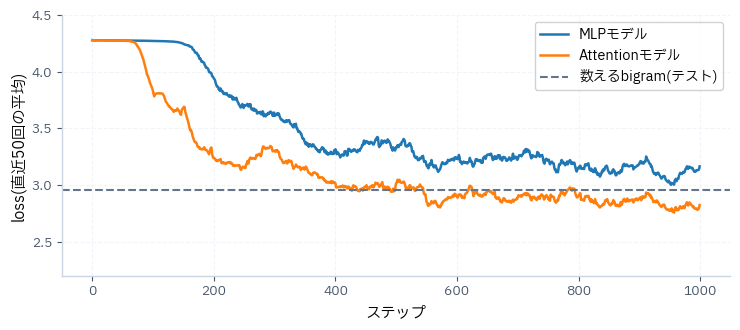

In [65]:
random.seed(0)
n_embd, n_head = 16, 4
head_dim = n_embd // n_head
attn_state = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd),
              'attn_wq': matrix(n_embd, n_embd), 'attn_wk': matrix(n_embd, n_embd),
              'attn_wv': matrix(n_embd, n_embd), 'attn_wo': matrix(n_embd, n_embd),
              'lm_head': matrix(vocab_size, n_embd)}
attn_params = all_params(attn_state)
print('パラメーター数:', len(attn_params))

def attention(x, keys, values, wq, wk, wv, wo, record=None):
    q, k, v = linear(x, wq), linear(x, wk), linear(x, wv)   # 1. Query, Key, Value を作るよ
    keys.append(k)                                            # 8.6 今までの文字のKeyとValueだけがたまっていくよ
    values.append(v)
    x_attn = []
    for h in range(n_head):                                   # 8.7 ヘッドごとに計算するよ
        hs = h * head_dim
        q_h = q[hs:hs + head_dim]
        k_h = [ki[hs:hs + head_dim] for ki in keys]
        v_h = [vi[hs:hs + head_dim] for vi in values]
        attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5 for t in range(len(k_h))]  # 2. 内積 ÷ √d
        attn_weights = softmax(attn_logits)                   # 3. softmax
        if record is not None:
            record[h].append([w.data for w in attn_weights])
        head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h))) for j in range(head_dim)]  # 4. 加重平均
        x_attn.extend(head_out)
    return linear(x_attn, wo)                                 # 4つのヘッドの結果を混ぜるよ

def attn_model(tokens, record=None):
    keys, values, logits_list = [], [], []
    s = attn_state
    for pos_id, token in enumerate(tokens):
        x = [t + p for t, p in zip(s['wte'][token], s['wpe'][pos_id])]   # 8.4 文字 + 位置
        x = attention(x, keys, values, s['attn_wq'], s['attn_wk'], s['attn_wv'], s['attn_wo'], record)
        logits_list.append(linear(x, s['lm_head']))
    return logits_list

attn_history = train_sgd(attn_model, attn_params, num_steps=1000, learning_rate=0.5)
print(f'テストloss: {test_loss(attn_model):.4f}  (数えるbigram: {BIGRAM_TEST_LOSS:.4f})')
print('作った名前:', ' '.join(generate(attn_model, 12)))
plot_history({'MLPモデル': mlp_history, 'Attentionモデル': attn_history})

ついに，**テストlossが数えるbigramモデルを下回りました！** 作った名前も，2〜3文字の名前らしいものが増えました。
前の文字をすべて見て，さらに「何文字目か」もわかるようになったので，「直前の1文字だけ」の限界を超えられたのです。
> Finally, **the test loss went below the counting bigram model!** The names it makes are now mostly 2–3 characters long and look more like names.
Because it looks at all the previous characters and also knows the position, it went beyond the limit of "only the one previous character".

### [スライダー] モデルがどこに注目しているか見てみよう - [Slider] See where the model is paying attention

名前を入力すると，4つのヘッドそれぞれの注目の重みが表示されます。
**行が「今の文字(Query)」，列が「注目された文字(Key)」** です。明るいほど強く注目しています。右上が空白なのは，未来の文字は見ないからです(8.6)。
> Type a name to see the attention weights of each of the 4 heads.
**Rows are the "current character (query)", and columns are the "character being attended to (key)"**. Brighter means stronger attention. The upper right is empty because the model does not look at future characters (8.6).

In [66]:
#@title [スライダー] Attentionの重みのヒートマップ { display-mode: "form" }
def show_attention(name='さくら'):
    if not name or any(ch not in stoi for ch in name) or len(name) > block_size - 1:
        print(f'語彙にあるひらがなで，{block_size - 1}文字以内の名前を入れてね')
        return
    tokens = tokenize(name)[:-1]
    record = [[] for _ in range(n_head)]
    logits_list = attn_model(tokens, record)
    labels = [tok_str(t) for t in tokens]
    fig, axes = plt.subplots(1, n_head, figsize=(3.2 * n_head, 3.4))
    for h, ax in enumerate(axes):
        grid = [row + [float('nan')] * (len(tokens) - len(row)) for row in record[h]]
        im = ax.imshow(grid, cmap='viridis', vmin=0, vmax=1)
        ax.set_xticks(range(len(tokens)), labels, fontsize=9)
        ax.set_yticks(range(len(tokens)), labels, fontsize=9)
        ax.set_title(f'ヘッド {h + 1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('注目された文字 (Key)', fontsize=9)
    axes[0].set_ylabel('今の文字 (Query)', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()
    for t, lg in zip(labels, logits_list):
        p = softmax_numbers([l.data for l in lg])
        top = sorted(range(vocab_size), key=lambda i: -p[i])[:5]
        print(f'「{t}」の次の予想: ' + '  '.join(f'{tok_str(i)} {p[i]:.2f}' for i in top))

interact(show_attention, name=widgets.Text(value='さくら', description='名前:'));

ヘッドによって注目のしかたが違うことがわかります。どのヘッドがどんな役割を持つかは，学習をやり直すと変わります。
> You can see that each head pays attention differently. Which head plays which role changes if you train again.

> このモデルにはまだ第7章のMLPが入っていません。次の章では，AttentionとMLPを **何層も重ねても学習がうまくいく** ための工夫を学び，0.1のGPTを完成させます。
> This model does not have the MLP from Chapter 7 yet. In the next chapter, we learn tricks that make training work **even when Attention and MLP are stacked in many layers**, and complete the GPT from 0.1.

## 8.9 0.1のコードとの対応 - Matching with the code in 0.1

```python
q = linear(x, state_dict[f'layer{li}.attn_wq'])   # 8.3 Queryを作るよ
k = linear(x, state_dict[f'layer{li}.attn_wk'])   # 8.3 Keyを作るよ
v = linear(x, state_dict[f'layer{li}.attn_wv'])   # 8.3 Valueを作るよ
keys[li].append(k); values[li].append(v)          # 8.6 過去の文字だけを蓄積するよ
for h in range(n_head): ...                       # 8.7 マルチヘッド計算だよ
    attn_logits = [... / head_dim**0.5 ...]       # 8.5 内積 ÷ √d
    attn_weights = softmax(attn_logits)           # 8.3 softmaxで重み化するよ
    head_out = [sum(attn_weights[t] * v_h[t][j] ...)]  # 8.2 加重平均だよ
x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])   # 8.7 ヘッドの出力を混ぜるよ
```

## 練習問題 - Exercises

1. 重みが $0.5,\ 0.3,\ 0.2$，値が $10,\ 20,\ 50$ のときの加重平均を求めましょう。
2. Queryとすべての Key の内積が同じ値だったら，重みはどうなるでしょうか？
3. 位置埋め込みがないと，「はな」の最後の「な」と「なな」の最後の「な」で，Attentionの出力は同じになるでしょうか？ 違うでしょうか？

<details><summary>答え - Answers</summary>

1. $0.5 \times 10 + 0.3 \times 20 + 0.2 \times 50 = 21$ です。
2. すべて同じ重み(文字が $n$ 個なら $\frac1n$ ずつ)になり，ただの平均になります。
3. 違います。注目される文字の集まりが「BOS，は，な」と「BOS，な，な」で違うからです。ただし位置埋め込みがないと「はな」と「なは」のような並び替えは区別できません。
</details>

---
# 第9章 学習を安定させる: RMSNormと残差接続 - Chapter 9: Stabilizing training: RMSNorm and residual connections

AttentionとMLPを組み合わせ，さらに何層も重ねれば，もっと賢いモデルになりそうです。
でも実際には，計算を何層も重ねると **値が大きくなりすぎたり小さくなりすぎたりして，学習がうまくいかなくなる** という問題が起きます。
この章では，それを防ぐ2つの工夫，**RMSNorm** と **残差接続** を学んで，0.1のGPTを完成させます。
> Combining Attention and MLP and stacking many layers seems like it would make a smarter model.
But in practice, stacking many layers causes a problem: **values become too large or too small, and training stops working**.
In this chapter, we learn two tricks to prevent this, **RMSNorm** and **residual connections**, and complete the GPT from 0.1.

**この章で使う数学**: 平均・分散・標準偏差(数学I「データの分析」)，正規分布(数学Bの内容を少しだけ)
> **Math in this chapter**: mean, variance, standard deviation (Math I), the normal distribution (a small part of Math B)

## 9.1 復習: 平均・分散・標準偏差 - Review: mean, variance, standard deviation

数学Iの「データの分析」で，データの **散らばり** を表す数を学びました。
> In Math I, we learned numbers that describe how **spread out** data is:

- **平均** $\bar{x} = \dfrac{1}{n}\sum x_i$
- **分散** $s^2 = \dfrac{1}{n}\sum (x_i - \bar{x})^2$ (平均からのずれの2乗の平均)
- **標準偏差** $s = \sqrt{s^2}$ (分散の平方根。元のデータと同じ単位で散らばりを表す)
> - **Mean** $\bar{x} = \dfrac{1}{n}\sum x_i$
> - **Variance** $s^2 = \dfrac{1}{n}\sum (x_i - \bar{x})^2$ (the average of the squared differences from the mean)
> - **Standard deviation** $s = \sqrt{s^2}$ (the square root of the variance, in the same units as the data)

In [67]:
data = [2, 4, 4, 4, 5, 5, 7, 9]
mean = sum(data) / len(data)
var = sum((x - mean) ** 2 for x in data) / len(data)
print('平均:', mean, ' 分散:', var, ' 標準偏差:', var ** 0.5)

平均: 5.0  分散: 4.0  標準偏差: 2.0


## 9.2 RMS: 二乗平均平方根 - RMS: root mean square

**RMS(Root Mean Square，二乗平均平方根)** は，「2乗して，平均して，平方根をとる」という，名前のとおりの計算です。
> **RMS (Root Mean Square)** is exactly what its name says: "square, take the mean, take the square root":

$$\text{RMS}(x) = \sqrt{\frac{1}{n}\sum x_i^2}$$

分散の式から平均を引く部分をなくしたもので，**ベクトルの成分がだいたいどれくらいの大きさか** を表します。平均が0なら，標準偏差と同じ値になります。
> It is the variance formula without subtracting the mean, and it shows **roughly how large the components of a vector are**. If the mean is 0, it equals the standard deviation.

## 9.3 RMSNorm: 大きさをそろえる - RMSNorm: making the size uniform

**RMSNorm** は，ベクトルの各成分を **RMSで割る** ことで，RMSが1になるようにそろえる処理です。
向き(成分どうしの比)は変わらず，大きさだけがそろいます。
> **RMSNorm** divides each component of a vector **by its RMS**, so that the RMS becomes 1.
The direction (the ratios between components) stays the same; only the size is made uniform.

In [68]:
def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)   # 2乗の平均 (mean square) だよ
    scale = (ms + 1e-5) ** -0.5              # 1/√ms。0で割らないように，ほんの少し(0.00001)足しておくよ
    return [xi * scale for xi in x]

v = [3.0, -1.0, 2.0, 0.5]
nv = rmsnorm(v)
rms = lambda x: (sum(xi * xi for xi in x) / len(x)) ** 0.5
print('元のベクトル:', v, ' RMS =', round(rms(v), 3))
print('RMSNorm後  :', [round(x, 3) for x in nv], ' RMS =', round(rms(nv), 3))

元のベクトル: [3.0, -1.0, 2.0, 0.5]  RMS = 1.887
RMSNorm後  : [1.589, -0.53, 1.06, 0.265]  RMS = 1.0


### [スライダー] ベクトルを何倍にしても，RMSNorm後は同じ - [Slider] No matter how much you scale the vector, RMSNorm gives the same result

In [69]:
#@title [スライダー] RMSNorm によるスケーリングの安定化 { display-mode: "form" }
def plot_rmsnorm(scale=1.0):
    base = [3.0, -1.0, 2.0, 0.5, -2.5, 1.0]
    x = [scale * b for b in base]
    nx = rmsnorm(x)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.4))
    ax1.bar(range(6), x, color='#3b82f6', edgecolor='#1d4ed8')
    ax1.axhline(0, color='#64748b', lw=1.0)
    m = max(30, max(abs(v) for v in x) * 1.15)
    ax1.set_ylim(-m, m)
    ax1.set_title(f'元のベクトル (RMS = {rms(x):.2f})', fontsize=11, fontweight='bold')
    ax1.set_ylabel('値')

    ax2.bar(range(6), nx, color='#10b981', edgecolor='#047857')
    ax2.set_ylim(-3.0, 3.0)
    ax2.axhline(0, color='#64748b', lw=1.0)
    ax2.set_title(f'RMSNorm後 (RMS = {rms(nx):.2f}) - 常に一定！', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(plot_rmsnorm, scale=widgets.FloatSlider(value=1.0, min=0.01, max=10, step=0.1, description='拡大倍率:'));

## 9.4 なぜ大きさをそろえるの？ - Why make the size uniform?

線形変換を何回も重ねると，1回ごとに値がだいたい同じ倍率で大きく(または小さく)なっていきます。
1回で2倍になるなら，10層で $2^{10} = 1024$ 倍，1回で0.5倍なら $0.5^{10} \approx 0.001$ 倍です(第3章の指数ですね！)。
値が大きすぎると計算があふれ，小さすぎると傾きがほとんど0になって学習が進みません。
> When we stack many linear transformations, the values grow (or shrink) by roughly the same factor each time.
If they double each time, 10 layers make them $2^{10} = 1024$ times larger; if they halve, $0.5^{10} \approx 0.001$ times (exponents from Chapter 3!).
Values that are too large overflow; values that are too small make the slopes almost 0, so learning stops.

### [スライダー] 層を重ねたときの値の大きさ - [Slider] The size of values when stacking layers

ランダムな行列で線形変換を何回も重ねたとき，ベクトルのRMSがどう変わるかを見てみましょう。縦軸は対数の目盛りです(1目盛りで10倍)。
行列の数の散らばり(標準偏差)を変えると，RMSNormなし(青)ではすぐに爆発したり消えたりしますが，RMSNormあり(オレンジ)ではずっと1のままです。
> Let's see how the RMS of a vector changes when we stack linear transformations with random matrices. The vertical axis is logarithmic (each step is 10 times).
When you change the spread (standard deviation) of the numbers in the matrices, without RMSNorm (blue) the values quickly explode or vanish, but with RMSNorm (orange) they stay at 1.

In [70]:
#@title [スライダー] 層を重ねたときのRMSの比較 (対数目盛り) { display-mode: "form" }
import numpy as np
def plot_depth(std=0.3, layers=20):
    rng = np.random.default_rng(0)
    x0 = rng.normal(0, 1, 16)
    x_plain, x_norm = x0.copy(), x0.copy()
    r_plain, r_norm = [np.sqrt(np.mean(x0**2))], [np.sqrt(np.mean(x0**2))]
    for _ in range(layers):
        W = rng.normal(0, std, (16, 16))
        x_plain = W @ x_plain
        x_norm = W @ x_norm
        x_norm = x_norm / np.sqrt(np.mean(x_norm**2) + 1e-5)
        r_plain.append(np.sqrt(np.mean(x_plain**2)))
        r_norm.append(np.sqrt(np.mean(x_norm**2)))
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    ax.semilogy(r_plain, 'o-', color='#ef4444', lw=1.8, ms=4, label='RMSNormなし (制御不能！)')
    ax.semilogy(r_norm, 'o-', color='#10b981', lw=2.0, ms=4, label='RMSNormあり (常に安定！)')
    ax.set_xlabel('層の深さ (レイヤー数)', fontsize=11)
    ax.set_ylabel('ベクトルのRMS (対数目盛り)', fontsize=11)
    ax.set_ylim(1e-10, 1e10)
    ax.set_title(f'層の深さとベクトルの大きさの推移 (重みのstd: {std:.2f})', fontsize=12, fontweight='bold')
    ax.legend(frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

interact(plot_depth, std=widgets.FloatSlider(value=0.3, min=0.05, max=0.6, step=0.01, description='重みのバラつき:'),
         layers=widgets.IntSlider(value=20, min=1, max=50, step=1, description='層の深さ:'));

16成分のベクトルでは，標準偏差が $\frac{1}{\sqrt{16}} = 0.25$ のときにだけ，ほぼ大きさが保たれます。それより少しでもずれると，指数関数的に爆発したり消えたりします。
RMSNormをはさめば，標準偏差がいくつでも大きさがそろいます。
> With 16-component vectors, the size is roughly kept only when the standard deviation is $\frac{1}{\sqrt{16}} = 0.25$. Even a small difference makes it explode or vanish exponentially.
With RMSNorm in between, the size stays uniform whatever the standard deviation.

## 9.5 残差接続: 近道を作る - Residual connections: making a shortcut

もう1つの工夫が **残差接続(Residual Connection)** です。AttentionやMLPの **出力に，入力をそのまま足します**。
> The other trick is the **residual connection**. We **add the input directly to the output** of Attention or MLP:

$$x \leftarrow x + f(x)$$

こうすると，AttentionやMLP($f$)は「入力をまるごと作り直す」のではなく，「入力に **足すべき修正分** だけを作ればいい」ことになります。
さらに大事なのが逆伝播です。第5章で見たように，**足し算の局所的な傾きは1** でした。だから傾きは，近道を通って **小さくならずに** 入力側まで届きます。
何層重ねても，傾きが途中で消えてしまわないのです。
> This way, Attention or MLP ($f$) does not need to "rebuild the whole input"; it only needs to produce "**the correction to add** to the input".
Even more important is the backward pass. As we saw in Chapter 5, **the local slope of addition is 1**. So the slope travels through the shortcut to the input side **without shrinking**.
No matter how many layers we stack, the slopes do not vanish along the way.

### [アニメーション] 残差接続と傾きの流れ - [Animation] Residual connections and the flow of slopes

In [71]:
#@title アニメーション: 残差接続 { display-mode: "form" }
def make_scene(mn, T):
    class ResidualScene(mn.Scene):
        def construct(self):
            title = T('残差接続: x ← x + f(x)', font_size=34).to_edge(mn.UP)
            self.play(mn.Write(title))
            xin = T('x', font_size=36).move_to(mn.LEFT * 5.5)
            norm = mn.VGroup(mn.RoundedRectangle(width=2, height=0.9, corner_radius=0.15, color=mn.TEAL), T('RMSNorm', font_size=24)).move_to(mn.LEFT * 2.8 + mn.DOWN * 0.8)
            f = mn.VGroup(mn.RoundedRectangle(width=2.4, height=0.9, corner_radius=0.15, color=mn.BLUE), T('Attention / MLP', font_size=22)).move_to(mn.RIGHT * 0.2 + mn.DOWN * 0.8)
            plus = mn.VGroup(mn.Circle(0.3, color=mn.YELLOW), T('+', font_size=34, color=mn.YELLOW)).move_to(mn.RIGHT * 3)
            xout = T('次の層へ', font_size=28).move_to(mn.RIGHT * 5.3)
            a1 = mn.Arrow(xin.get_right(), norm.get_left(), buff=0.15)
            a2 = mn.Arrow(norm.get_right(), f.get_left(), buff=0.1)
            a3 = mn.Arrow(f.get_right(), plus.get_bottom() + mn.LEFT * 0.1, buff=0.1)
            skip = mn.CurvedArrow(xin.get_top() + mn.UP * 0.1, plus.get_top(), angle=-0.8, color=mn.YELLOW)
            skip_lab = T('近道ハイウェイ (そのまま足す)', font_size=24, color=mn.YELLOW).move_to(mn.UP * 1.9)
            a4 = mn.Arrow(plus.get_right(), xout.get_left(), buff=0.1)
            self.play(mn.FadeIn(xin), mn.FadeIn(norm), mn.FadeIn(f), mn.FadeIn(plus), mn.FadeIn(xout), *[mn.GrowArrow(a) for a in (a1, a2, a3, a4)])
            self.play(mn.Create(skip), mn.FadeIn(skip_lab))
            fw = T('順伝播: f(x) は「差分の修正」だけを学習すればOKだよ', font_size=26).to_edge(mn.DOWN)
            self.play(mn.FadeIn(fw))
            dot = mn.Dot(color=mn.WHITE).move_to(xin)
            self.play(mn.MoveAlongPath(dot, mn.VMobject().set_points_as_corners([xin.get_center(), norm.get_center(), f.get_center(), plus.get_center()])), run_time=1.5)
            self.play(mn.FadeOut(dot))
            bw = T('逆伝播: 足し算の傾きは 1.0 → 近道を通って勾配がそのまま届くよ！', font_size=25, color=mn.RED).to_edge(mn.DOWN)
            self.play(mn.Transform(fw, bw))
            back = skip.copy().set_color(mn.RED).set_stroke(width=8)
            for _ in range(2):
                self.play(mn.ShowPassingFlash(back.copy().reverse_direction(), time_width=0.5), run_time=1.2)
            self.wait(1.5)
    return ResidualScene

show_anim(make_scene)

## 9.6 最初のパラメーター: 正規分布 - Initial parameters: the normal distribution

0.1のコードでは，パラメーターの最初の値を `random.gauss(0, 0.08)` で決めていました。
これは，**平均0，標準偏差0.08の正規分布** にしたがう乱数です。正規分布は，平均のまわりに多く集まり，離れるほど少なくなる「つりがね型」の分布で，**平均 ± 標準偏差の範囲に約68%** が入ります。
9.4で見たように，最初の値の散らばりが大きすぎても小さすぎても学習がうまくいかないので，小さめの値からスタートするのです。
> In 0.1, the initial values of the parameters were set with `random.gauss(0, 0.08)`.
These are random numbers from **a normal distribution with mean 0 and standard deviation 0.08**. The normal distribution is "bell-shaped": many values gather around the mean and fewer appear farther away. **About 68% fall within mean ± standard deviation.**
As we saw in 9.4, training does not work well if the initial spread is too large or too small, so we start with smallish values.

In [72]:
#@title [スライダー] 正規分布に従う乱数のヒストグラム { display-mode: "form" }
def plot_gauss(std=0.08):
    rng = random.Random(0)
    xs = [rng.gauss(0, std) for _ in range(5000)]
    inside = sum(abs(x) <= std for x in xs) / len(xs)
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    ax.hist(xs, bins=60, range=(-0.5, 0.5), color='#3b82f6', edgecolor='#1d4ed8', alpha=0.8)
    ax.axvspan(-std, std, color='#f59e0b', alpha=0.25, label=f'平均±1σの範囲 (全体の {inside:.1%})')
    ax.set_title(f'random.gauss(0, {std:.2f}) による 5000個の乱数分布', fontsize=12, fontweight='bold')
    ax.set_xlabel('生成された値')
    ax.set_ylabel('度数')
    ax.legend(frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

interact(plot_gauss, std=widgets.FloatSlider(value=0.08, min=0.01, max=0.2, step=0.01, description='標準偏差:'));

## 9.7 実装: GPTの完成 - Implementation: completing the GPT

ついに，0.1のGPTと同じモデルを組み立てます。これまでの部品を，次の順番につなぐだけです。
> Finally, we assemble the same model as the GPT in 0.1. We just connect the parts so far in this order:

1. 文字の埋め込み + 位置の埋め込み(第6章，第8章) → RMSNorm
2. **Attentionブロック**: RMSNorm → Attention(第8章) → 残差接続
3. **MLPブロック**: RMSNorm → MLP(第7章) → 残差接続
4. `lm_head` でスコアに(第6章)
> 1. Character embedding + position embedding (Chapters 6, 8) → RMSNorm
> 2. **Attention block**: RMSNorm → Attention (Chapter 8) → residual connection
> 3. **MLP block**: RMSNorm → MLP (Chapter 7) → residual connection
> 4. Scores with `lm_head` (Chapter 6)

2と3をまとめて1つの **層(レイヤー)** といいます。0.1では `n_layer = 1` なので1層ですが，この数を増やすと層を何重にも重ねられます。
> Steps 2 and 3 together are called one **layer**. In 0.1, `n_layer = 1`, so there is one layer, but increasing this number stacks more layers.

In [73]:
n_layer = 1

def new_gpt_state(seed=0):
    random.seed(seed)
    state = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd), 'lm_head': matrix(vocab_size, n_embd)}
    for i in range(n_layer):
        state[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
        state[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
        state[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
        state[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
        state[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
        state[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)
    return state

def make_gpt(state):
    def gpt_model(tokens, record=None):
        keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
        logits_list = []
        for pos_id, token in enumerate(tokens):
            x = [t + p for t, p in zip(state['wte'][token], state['wpe'][pos_id])]   # 1. 文字 + 位置埋め込み
            x = rmsnorm(x)
            for li in range(n_layer):
                x_residual = x                                                     # 2. Attentionブロック
                x = rmsnorm(x)
                x = attention(x, keys[li], values[li], state[f'layer{li}.attn_wq'], state[f'layer{li}.attn_wk'],
                              state[f'layer{li}.attn_wv'], state[f'layer{li}.attn_wo'], record)
                x = [a + b for a, b in zip(x, x_residual)]                         #    残差接続
                x_residual = x                                                     # 3. MLPブロック
                x = rmsnorm(x)
                x = linear(x, state[f'layer{li}.mlp_fc1'])
                x = [xi.relu() for xi in x]
                x = linear(x, state[f'layer{li}.mlp_fc2'])
                x = [a + b for a, b in zip(x, x_residual)]                         #    残差接続
            logits_list.append(linear(x, state['lm_head']))                        # 4. スコア
        return logits_list
    return gpt_model

gpt_sgd_state = new_gpt_state()
gpt_sgd = make_gpt(gpt_sgd_state)
print('パラメーター数:', len(all_params(gpt_sgd_state)))

パラメーター数: 5472


パラメーター数が0.1のGPTと同じになりました(0.1では `block_size = 6`)。
勾配降下法で学習させてみましょう。**2〜4分かかります。**
> The number of parameters is the same as the GPT in 0.1 (where `block_size = 6`).
Let's train it with gradient descent. **It takes 2–4 minutes.**

step 1000 / 1000 | 直近100回の平均loss: 2.7103
テストloss: 2.7378  (数えるbigram: 2.9535)
作った名前: みゆ えな ひさり みな のみね りゆ かゆ とねの たり きりこ さい きりよ


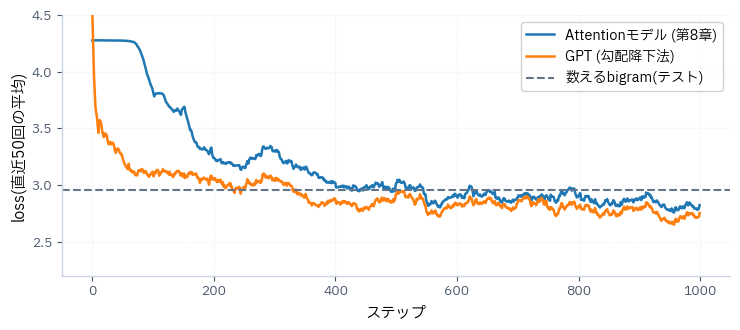

In [74]:
gpt_sgd_history = train_sgd(gpt_sgd, all_params(gpt_sgd_state), num_steps=1000, learning_rate=0.3)
print(f'テストloss: {test_loss(gpt_sgd):.4f}  (数えるbigram: {BIGRAM_TEST_LOSS:.4f})')
print('作った名前:', ' '.join(generate(gpt_sgd, 12)))
plot_history({'Attentionモデル (第8章)': attn_history, 'GPT (勾配降下法)': gpt_sgd_history})

これで，0.1のGPTと同じ仕組みのモデルができあがりました。
でも，まだ1つだけ違うところがあります。0.1では，勾配降下法ではなく **Adam** という方法でパラメーターを更新していました。次の章で，その理由を学びます。
> Now we have a model with the same mechanism as the GPT in 0.1.
But one thing is still different. In 0.1, the parameters were updated not with plain gradient descent but with a method called **Adam**. We learn why in the next chapter.

## 9.8 0.1のコードとの対応 - Matching with the code in 0.1

```python
def rmsnorm(x): ...                           # 9.3 RMSNorm関数だよ
x = rmsnorm(x)                                # 9.7 のステップ1
x_residual = x                                # 9.5 入力ベクトルを残差接続用にキープするよ
x = rmsnorm(x)                                # 9.3
... Attention または MLP ...
x = [a + b for a, b in zip(x, x_residual)]    # 9.5 残差接続で足し算合流するよ
matrix = lambda nout, nin, std=0.08: ...      # 9.6 正規分布によるパラメータ初期化だよ
```

## 練習問題 - Exercises

1. ベクトル $(3, 4)$ のRMSを求めましょう。RMSNormをかけるとどうなるでしょうか？
2. 残差接続 $y = x + f(x)$ で，$f(x)$ の傾きが0でも，$y$ の $x$ に対する傾きは0になりません。なぜでしょうか？

<details><summary>答え - Answers</summary>

1. $\sqrt{\frac{9 + 16}{2}} = \sqrt{12.5} \approx 3.54$ です。RMSNorm後は $(3, 4) \div 3.54 \approx (0.85, 1.13)$ で，RMSは1になります。
2. $y$ の傾きは「$x$ の傾き(1)」+「$f(x)$ の傾き」なので，$f(x)$ の傾きが0でも1が残るからです。
</details>

---
# 第10章 賢い下り方: Adam - Chapter 10: A smarter way down: Adam

第4章の勾配降下法は「傾きの逆向きに，学習率の分だけ進む」というシンプルな方法でした。
0.1のコードでは，これを改良した **Adam(アダム)** という方法が使われています。今では，ほとんどのLLMの学習にAdamやその仲間が使われています。
この章では，数学Iの平均の考え方を使って，Adamの仕組みを学びます。
> Gradient descent in Chapter 4 was a simple method: "move against the slope by the learning rate".
The code in 0.1 uses an improved method called **Adam**. Today, Adam and its relatives are used to train almost all LLMs.
In this chapter, we learn how Adam works using the idea of averages from Math I.

**この章で使う数学**: 平均，移動平均(数学I「データの分析」の発展)，平方根
> **Math in this chapter**: averages, moving averages (an extension of Math I), square roots

## 10.1 勾配降下法の2つの弱点 - Two weaknesses of gradient descent

1. **傾きがばらつく**: 0.1のコードでは，1ステップごとに1つの名前だけを使ってlossを計算します。名前によって傾きが大きく変わるので，進む方向が毎回ふらふらします。
2. **方向によって坂の急さが違う**: 第4章の等高線のスライダーで見たように，急な方向に合わせて学習率を小さくすると，ゆるやかな方向ではなかなか進みません。
> 1. **The slopes are noisy**: In 0.1, each step computes the loss with just one name. The slope changes a lot from name to name, so the direction wobbles every step.
> 2. **Steepness differs by direction**: As we saw with the contour slider in Chapter 4, if we lower the learning rate to suit the steep direction, we barely move in the gentle direction.

Adamは，この2つを **移動平均** という考え方で解決します。
> Adam solves both with the idea of **moving averages**.

## 10.2 移動平均: 最近の値の平均 - Moving averages: the average of recent values

株価のグラフでよく見る「5日移動平均線」は，毎日「直近5日分の平均」を計算してつないだ線です。細かいギザギザがならされて，全体の流れが見やすくなります。
> The "5-day moving average line" often seen on stock charts connects "the average of the last 5 days" calculated every day. It smooths out small zigzags and makes the overall trend easier to see.

Adamでは，もっと簡単に計算できる **指数移動平均** を使います。新しい値 $g$ が来るたびに，次のように更新します。
> Adam uses an **exponential moving average**, which is even easier to calculate. Every time a new value $g$ comes in, we update:

$$m \leftarrow \beta\, m + (1 - \beta)\, g$$

「今までの平均を $\beta$ の割合だけ残して，新しい値を $1 - \beta$ の割合だけ混ぜる」という意味です。
例えば $\beta = 0.9$ なら，前の平均を90%，新しい値を10%混ぜます。古い値ほど $0.9,\ 0.9^2,\ 0.9^3, \ldots$ と重みが指数関数的に小さくなるので，「指数」移動平均といいます。
> It means "keep a fraction $\beta$ of the average so far and mix in a fraction $1 - \beta$ of the new value".
For example, with $\beta = 0.9$, we keep 90% of the previous average and mix in 10% of the new value. Older values get weights $0.9,\ 0.9^2,\ 0.9^3, \ldots$ that shrink exponentially, which is why it is called an "exponential" moving average.

### [スライダー] βを変えて移動平均を見よう - [Slider] Change β and look at the moving average

In [75]:
#@title [スライダー] 指数移動平均 (EMA) による平滑化 { display-mode: "form" }
def plot_ema(beta=0.9):
    rng = random.Random(3)
    g = [math.sin(t / 15) + rng.gauss(0, 0.6) for t in range(150)]
    m, ema = 0.0, []
    for x in g:
        m = beta * m + (1 - beta) * x
        ema.append(m)
    fig, ax = plt.subplots(figsize=(8.5, 3.4))
    ax.plot(g, '.', color='#94a3b8', alpha=0.7, ms=6, label='毎回の値(ばらつきが大きい)')
    ax.plot(ema, color='#ef4444', lw=2.5, label=f'指数移動平均 (β = {beta:.2f})')
    ax.set_ylim(-3, 3)
    ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)
    ax.set_title(f'β = {beta:.2f} による移動平均', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(plot_ema, beta=widgets.FloatSlider(value=0.9, min=0.0, max=0.99, step=0.01, description='減衰率 β:'));

$\beta$ を大きくするほど線はなめらかになりますが，変化に追いつくのが遅くなります。$\beta = 0$ なら，毎回の値そのものです。
> The larger $\beta$, the smoother the line, but the slower it follows changes. With $\beta = 0$, it is just each value itself.

### [アニメーション] ばらつく値を移動平均でならす - [Animation] Smoothing noisy values with a moving average

In [76]:
#@title アニメーション: 指数移動平均 { display-mode: "form" }
def make_scene(mn, T):
    class EMAScene(mn.Scene):
        def construct(self):
            rng = random.Random(3)
            g = [math.sin(t / 6) + rng.gauss(0, 0.6) for t in range(60)]
            ax = mn.Axes(x_range=[0, 60, 10], y_range=[-2.5, 2.5, 1], x_length=10, y_length=5, tips=False).shift(mn.DOWN * 0.4)
            title = T('m ← 0.8 m + 0.2 g', font_size=34).to_edge(mn.UP)
            self.play(mn.Create(ax), mn.Write(title))
            m, prev = 0.0, None
            dots, lines = mn.VGroup(), mn.VGroup()
            for t, x in enumerate(g):
                d = mn.Dot(ax.c2p(t, x), radius=0.05, color=mn.GRAY)
                new_m = 0.8 * m + 0.2 * x
                seg = mn.Line(ax.c2p(t - 1, m), ax.c2p(t, new_m), color=mn.RED, stroke_width=5) if t > 0 else None
                anims = [mn.FadeIn(d, scale=2)]
                if seg: anims.append(mn.Create(seg))
                self.play(*anims, run_time=0.08 if t > 8 else 0.35)
                m = new_m
            lab = mn.VGroup(T('灰色: 毎回の傾き(ばらばら)', font_size=24, color=mn.GRAY),
                             T('赤: 移動平均(なめらか)', font_size=24, color=mn.RED)).arrange(mn.DOWN, aligned_edge=mn.LEFT).to_corner(mn.DR)
            self.play(mn.FadeIn(lab))
            self.wait(1.5)
    return EMAScene

show_anim(make_scene)

## 10.3 1つ目の工夫 m: 傾きの移動平均(勢い) - Trick 1, m: the moving average of the slope (momentum)

Adamは，毎回の傾き $g$ をそのまま使わずに，**傾きの移動平均 $m$** を使って進みます。
> Adam does not use each slope $g$ directly; it moves using **the moving average of the slopes, $m$**:

$$m \leftarrow \beta_1\, m + (1 - \beta_1)\, g$$

ばらつきがならされるので，進む方向が安定します。
また，ジグザグする方向ではプラスとマイナスの傾きが打ち消し合い，いつも同じ向きの方向では傾きが積み重なって，**坂を転がるボールのように勢いがつきます**。
> Because the noise is smoothed out, the direction becomes stable.
Also, in a direction that zigzags, positive and negative slopes cancel out, while in a direction that always has the same sign, the slopes add up, and **it gains momentum like a ball rolling down a hill**.

## 10.4 2つ目の工夫 v: 傾きの2乗の移動平均(歩幅をそろえる) - Trick 2, v: the moving average of the squared slope (equalizing step sizes)

もう1つ，**傾きの2乗の移動平均 $v$** も記録します。
> Adam also records **the moving average of the squared slopes, $v$**:

$$v \leftarrow \beta_2\, v + (1 - \beta_2)\, g^2$$

$\sqrt{v}$ は，第9章のRMSと同じ「2乗して平均して平方根」なので，**そのパラメーターの傾きがふだんどれくらいの大きさか** を表します。
そして，$m$ を $\sqrt{v}$ で割って進みます。
> $\sqrt{v}$ is "square, average, square root", just like RMS in Chapter 9, so it shows **how large the slope of that parameter usually is**.
Then Adam moves by $m$ divided by $\sqrt{v}$:

$$\theta \leftarrow \theta - \eta \, \frac{m}{\sqrt{v} + \varepsilon}$$

($\theta$ はパラメーター，$\varepsilon$ は0で割らないための小さな数です)
> ($\theta$ is a parameter, and $\varepsilon$ is a tiny number to avoid dividing by 0.)

急な方向(傾きがいつも大きい)では大きな数で割るので歩幅が小さくなり，ゆるやかな方向では小さな数で割るので歩幅が大きくなります。
その結果，**どの方向にも，だいたい学習率 $\eta$ くらいの歩幅で進む** ようになります。第4章の「方向によって坂の急さが違う」問題が解決できるのです。
> In steep directions (where slopes are always large) we divide by a large number, so the step gets smaller; in gentle directions we divide by a small number, so the step gets larger.
As a result, **it moves with a step of roughly the learning rate $\eta$ in every direction**. This solves the "steepness differs by direction" problem from Chapter 4.

## 10.5 最初のずれを直す ★ - Correcting the start ★

$m$ と $v$ は0からスタートするので，最初の何ステップかは，本当の平均よりずっと小さな値になってしまいます。
例えば $\beta_1 = 0.9$ で，傾きがずっと1だったとしても，1ステップ目の $m$ は $0.9 \times 0 + 0.1 \times 1 = 0.1$ です。
そこで，$t$ ステップ目では $1 - \beta^t$ で割って補正します(**バイアス補正**)。1ステップ目なら $0.1 \div (1 - 0.9) = 1$ となり，正しい平均になります。
> Since $m$ and $v$ start from 0, for the first few steps they are much smaller than the true average.
For example, with $\beta_1 = 0.9$, even if the slope is always 1, $m$ after step 1 is $0.9 \times 0 + 0.1 \times 1 = 0.1$.
So at step $t$, we divide by $1 - \beta^t$ to correct it (**bias correction**). At step 1, $0.1 \div (1 - 0.9) = 1$, the correct average.

$$\hat{m} = \frac{m}{1 - \beta_1^{\,t}}, \qquad \hat{v} = \frac{v}{1 - \beta_2^{\,t}}$$

$t$ が大きくなると $\beta^t$ は0に近づくので(第3章の指数関数のグラフ！)，補正はだんだん効かなくなります。
> As $t$ grows, $\beta^t$ approaches 0 (the exponential graph from Chapter 3!), so the correction fades away.

In [77]:
beta1 = 0.9
m = 0.0
for t in range(1, 6):
    m = beta1 * m + (1 - beta1) * 1.0   # 傾きがずっと1だったとするよ
    print(f'step {t:2d}: m = {m:.4f},  補正後 m_hat = {m / (1 - beta1**t):.4f}')

step  1: m = 0.1000,  補正後 m_hat = 1.0000
step  2: m = 0.1900,  補正後 m_hat = 1.0000
step  3: m = 0.2710,  補正後 m_hat = 1.0000
step  4: m = 0.3439,  補正後 m_hat = 1.0000
step  5: m = 0.4095,  補正後 m_hat = 1.0000


## 10.6 勾配降下法とAdamを比べよう - Compare gradient descent and Adam

### [スライダー] 等高線の上で比べる - [Slider] Compare on a contour map

第4章と同じ関数 $f(x, y) = (x - 1)^2 + 2(y + 2)^2$ で，勾配降下法(赤)とAdam(青)の進み方を比べます。
さらに「方向による急さの違い」を大きくするスライダーも付けました($y$ の方向の係数)。急さの差を大きくしても，Adamはまっすぐ谷底に向かえるでしょうか？
> Using the same function as Chapter 4, $f(x, y) = (x - 1)^2 + 2(y + 2)^2$, we compare how gradient descent (red) and Adam (blue) move.
There is also a slider to increase "the difference in steepness by direction" (the coefficient in the $y$ direction). Even with a large difference, can Adam head straight for the bottom?

In [78]:
#@title [スライダー] 勾配降下法 vs Adam { display-mode: "form" }
import numpy as np
def plot_optimizers(learning_rate=0.1, steepness=2.0, steps=40):
    fxy = lambda x, y: (x - 1)**2 + steepness * (y + 2)**2
    grad = lambda x, y: (2 * (x - 1), 2 * steepness * (y + 2))
    x, y = -3.0, 1.5; sgd = [(x, y)]
    for _ in range(steps):
        gx, gy = grad(x, y); x, y = x - learning_rate * gx, y - learning_rate * gy
        sgd.append((x, y))
    p, m, v = [-3.0, 1.5], [0.0, 0.0], [0.0, 0.0]; adam = [tuple(p)]
    for t in range(1, steps + 1):
        g = grad(*p)
        for i in range(2):
            m[i] = 0.9 * m[i] + 0.1 * g[i]
            v[i] = 0.999 * v[i] + 0.001 * g[i]**2
            m_hat = m[i] / (1 - 0.9**t)
            v_hat = v[i] / (1 - 0.999**t)
            p[i] -= learning_rate * 2.5 * m_hat / (v_hat**0.5 + 1e-8)
        adam.append(tuple(p))
    X, Y = np.meshgrid(np.linspace(-4, 4, 200), np.linspace(-5, 3, 200))
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.contour(X, Y, fxy(X, Y), levels=25, cmap='viridis', alpha=0.5)
    ok = lambda path: [q for q in path if abs(q[0]) < 8 and abs(q[1]) < 8]
    ax.plot(*zip(*ok(sgd)), 'o-', color='#ef4444', ms=3.5, lw=1.5, label=f'勾配降下法 (f = {fxy(*sgd[-1]):.3g})')
    ax.plot(*zip(*ok(adam)), 'o-', color='#3b82f6', ms=3.5, lw=1.8, label=f'Adam (f = {fxy(*adam[-1]):.3g})')
    ax.plot([1], [-2], 'x', color='#0f172a', ms=12, mew=3, label='谷底')
    ax.set_xlim(-4, 4); ax.set_ylim(-5, 3); ax.set_aspect('equal'); ax.legend(loc='upper right', fontsize=9)
    ax.set_title(f'最適化対決 (急さの差: {steepness:.1f}倍)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(plot_optimizers,
         learning_rate=widgets.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01, description='学習率 η:'),
         steepness=widgets.FloatSlider(value=2.0, min=1.0, max=20.0, step=0.5, description='yの急さ:'),
         steps=widgets.IntSlider(value=40, min=1, max=100, step=5, description='ステップ数:'));

「yの急さ」を大きくすると，勾配降下法は学習率を小さくしないと発散してしまい，小さくすると $x$ の方向になかなか進みません。
Adamは急さに関係なく，どちらの方向にも同じくらいの歩幅で進めます。
(このスライダーではAdamの歩幅を見やすくするため，学習率を2.5倍にしています)
> When you increase "steepness in y", gradient descent diverges unless you lower the learning rate, and with a low learning rate it barely moves in the $x$ direction.
Adam moves with similar steps in both directions, regardless of steepness.
(In this slider, Adam's learning rate is multiplied by 2.5 to make its steps easier to see.)

## 10.7 実装: AdamでGPTを学習する - Implementation: training the GPT with Adam

0.1のコードと同じAdamを実装して，第9章と同じGPTを学習させます。**2〜4分かかります。**
> Let's implement Adam exactly as in 0.1 and train the same GPT as in Chapter 9. **It takes 2–4 minutes.**

step 1000 / 1000 | 直近100回の平均loss 2.6782
テストloss: 2.7154  (勾配降下法: 2.7378 / 数えるbigram: 2.9535)
作った名前: みやな さつみ こと さげ たお りみ かみ なつか たり こりこ しいみ まみう


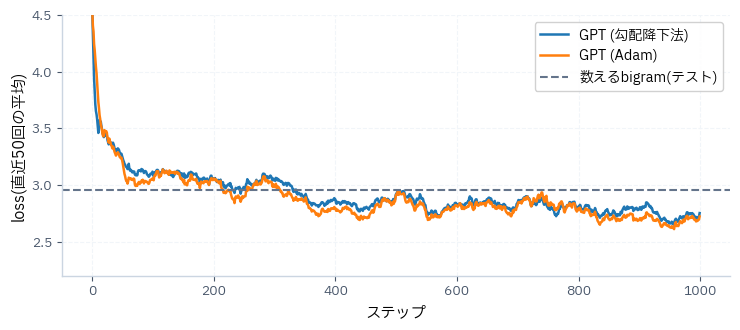

In [79]:
def train_adam(model, params, num_steps=1000, learning_rate=0.01, beta1=0.85, beta2=0.99, eps_adam=1e-8):
    m = [0.0] * len(params)   # 10.3 傾きの移動平均だよ
    v = [0.0] * len(params)   # 10.4 傾きの2乗の移動平均だよ
    history = []
    for step in range(num_steps):
        loss = name_loss(model, docs[step % len(docs)])
        loss.backward()
        lr_t = learning_rate * (1 - step / num_steps)
        for i, p in enumerate(params):
            m[i] = beta1 * m[i] + (1 - beta1) * p.grad
            v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2
            m_hat = m[i] / (1 - beta1 ** (step + 1))   # 10.5 バイアス補正だよ
            v_hat = v[i] / (1 - beta2 ** (step + 1))
            p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
            p.grad = 0
        history.append(loss.data)
        if (step + 1) % 100 == 0:
            print(f'step {step + 1:4d} / {num_steps} | 直近100回の平均loss {sum(history[-100:]) / 100:.4f}', end='\r')
    print()
    return history

gpt_adam_state = new_gpt_state()   # 第9章と同じ最初の値からスタートするよ
gpt_adam = make_gpt(gpt_adam_state)
gpt_adam_history = train_adam(gpt_adam, all_params(gpt_adam_state))
print(f'テストloss: {test_loss(gpt_adam):.4f}  (勾配降下法: {test_loss(gpt_sgd):.4f} / 数えるbigram: {BIGRAM_TEST_LOSS:.4f})')
print('作った名前:', ' '.join(generate(gpt_adam, 12)))
plot_history({'GPT (勾配降下法)': gpt_sgd_history, 'GPT (Adam)': gpt_adam_history})

今回の小さなモデルでは差はわずかですが，Adamのほうがテストlossが少し低くなりました。
Adamの本当のよさは，**学習率の選び方にあまり悩まなくていい** ことです。勾配降下法では，学習率を大きくしすぎると発散し(第7章)，小さすぎるとなかなか進まないので，モデルごとにちょうどいい値を探す必要がありました(このNotebookでも2.0，0.5，0.3と使い分けています)。
Adamは歩幅をパラメーターごとに自動で調整するので，0.01のような決まった値で，いろいろなモデルをうまく学習できます。パラメーターが何十億個もある本物のLLMでは，この差がとても大きくなります。
> With this small model the difference is small, but Adam got a slightly lower test loss.
Adam's real strength is that **you do not have to worry much about choosing the learning rate**. With gradient descent, a learning rate that is too large diverges (Chapter 7) and one that is too small barely moves, so we had to search for a good value for each model (this Notebook uses 2.0, 0.5 and 0.3).
Adam adjusts the step size for each parameter automatically, so a fixed value like 0.01 trains many kinds of models well. In real LLMs with billions of parameters, this difference becomes very large.

これで，**0.1のGPTと完全に同じもの** ができあがりました！
> Now we have built **exactly the same thing as the GPT in 0.1**!

## 10.8 0.1のコードとの対応 - Matching with the code in 0.1

```python
learning_rate, beta1, beta2, eps_adam = 0.01, 0.85, 0.99, 1e-8
m = [0.0] * len(params)                                # 10.3 傾きの移動平均バッファだよ
v = [0.0] * len(params)                                # 10.4 傾き2乗の移動平均バッファだよ
m[i] = beta1 * m[i] + (1 - beta1) * p.grad             # 10.3 傾きの移動平均を更新するよ
v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2        # 10.4 傾きの2乗の移動平均を更新するよ
m_hat = m[i] / (1 - beta1 ** (step + 1))               # 10.5 バイアス補正だよ
v_hat = v[i] / (1 - beta2 ** (step + 1))
p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)     # 10.4 歩幅をそろえて進むよ
```

## 練習問題 - Exercises

1. $\beta = 0.5$ で，値が $4,\ 8$ の順に来たとき，指数移動平均 $m$ はいくつになるでしょうか？($m$ は0から始めます)
2. あるパラメーターの傾きがずっと $0.001$ だったとき，勾配降下法とAdamでは1ステップの歩幅はどう違うでしょうか？(学習率は $0.01$ とします)

<details><summary>答え - Answers</summary>

1. 1回目 $0.5 \times 0 + 0.5 \times 4 = 2$，2回目 $0.5 \times 2 + 0.5 \times 8 = 5$ です。
2. 勾配降下法は $0.01 \times 0.001 = 0.00001$ しか進みません。Adamは $m \approx 0.001$，$\sqrt{v} \approx 0.001$ なので，$0.01 \times \frac{0.001}{0.001} = 0.01$ 進みます。傾きが小さくても，ちゃんと学習率くらいの歩幅で進めます。
</details>

---
# 第11章 全部組み立てる: MicroGPTの完成 - Chapter 11: Putting it all together: MicroGPT complete

おつかれさまでした！ ここまでで，0.1のGPTのすべての部品を作りました。
この章では全体をふり返り，完成したモデルで遊びながら，私たちが普段使うLLMとのつながりを考えます。
この章では，第10章でAdamを使って学習したモデル(`gpt_adam`)を使います。
> Well done! By now, you have built every part of the GPT in 0.1.
In this chapter, we look back at the whole thing, play with the finished model, and think about how it connects to the LLMs we use every day.
This chapter uses the model trained with Adam in Chapter 10 (`gpt_adam`).

## 11.1 全体の流れ - The whole flow

### [アニメーション] 1文字予想するまでの流れ - [Animation] The flow of predicting one character

In [80]:
#@title アニメーション: GPTの全体像 { display-mode: "form" }
def make_scene(mn, T):
    class PipelineScene(mn.Scene):
        def construct(self):
            title = T('GPT: 次の1文字を予想するまで', font_size=34).to_edge(mn.UP)
            self.play(mn.Write(title))
            steps = [('Token「は」', '第1章', mn.BLUE), ('埋め込み + 位置', '第6・8章', mn.BLUE), ('RMSNorm', '第9章', mn.TEAL),
                     ('Attention + 近道', '第8・9章', mn.YELLOW), ('MLP + 近道', '第7・9章', mn.YELLOW), ('lm_head → スコア', '第6章', mn.BLUE),
                     ('softmax → 確率', '第3章', mn.ORANGE), ('くじ引き →「な」', '第2・3章', mn.RED)]
            boxes = mn.VGroup()
            for name, ch, col in steps:
                b = mn.VGroup(mn.RoundedRectangle(width=2.7, height=0.95, corner_radius=0.15, color=col), T(name, font_size=22), T(ch, font_size=16, color=mn.GRAY))
                b[1].move_to(b[0]).shift(mn.UP * 0.12); b[2].move_to(b[0]).shift(mn.DOWN * 0.27)
                boxes.add(b)
            boxes.arrange_in_grid(rows=2, cols=4, buff=(0.65, 1.2)).shift(mn.DOWN * 0.3)
            arrows = mn.VGroup(*[mn.Arrow(boxes[i].get_right(), boxes[i + 1].get_left(), buff=0.08) for i in (0, 1, 2, 4, 5, 6)])
            arrows.add(mn.Arrow(boxes[3].get_bottom(), boxes[4].get_top(), buff=0.08, path_arc=0))
            for i, b in enumerate(boxes):
                self.play(mn.FadeIn(b, shift=mn.UP * 0.2), run_time=0.45)
                if i < len(boxes) - 1:
                    a = arrows[[0, 1, 2, 6, 3, 4, 5][i]]
                    self.play(mn.GrowArrow(a), run_time=0.25)
            train = T('学習: loss = −log p → 逆伝播(第5章) → Adam で更新(第10章)', font_size=24, color=mn.RED).to_edge(mn.DOWN)
            self.play(mn.Write(train))
            self.play(mn.Indicate(boxes[-1], color=mn.RED), run_time=1)
            self.wait(1.5)
    return PipelineScene

show_anim(make_scene)

### 0.1のコードと章の対応表 - Which chapter explains each part of the code in 0.1

| 0.1のコード | 内容 | 章 |
|---|---|---|
| `uchars`，`BOS`，`vocab_size` | Tokenizer | 第1章 |
| `class Value` | 計算グラフと自動微分 | 第5章 |
| `matrix`，`state_dict` | パラメーター，正規分布の乱数 | 第6章，第9章 |
| `linear` | 線形変換(内積を並べる) | 第6章 |
| `softmax` | スコアを確率に | 第3章 |
| `rmsnorm` | 大きさをそろえる | 第9章 |
| `gpt` の `wte`，`wpe` | 埋め込み，位置埋め込み | 第6章，第8章 |
| `gpt` の `# 1) Multi-head Attention block` | Attention | 第8章 |
| `gpt` の `# 2) MLP block` | MLPとReLU | 第7章 |
| `x_residual` | 残差接続 | 第9章 |
| `loss_t = -probs[target_id].log()` | loss | 第3章 |
| `loss.backward()` | 逆伝播 | 第5章 |
| `lr_t`，`m`，`v`，`m_hat`，`v_hat` | 学習率の減衰，Adam | 第4章，第10章 |
| `temperature`，`random.choices` | temperature，くじ引き | 第3章，第2章 |

もう一度0.1のコードを読んでみてください。最初は呪文のように見えたコードが，1行ずつ意味のわかるものになっているはずです。
> Try reading the code in 0.1 again. Code that looked like a magic spell at first should now make sense line by line.

## 11.2 完成したモデルで名前を作ろう - Make names with the finished model

### [スライダー] temperatureと名前 - [Slider] Temperature and names

temperatureを変えながら，完成したGPTに名前を作らせてみましょう。学習データにある名前か，新しい名前かも表示します。
> Let's have the finished GPT make names while changing the temperature. It also shows whether each name is in the training data or new.

In [81]:
#@title [スライダー] GPTで名前を作る { display-mode: "form" }
def show_names(temperature=0.5, seed=0):
    names = generate(gpt_adam, 20, temperature=temperature, seed=seed)
    new = [n for n in names if n not in docs]
    for i, n in enumerate(names):
        print(f'{n:<6}', '(学習データにある名前)' if n in docs else '(新しい名前！)', end='\n' if i % 2 else '    ')
    print(f'\n新しい名前: {len(new)} / {len(names)}')

interact(show_names,
         temperature=widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description='T:', continuous_update=False),
         seed=widgets.IntSlider(value=0, min=0, max=20, description='乱数の種:', continuous_update=False));

temperatureが低いと，学習データによくある名前ばかりになります。高くすると新しい名前が増えますが，だんだん名前らしくなくなっていきます。
> With a low temperature, you mostly get names that are common in the training data. With a high temperature, there are more new names, but they gradually stop looking like names.

### [スライダー] モデルの頭の中をのぞく - [Slider] Look inside the model's head

名前の最初の何文字かを入力すると，モデルが「次の文字」にどんな確率をつけているかが見られます。
> Type the first few characters of a name to see what probabilities the model gives to "the next character".

In [82]:
#@title [スライダー] 次の文字の確率 { display-mode: "form" }
def show_next(prefix='ゆ', temperature=1.0):
    if any(ch not in stoi for ch in prefix) or len(prefix) > block_size - 1:
        print(f'語彙にあるひらがなで，{block_size - 1}文字以内で入れてね')
        return
    tokens = [BOS] + encode(prefix)
    logits = gpt_adam(tokens)[-1]
    p = softmax_numbers([l.data for l in logits], temperature)
    top = sorted(range(vocab_size), key=lambda i: -p[i])[:15]
    fig, ax = plt.subplots(figsize=(8.5, 3.2))
    ax.bar(['終わり' if i == BOS else tok_str(i) for i in top], [p[i] for i in top], color='#10b981', edgecolor='#047857')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'「{prefix}」の次の文字の確率 (T = {temperature:.1f})', fontsize=12, fontweight='bold')
    ax.set_ylabel('確率')
    plt.tight_layout()
    plt.show()
    in_data = sum(1 for d in docs if d.startswith(prefix))
    print(f'学習データで「{prefix}」から始まる名前: {in_data}個')

interact(show_next, prefix=widgets.Text(value='ゆ', description='最初の文字:'),
         temperature=widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='T:'));

「ゆ」「ゆき」「さく」などを入れてみましょう。「ゆき」の次は「終わり」(BOS)の確率が高いはずです。
学習データに1つもない始まり方(例えば「ぬぬ」)を入れても，モデルは **何かしらの確率を必ず出します**。これが次の節のテーマです。
> Try "ゆ", "ゆき", "さく" and so on. After "ゆき", "end" (BOS) should have a high probability.
Even if you type a beginning that never appears in the training data (for example "ぬぬ"), the model **always outputs some probabilities**. This is the theme of the next section.

## 11.3 なぜAIはもっともらしい間違いを出力するのか - Why does AI output plausible mistakes?

ChatGPTなどのLLMは，ときどき事実と違うことを，とても自然な文章で答えることがあります。これを **ハルシネーション(幻覚)** といいます。
このNotebookで作ったGPTを思い出すと，その理由が見えてきます。
> LLMs like ChatGPT sometimes give answers that are not true, in very natural sentences. This is called **hallucination**.
Remembering the GPT we built in this Notebook helps us see why.

1. **GPTがやっているのは「次のTokenの確率を計算して，くじを引く」ことだけ** です(第2章，第3章)。「正しいかどうか」を確かめる仕組みはどこにもありません。
2. 学習でlossを小さくするとは，**学習データに「ありそうな」並び方をまねる** ことです。だから出力は「もっともらしく」なります。
3. 学習データにない状況でも(「ぬぬ」の例)，モデルは **必ず何かの確率を出して，何かを選びます**。「わかりません」と言うのも，結局は「わかりません」というTokenの並びが選ばれたときだけです。
4. 0.2で見たように，GPTは学習データにない名前(「新しい名前！」)も作りました。名前づくりならそれは創造性ですが，事実を答えるときには，それが **存在しない事実を作り出すこと** になります。
> 1. **All a GPT does is "calculate the probabilities of the next token and draw a lot"** (Chapters 2, 3). There is no mechanism anywhere that checks whether something is true.
> 2. Making the loss smaller means **imitating sequences that are "likely" in the training data**. That is why the output looks "plausible".
> 3. Even in situations not in the training data (the "ぬぬ" example), the model **always outputs some probabilities and picks something**. Saying "I don't know" only happens when the token sequence "I don't know" is chosen.
> 4. As we saw in 0.2, the GPT made names that were not in the training data ("new names!"). For making names, that is creativity; but when answering facts, it means **creating facts that do not exist**.

つまり，ハルシネーションは「バグ」というより，**GPTの仕組みそのものから自然に出てくる性質** なのです。
本物のLLMは，事後学習(Post-training)などで間違いを減らす工夫をしていますが，仕組み上ゼロにすることは難しいのです。
> In other words, hallucination is not so much a "bug" as **a property that naturally comes from how GPT works**.
Real LLMs use techniques such as post-training to reduce mistakes, but because of how they work, it is hard to make them zero.

## 11.4 AIにどう入力すればいいか - How should we give input to AI?

GPTは「それまでのTokenの並び(文脈)」から次のTokenの確率を決めていました(第8章のAttention)。
スライダーで「ゆ」と「ゆき」を入れたとき，次の文字の確率がまったく違ったように，**入力する文章(プロンプト)が変われば，出てくる答えの確率も変わります**。
> A GPT decides the probabilities of the next token from "the sequence of tokens so far (the context)" (Attention in Chapter 8).
Just as the probabilities of the next character were completely different for "ゆ" and "ゆき" in the slider, **if the input text (the prompt) changes, the probabilities of the answer change too**.

このことから，AIを使うときに役立つコツがわかります。
> This gives us useful tips for using AI:

- **状況や目的をくわしく書く**: 文脈が多いほど，Attentionが注目できる手がかりが増えて，求める答えの確率が高くなります。
- **答えの形を指定する・例を見せる**: 「箇条書きで」「この例のように」と書くと，その形に続くTokenの確率が高くなります。
- **大事な事実は自分で確かめる**: 11.3で見たように，もっともらしさと正しさは別物です。
- **同じ質問でも答えは毎回変わる**: くじ引き(temperature)で選んでいるからです。何回か聞いてみるのも1つの手です。
> - **Describe the situation and your goal in detail**: More context gives Attention more clues to focus on, making the answer you want more likely.
> - **Specify the format or show an example**: Writing "as a bulleted list" or "like this example" makes tokens that follow that format more likely.
> - **Check important facts yourself**: As we saw in 11.3, plausible and correct are different things.
> - **Answers change even for the same question**: Because it chooses by drawing lots (temperature). Asking a few times can help.

## 11.5 本物のLLMとの違い - Differences from real LLMs

私たちのMicroGPTと，ChatGPTなどの本物のLLMの **仕組みの本質は同じ** です。違うのは主に「規模」と「学習のさせ方」です。
> The **essence of the mechanism** is the same for our MicroGPT and real LLMs like ChatGPT. The main differences are "scale" and "how they are trained".

| 項目 | MicroGPT | 本物のLLM |
|---|---|---|
| パラメーター数 | 約5000個 | 数十億〜数千億個以上 |
| Token | ひらがな1文字 | BPEによる文字のかたまり(第1章) |
| 語彙の大きさ | 72 | 数万〜数十万 |
| 層の数 | 1 | 数十〜100以上 |
| 一度に見られる長さ | 6 Token | 数千〜数十万Token以上 |
| 学習データ | 女性名 約3000個 | インターネット上の大量の文章など |
| 学習 | 事前学習のみ | 事前学習 + 事後学習(指示に従う練習，人間の好みに合わせる調整など) |
| 計算 | Pythonで1つずつ | GPUで行列をまとめて一気に |

逆に言えば，**このNotebookで作ったものを大きくしていけば，本物のLLMにつながっている** ということです。
> Put the other way, **if you scale up what you built in this Notebook, it leads to real LLMs**.

## 11.6 もっと試してみよう - Try more

- 第9章の `n_layer = 1` を `2` にすると，層を2つ重ねたGPTになります(学習時間は約2倍)。lossはどう変わるでしょうか？
- `num_steps` を増やすと，lossはどこまで下がるでしょうか？ テストlossも下がり続けるでしょうか？
- 共通準備セルのデータを男性の名前(`first_name_man_org.csv`)に変えてみましょう(同じデータセットに入っています)。
> - Change `n_layer = 1` in Chapter 9 to `2` to make a GPT with two layers (training takes about twice as long). How does the loss change?
> - If you increase `num_steps`, how low does the loss go? Does the test loss keep going down too?
> - Try changing the data in the common setup cell to male names (`first_name_man_org.csv`, in the same dataset).

## おわりに - Closing

0.2で立てた3つの問い，
> The three questions from 0.2:

- 「なぜこのコードから，学習データにない名前が生成されたのか」
- 「私たちが普段使うAIがどう動いていて，どう入力すべきなのか」
- 「なぜAIはもっともらしい間違い(ハルシネーション)を出力するのか」

を，自分の言葉で説明できるようになったでしょうか？
ここまでたどり着いたあなたは，LLMの一番大事な仕組みを，数学から実装まで自分の手で作りきりました。ぜひ，その先の世界も探求してみてください。
> Can you now explain them in your own words?
Having come this far, you have built the most important mechanism of LLMs with your own hands, from the math to the code. Please go on and explore the world beyond.

---
# 付録 - Appendix

## A. 用語集 - Glossary

| 用語 | 英語表記 | 意味 | 登場する章 |
|---|---|---|---|
| 大規模言語モデル | Large Language Model (LLM) | 大量の文章で学習し，次のTokenを予想するモデル | 第0章 |
| トークン | Token | モデルが扱う文字や単語のかけらの単位，とその番号 | 第1章 |
| トークナイザー | Tokenizer | 文字列とTokenを変換する仕組み | 第1章 |
| 語彙 | Vocabulary | Tokenの種類の全体 | 第1章 |
| 言語モデル | Language Model | 次に来るTokenの確率を求めるモデル | 第2章 |
| 条件付き確率 | Conditional Probability | ある条件のもとでの確率 $P_A(B)$ | 第2章 |
| 損失 (loss) | Loss | 予想の外れ具合を表す数。$-\log p$ の平均 | 第3章 |
| スコア (ロジット) | Logit / Score | softmaxに入れる前の数 | 第3章 |
| ソフトマックス | Softmax | スコアを確率に変える関数 | 第3章 |
| 温度 (temperature) | Temperature | 選び方の自由さを決める数 | 第3章 |
| パラメーター | Parameter | 学習で調整されるモデルの中の数 | 第4章 |
| 微分 | Derivative / Differentiation | ある点での傾きを求めること | 第4章 |
| 勾配 | Gradient | 各パラメーターについての傾きを並べたもの | 第4章 |
| 勾配降下法 | Gradient Descent | 傾きの逆向きに少しずつ進んで最小値を探す方法 | 第4章 |
| 学習率 | Learning Rate ($\eta$) | 1回に進む大きさ | 第4章 |
| 計算グラフ | Computation Graph | 計算を1つずつ矢印でつないだ図 | 第5章 |
| 連鎖律 | Chain Rule | つながった計算の傾きは掛け算になる，という法則 | 第5章 |
| 順伝播 / 逆伝播 | Forward Pass / Backward Pass (Backpropagation) | 値を計算する向き / 傾きを求める向き | 第5章 |
| ベクトル | Vector | 数の組 | 第6章 |
| 内積 | Dot Product | 成分どうしを掛けて足したもの。似ている度合い | 第6章 |
| 行列 | Matrix | 数を長方形に並べたもの | 第6章 |
| 線形変換 | Linear Transformation | 行列の各行とベクトルの内積を並べる変換 | 第6章 |
| 埋め込み | Embedding | Tokenをベクトルに変える表 | 第6章 |
| ニューラルネットワーク | Neural Network | 線形変換と非線形な関数を重ねたモデル | 第7章 |
| 活性化関数 | Activation Function | ReLUのように，間にはさむ直線でない関数 | 第7章 |
| 多層パーセプトロン | Multi-Layer Perceptron (MLP) | 広げる → ReLU → 縮める，の部品 | 第7章 |
| アテンション | Attention | 前のTokenのどれに注目するかを決めて加重平均する仕組み | 第8章 |
| クエリ / キー / バリュー | Query / Key / Value | 探す条件 / 見出し / 中身 | 第8章 |
| 位置埋め込み | Position Embedding | 何番目かを表すベクトル | 第8章 |
| マルチヘッド | Multi-Head Attention | いくつもの視点で同時にAttentionを計算すること | 第8章 |
| 正規化 | Normalization | 値の大きさをそろえること(RMSNormなど) | 第9章 |
| 残差接続 | Residual Connection | 入力を出力にそのまま足す近道 | 第9章 |
| 層 | Layer | Attentionブロック + MLPブロックのひとまとまり | 第9章 |
| 最適化手法 | Optimizer | パラメーターの更新のしかた(勾配降下法，Adamなど) | 第10章 |
| 移動平均 | Moving Average | 最近の値の平均 | 第10章 |
| 訓練 / 推論 | Training / Inference | 学習すること / 学習したモデルで予想すること | 第0・11章 |
| 事前学習 / 事後学習 | Pre-training / Post-training | 大量の文章で次のTokenを学ぶ / 指示に従うなどの調整 | 第11章 |
| ハルシネーション | Hallucination | もっともらしいが事実と違う出力 | 第11章 |
| プロンプト | Prompt | AIへの入力文 | 第11章 |

## B. 数学の公式まとめ - Math formulas

**確率**(第2章)
$$P_A(B) = \frac{n(A \cap B)}{n(A)}$$

**指数・対数**(第3章)
$$a^m \times a^n = a^{m+n}, \quad a^0 = 1, \quad a^{-n} = \frac{1}{a^n}$$
$$\log_a M = p \iff a^p = M, \quad \log_a(M \times N) = \log_a M + \log_a N$$

**loss と softmax**(第3章)
$$\text{loss} = \frac{1}{n}\sum_{i=1}^{n}\left(-\log p_i\right), \qquad p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

**微分**(第4章)
$$f'(a) = \lim_{h \to 0}\frac{f(a+h) - f(a)}{h}, \quad (x^n)' = n x^{n-1}, \quad (e^x)' = e^x, \quad (\log x)' = \frac{1}{x}$$

**勾配降下法**(第4章)
$$\theta \leftarrow \theta - \eta \, \frac{\partial L}{\partial \theta}$$

**連鎖律**(第5章): つながった計算の傾きは，それぞれの傾きの積

**内積**(第6章)
$$\vec{a} \cdot \vec{b} = a_1 b_1 + a_2 b_2 = |\vec{a}|\,|\vec{b}|\cos\theta$$

**ReLU**(第7章)
$$\text{ReLU}(x) = \max(0, x)$$

**Attention**(第8章)
$$\text{出力} = \sum_t \text{softmax}\!\left(\frac{q \cdot k_t}{\sqrt{d}}\right) v_t$$

**RMSNorm**(第9章)
$$\text{RMS}(x) = \sqrt{\frac{1}{n}\sum_{i=1}^n x_i^2}, \qquad \text{RMSNorm}(x) = \frac{x}{\text{RMS}(x)}$$

**Adam**(第10章)
$$m \leftarrow \beta_1 m + (1-\beta_1) g, \quad v \leftarrow \beta_2 v + (1-\beta_2) g^2, \quad \theta \leftarrow \theta - \eta\,\frac{m / (1-\beta_1^t)}{\sqrt{v / (1-\beta_2^t)} + \varepsilon}$$

## C. 参考資料 - References

- Andrej Karpathy, [microgpt.py (GitHub Gist)](https://gist.github.com/karpathy/8627fe009c40f57531cb18360106ce95): このNotebookの元になったコード
- Andrej Karpathy, [microgpt (解説ブログ，英語)](https://karpathy.github.io/2026/02/12/microgpt/)
- Andrej Karpathy, [Neural Networks: Zero to Hero (動画シリーズ，英語)](https://karpathy.ai/zero-to-hero.html): 第2章のbigramや第5章の自動微分を，さらにくわしく解説しています
- 3Blue1Brown, [Neural Networks (動画シリーズ，英語)](https://www.3blue1brown.com/topics/neural-networks) / [3Blue1Brown Japan (日本語版)](https://www.youtube.com/@3Blue1BrownJapan): ニューラルネットワークやTransformerを美しいアニメーションで解説しています(このNotebookのアニメーションにも使っているmanimは，3Blue1Brownが作ったライブラリが元になっています)
- shuheilocale, [japanese-personal-name-dataset](https://github.com/shuheilocale/japanese-personal-name-dataset): 学習データ(MITライセンス)